<a href="https://colab.research.google.com/github/jade-lam/CQF/blob/main/CQF_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CQF Final Project**

## **Short-Term Bitcoin Perpetual Futures Price Trend Prediction Using a Machine Learning Blending Ensemble**

**Project Code:** ML  
**Cohort:** January 2026

## **(I) Problem Definition**


The objective of this project is to predict positive moves (up trend) in the BTCUSDT perpetual-futures contract using a machine-learning Blending Ensemble technique.


This study is formulated as a short-horizon binary classification problem using hourly data from January 2020 to June 2026. The prediction horizon and treatment of near-zero returns are treated as target-design choices and fixed before feature selection and model fitting.


Let $F_t$ denote the BTCUSDT perpetual-futures closing price at time $t$. For a prediction horizon $h$, the forward log return is


$$
r_{t,t+h}^{\mathrm{perp}}=
\log\left(\frac{F_{t+h}}{F_t}\right).
$$


For a near-zero threshold $\tau$, the binary target is defined as


$$
y_t=
\begin{cases}
1, & \text{if } r_{t,t+h}^{\mathrm{perp}} > \tau, \\[4pt]
0, & \text{if } r_{t,t+h}^{\mathrm{perp}} \leq \tau.
\end{cases}
$$


The final values of $h$ and $\tau$ are specified after the training-sample target-distribution and class-balance review and are then held fixed throughout model development and final testing.

In [1]:
# Install additional packages
!pip install -q yfinance arch boruta catboost minisom

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 21.6 MB/s eta 0:00:00


In [2]:
# Data, visualization and utilities
import io
import os
import time
import zipfile
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import shap
import xgboost as xgb
import yfinance as yf

from google.colab import drive, userdata

# Statistical methods
from arch import arch_model
from scipy.stats import chi2_contingency
from statsmodels.regression.rolling import RollingOLS
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Machine learning
from boruta import BorutaPy
from catboost import CatBoostClassifier
from minisom import MiniSom
from xgboost import XGBClassifier

from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve)

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [3]:
# Mount Google Drive and load API credentials
drive.mount("/content/drive")
os.chdir("/content/drive/MyDrive/Colab Notebooks/CQF_final_project")

gn_api = userdata.get("gn_api")

Mounted at /content/drive


## **(II) Feature Engineering**

This section constructs the modelling dataset in three stages:

1. **Data Extraction, Integrity Checks and Point-in-Time Alignment** – source data are collected, checked and aligned to the information available at each modelling timestamp.
2. **Feature Engineering** – the aligned raw data are transformed into candidate predictors representing market behaviour, derivatives activity, on-chain conditions and broader financial-market information.
3. **Training and Test Data Partitioning** – the completed feature matrix and four-hour classification target are divided chronologically into an 80% training sample and a 20% final holdout test sample.

The modelling study covers January 2020 to June 2026. Selected sources are retrieved from 1 January 2019 where available to provide sufficient warm-up history for rolling calculations, with the usable modelling sample beginning once the engineered features have sufficient historical coverage.

### **Part 1 — Data Extraction, Integrity Checks and Point-in-Time Alignment**

### **Data Sources**

| Source                        | Data extracted                                                                                                        | Primary role                                                            |
| ----------------------------- | --------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------- |
| Binance USD-margined futures  | BTCUSDT and ETHUSDT hourly OHLCV, trade counts and taker-buy volume                                                   | Prediction target, price, momentum, volume and cross-crypto information |
| Binance derivatives endpoints | BTC perpetual premium index and funding rate                                                                          | Perpetual basis, funding and positioning conditions                     |
| Coinbase Exchange             | BTC-USD hourly spot close                                                                                             | Cross-exchange spot reference                                           |
| OKX                           | BTC-USDT perpetual hourly close                                                                                       | Cross-exchange perpetual reference                                      |
| Glassnode                     | On-chain valuation, holder behaviour, exchange activity, open interest, leverage, liquidations and options indicators | On-chain and derivatives-market predictors                              |
| Deribit                       | BTC perpetual and dated-futures prices, volume, notional and contract expiry information                              | Futures basis, maturity and term-structure predictors                   |
| Yahoo Finance                 | US Dollar Index, S&P 500, VIX and US 10-year Treasury yield                                                           | Cross-asset and macro-financial conditions                              |

Each source is processed separately before merging. Cleaning includes timestamp standardisation, coverage checks, treatment of missing or invalid observations and source-specific publication lags. No predictive features are constructed at this stage.

### **Point-in-Time Alignment Policy**

Point-in-time alignment is applied according to each source's timestamp convention, publication timing and data frequency. These rules are designed to ensure that the merged hourly dataset contains only information that would have been available at each modelling timestamp.

| Data source / family                     | General Point-in-Time lag |
| ---------------------------------------- | ------------------------: |
| Glassnode — 1-hour resolution endpoints  |               (T+2) hours |
| Glassnode — 24-hour resolution endpoints |                (T+2) days |
| Deribit hourly futures data              |                (T+1) hour |
| Cross-asset market data                  |                 (T+1) day |
| CEX hourly market data                   |                     (T+0) |

The cleaned and point-in-time aligned sources are then merged into a common hourly raw-data panel.

### a) **Glassnode**

Glassnode provides an on-chain and derivatives-market dataset. Nineteen endpoints are extracted from 1 January 2019 where available to support rolling-feature warm-up, covering valuation, holder behaviour, exchange activity, leverage, liquidations, options conditions and network activity.

| Endpoint name        | Glassnode metric                             | Resolution | Theme                   |
| -------------------- | -------------------------------------------- | ---------: | ----------------------- |
| `mvrv_z`             | MVRV Z-Score                                 |         1h | Valuation               |
| `sth_mvrv`           | Short-term-holder MVRV                       |         1h | Holder valuation        |
| `lth_mvrv`           | Long-term-holder MVRV                        |         1h | Holder valuation        |
| `real_loss_sth`      | Realised loss by short-term holders          |         1h | Holder stress           |
| `pct_supply_profit`  | Percentage of supply in profit               |         1h | Profitability           |
| `exch_net_pos_chg`   | Exchange net-position change                 |         1h | Exchange flows          |
| `xfer_vol_exch_net`  | Net transfer volume to exchanges             |         1h | Exchange flows          |
| `sth_xfer_to_exch`   | STH transfer volume to exchanges             |         1h | Holder flows            |
| `oi_perp`            | Perpetual-futures open interest              |         1h | Derivatives positioning |
| `leverage_ratio`     | Estimated futures leverage ratio             |         1h | Leverage                |
| `liq_long`           | Long-liquidation volume                      |         1h | Market stress           |
| `liq_short`          | Short-liquidation volume                     |         1h | Market stress           |
| `opt_skew_1w`        | One-week 25-delta options skew               |         1h | Options sentiment       |
| `opt_skew_1m`        | One-month 25-delta options skew              |         1h | Options sentiment       |
| `atm_iv_1m`          | One-month ATM implied volatility             |         1h | Options volatility      |
| `active_addr`        | Active-address count                         |         1h | Network activity        |
| `supply_active_1w1m` | Supply active between one week and one month |         1h | Coin activity           |
| `hodler_net_pos`     | HODLer net-position change                   |         1h | Holder positioning      |
| `inv_loss_seller`    | Supply held by loss sellers                  |        24h | Investor behaviour      |


**i) Data Extraction**

In [98]:
# Extract Glassnode on-chain and derivatives data
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"
os.chdir(raw_data_dir)

start_date = pd.Timestamp("2019-01-01", tz="UTC")
end_date = pd.Timestamp("2026-07-01", tz="UTC")
start_unix = int(start_date.timestamp())
end_unix = int(end_date.timestamp())

glassnode_endpoints = [
    {"name": "mvrv_z",             "endpoint": "market/mvrv_z_score",                                "interval": "1h",  "metric_key": None,          "currency": "usd"},
    {"name": "sth_mvrv",           "endpoint": "market/mvrv_less_155",                               "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "lth_mvrv",           "endpoint": "market/mvrv_more_155",                               "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "real_loss_sth",      "endpoint": "breakdowns/realized_loss_by_lth_sth",                 "interval": "1h",  "metric_key": "sth",         "currency": None},
    {"name": "pct_supply_profit",  "endpoint": "supply/profit_relative",                             "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "exch_net_pos_chg",   "endpoint": "distribution/exchange_net_position_change",           "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "xfer_vol_exch_net",  "endpoint": "transactions/transfers_volume_exchanges_net",         "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "sth_xfer_to_exch",   "endpoint": "transactions/transfers_volume_sth_to_exchanges_sum", "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "oi_perp",            "endpoint": "derivatives/futures_open_interest_perpetual_sum",     "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "leverage_ratio",     "endpoint": "derivatives/futures_estimated_leverage_ratio",        "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "liq_long",           "endpoint": "derivatives/futures_liquidated_volume_long_sum",      "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "liq_short",          "endpoint": "derivatives/futures_liquidated_volume_short_sum",     "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "opt_skew_1w",        "endpoint": "derivatives/options_25delta_skew_1_week",              "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "opt_skew_1m",        "endpoint": "derivatives/options_25delta_skew_1_month",             "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "atm_iv_1m",          "endpoint": "derivatives/options_atm_implied_volatility_1_month",   "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "active_addr",        "endpoint": "addresses/active_count",                              "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "supply_active_1w1m", "endpoint": "supply/active_1w_1m",                                 "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "hodler_net_pos",     "endpoint": "indicators/hodler_net_position_change",               "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "inv_loss_seller",    "endpoint": "breakdowns/supply_by_investor_behavior",              "interval": "24h", "metric_key": "loss_seller", "currency": None}]

glassnode_series = []

for item in glassnode_endpoints:
    params = {
        "a": "BTC",
        "i": item["interval"],
        "s": start_unix,
        "u": end_unix,
        "api_key": gn_api}

    if item["currency"]:
        params["c"] = item["currency"]

    response = requests.get(f"https://api.glassnode.com/v1/metrics/{item['endpoint']}", params=params)
    response.raise_for_status()
    series = pd.DataFrame(response.json())

    if item["metric_key"] is None:
        series = series.rename(columns={"t": "timestamp", "v": item["name"]})
    else:
        series[item["name"]] = series["o"].apply(lambda x: x.get(item["metric_key"]))
        series = series[["t", item["name"]]].rename(columns={"t": "timestamp"})

    series["timestamp"] = pd.to_datetime(series["timestamp"], unit="s", utc=True)
    glassnode_series.append(series.set_index("timestamp")[[item["name"]]])

df_glassnode = pd.concat(glassnode_series, axis=1).sort_index()
df_glassnode = df_glassnode.loc[(df_glassnode.index >= start_date) & (df_glassnode.index < end_date)]

df_glassnode.to_parquet("raw_glassnode.parquet", compression="zstd")
df_glassnode.head()

,mvrv_z,sth_mvrv,lth_mvrv,real_loss_sth,pct_supply_profit,exch_net_pos_chg,xfer_vol_exch_net,sth_xfer_to_exch,oi_perp,leverage_ratio,liq_long,liq_short,opt_skew_1w,opt_skew_1m,atm_iv_1m,active_addr,supply_active_1w1m,hodler_net_pos,inv_loss_seller
timestamp,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00+00:00,-0.293114,0.769424,0.847969,5.042765e+05,0.445557,92263.782456,-111.362124,290.329180,NaN,0.0,NaN,NaN,NaN,NaN,NaN,34770,1.699421e+06,-210971.696499,480736.90853
2019-01-01 01:00:00+00:00,-0.295388,0.768200,0.846542,6.499329e+05,0.444526,92536.681673,735.644120,1160.917838,NaN,0.0,NaN,NaN,NaN,NaN,NaN,21379,1.700169e+06,-210987.371039,NaN
2019-01-01 02:00:00+00:00,-0.299383,0.765987,0.844051,8.503246e+05,0.441091,91568.696974,77.987278,348.661494,NaN,0.0,NaN,NaN,NaN,NaN,NaN,16363,1.699461e+06,-211014.554645,NaN
2019-01-01 03:00:00+00:00,-0.297742,0.766977,0.845021,3.154367e+06,0.442910,91600.238899,184.100939,744.569767,NaN,0.0,NaN,NaN,NaN,NaN,NaN,27972,1.694532e+06,-210962.307649,NaN
2019-01-01 04:00:00+00:00,-0.294911,0.768588,0.846760,2.600774e+05,0.445824,91114.398501,-333.938512,298.186485,NaN,0.0,NaN,NaN,NaN,NaN,NaN,20310,1.694377e+06,-211033.341118,NaN


**ii) Data Quality Check**


In [99]:
# Check native hourly Glassnode endpoint coverage and internal gaps
hourly_cols = [x["name"] for x in glassnode_endpoints if x["interval"] == "1h"]

print(f"Shape: {df_glassnode[hourly_cols].shape}")
print(f"Date range: {df_glassnode.index.min()} to {df_glassnode.index.max()}")
print(f"Duplicate timestamps: {df_glassnode.index.duplicated().sum()}")

hourly_summary = []

for col in hourly_cols:
    s = df_glassnode[col]
    first, last = s.first_valid_index(), s.last_valid_index()
    active = s.loc[first:last]

    hourly_summary.append({
        "series": col,
        "first_valid": first,
        "last_valid": last,
        "missing": int(s.isna().sum()),
        "internal_nan": int(active.isna().sum())})

hourly_summary = pd.DataFrame(hourly_summary).set_index("series")

print(f"Hourly endpoints with internal gaps: {(hourly_summary['internal_nan'] > 0).sum()}")
hourly_summary

Shape: (65712, 18)
Date range: 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Hourly endpoints with internal gaps: 1


,first_valid,last_valid,missing,internal_nan
series,,,,
mvrv_z,2019-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,0,0
sth_mvrv,2019-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,0,0
lth_mvrv,2019-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,0,0
real_loss_sth,2019-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,0,0
pct_supply_profit,2019-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,168,168
exch_net_pos_chg,2019-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,0,0
xfer_vol_exch_net,2019-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,0,0
sth_xfer_to_exch,2019-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,0,0
oi_perp,2019-03-30 00:00:00+00:00,2026-06-30 23:00:00+00:00,2112,0


In [100]:
# Check native daily Glassnode endpoint coverage
inv_loss_daily = df_glassnode["inv_loss_seller"].dropna().sort_index()

print(f"Observations: {len(inv_loss_daily):,}")
print(f"Date range: {inv_loss_daily.index.min()} to {inv_loss_daily.index.max()}")
print(f"Duplicate timestamps: {inv_loss_daily.index.duplicated().sum()}")

expected_daily = pd.date_range(inv_loss_daily.index.min(), inv_loss_daily.index.max(), freq="1D")
missing_daily = expected_daily.difference(inv_loss_daily.index)

print(f"Missing daily timestamps: {len(missing_daily)}")
missing_daily

Observations: 2,738
Date range: 2019-01-01 00:00:00+00:00 to 2026-06-30 00:00:00+00:00
Duplicate timestamps: 0
Missing daily timestamps: 0


DatetimeIndex([], dtype='datetime64[ns, UTC]', freq='D')

**Key finding from the data-quality review:**

- `pct_supply_profit` contains 168 internal missing observations requiring further investigation before inclusion.

#### **iii) Source-Level Data Integrity Checks**

**- Endpoint: inv_loss_seller**

`inv_loss_seller` is complete at its native 24-hour resolution and requires no source-level cleaning. It is forward-filled to the hourly modelling frequency during alignment, with the applicable point-in-time treatment applied subsequently.

In [101]:
# PIT-align the native daily inverse-loss endpoint before hourly expansion
inv_loss_daily = df_glassnode["inv_loss_seller"].dropna().sort_index()
inv_loss_daily_lagged = inv_loss_daily.shift(2)
inv_loss_daily_1h_pit_aligned = inv_loss_daily_lagged.reindex(df_glassnode.index).ffill().to_frame("inv_loss_seller")

df_glassnode = df_glassnode.drop(columns=["inv_loss_seller"])

df_glassnode.to_parquet("glassnode_1h_native.parquet", compression="zstd", index=True)
inv_loss_daily_1h_pit_aligned.to_parquet("inv_loss_daily_1h_pit_aligned.parquet", compression="zstd", index=True)

print(f"Hourly Glassnode: {df_glassnode.shape}")
print(f"Inverse-loss hourly: {inv_loss_daily_1h_pit_aligned.shape}")
print(f"Inverse-loss missing: {inv_loss_daily_1h_pit_aligned['inv_loss_seller'].isna().sum()}")

Hourly Glassnode: (65712, 18)
Inverse-loss hourly: (65712, 1)
Inverse-loss missing: 48


**- Endpoint: pct_supply_profit**

Audit is suggesting there are 168 bars missing, which aggregates to roughly 7 calendar days. Initial diagnose required to understand the pattern of this missing data.

In [102]:
# Audit missing timestamps within Percent Supply in Profit
col = "pct_supply_profit"
pct_supply_missing_timestamps = df_glassnode.index[df_glassnode[col].isna()]

print(f"Missing bars: {len(pct_supply_missing_timestamps)}")
pd.DataFrame({"missing_timestamp": pct_supply_missing_timestamps})

Missing bars: 168


,missing_timestamp
0,2026-03-29 00:00:00+00:00
1,2026-03-29 01:00:00+00:00
2,2026-03-29 02:00:00+00:00
3,2026-03-29 03:00:00+00:00
4,2026-03-29 04:00:00+00:00
...,...
163,2026-04-04 19:00:00+00:00
164,2026-04-04 20:00:00+00:00
165,2026-04-04 21:00:00+00:00
166,2026-04-04 22:00:00+00:00


The 168 missing hourly observations form one continuous seven-day gap from 29 March to 4 April 2026.

A seven-day forward fill is rejected because it would carry a stale value across an extended period, while linear interpolation is avoided because it would use future observations and introduce look-ahead bias.

A reconstruction method is therefore investigated using economically related information, beginning with the relationship between `pct_supply_profit` and BTC price.

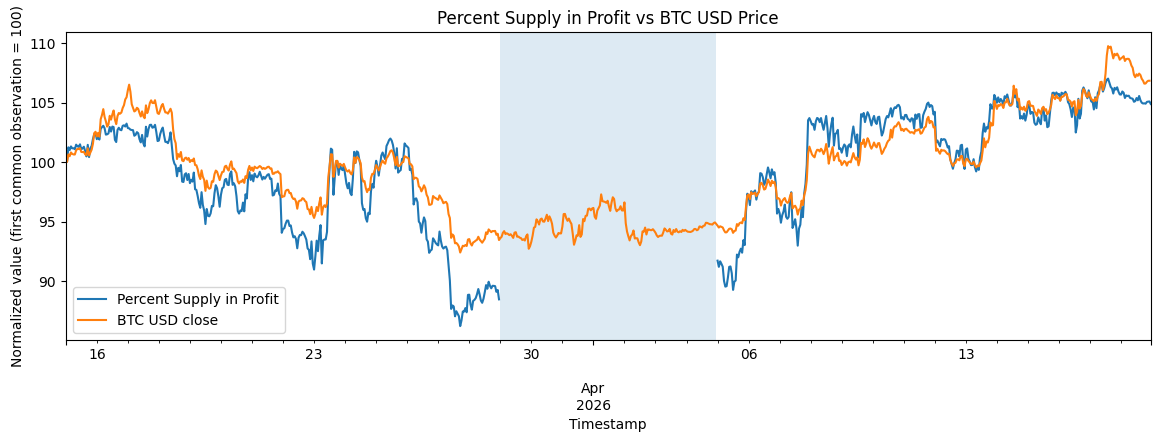

In [103]:
# Compare Percent Supply in Profit with BTC price around the missing period
comparison_start = pct_supply_missing_timestamps.min() - pd.Timedelta(days=14)
comparison_end = pct_supply_missing_timestamps.max() + pd.Timedelta(days=14)

params = {"a": "BTC", "i": "1h", "s": int(comparison_start.timestamp()), "u": int(comparison_end.timestamp()), "api_key": gn_api,}

response = requests.get("https://api.glassnode.com/v1/metrics/market/price_usd_close", params=params)
response.raise_for_status()

btc_price = pd.DataFrame(response.json()).rename(columns={"t": "timestamp", "v": "btc_usd_close"})
btc_price["timestamp"] = pd.to_datetime(btc_price["timestamp"], unit="s", utc=True)
btc_price = btc_price.set_index("timestamp")["btc_usd_close"].sort_index()

comparison = pd.concat([df_glassnode["pct_supply_profit"], btc_price], axis=1).loc[comparison_start:comparison_end]
normalized = comparison.divide(comparison.dropna().iloc[0]).multiply(100)

ax = normalized.plot(figsize=(14, 4), title="Percent Supply in Profit vs BTC USD Price")
ax.axvspan(pct_supply_missing_timestamps.min(), pct_supply_missing_timestamps.max(), alpha=0.15)
ax.set(xlabel="Timestamp", ylabel="Normalized value (first common observation = 100)")
ax.legend(["Percent Supply in Profit", "BTC USD close"])
plt.show()

**Observation and treatment**

- No sufficiently stable relationship is observed between `pct_supply_profit` and BTC price to support proxy reconstruction.
- The seven-day gap originates from missing hourly `supply/profit_sum` data, preventing direct reconstruction from the hourly endpoint components.
- The same `supply/profit_relative` metric remains available at 24-hour resolution over the affected period.
- The daily series is therefore used to reconstruct the missing interval before alignment to the hourly index. This preserves the broad movement of the metric while sacrificing intraday variation during the reconstructed period.

In [104]:
# Patch missing Percent Supply in Profit bars using the 24-hour endpoint
col = "pct_supply_profit"
missing = df_glassnode[col].isna()

params = {"a": "BTC", "i": "24h", "s": int(df_glassnode.index.min().timestamp()), "u": int(df_glassnode.index.max().timestamp()), "api_key": gn_api,}
response = requests.get("https://api.glassnode.com/v1/metrics/supply/profit_relative", params=params)
response.raise_for_status()

pct_supply_daily = pd.DataFrame(response.json()).rename(columns={"t": "timestamp", "v": col})
pct_supply_daily["timestamp"] = pd.to_datetime(pct_supply_daily["timestamp"], unit="s", utc=True)
pct_supply_daily = pct_supply_daily.set_index("timestamp")[col].sort_index()
pct_supply_daily = pct_supply_daily[~pct_supply_daily.index.duplicated(keep="first")]

pct_supply_daily_1h = pct_supply_daily.reindex(df_glassnode.index).ffill()

pct_supply_clean = df_glassnode[[col]].copy()
pct_supply_clean[col] = pct_supply_clean[col].fillna(pct_supply_daily_1h)
pct_supply_clean["daily_patch_flag"] = missing.astype(int)
pct_supply_clean.to_parquet("pct_supply_profit_1h_clean.parquet", compression="zstd")

print(f"Native hourly missing bars: {missing.sum()}")
print(f"Hourly bars patched: {pct_supply_clean['daily_patch_flag'].sum()}")
print(f"Missing after reconstruction: {pct_supply_clean[col].isna().sum()}")

Native hourly missing bars: 168
Hourly bars patched: 168
Missing after reconstruction: 0


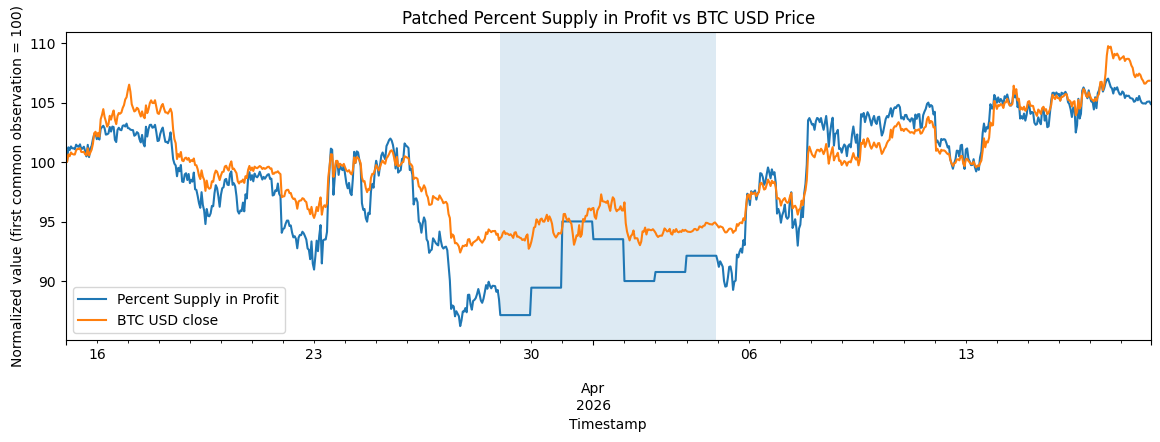

In [105]:
# Plot patched Percent Supply in Profit against BTC price
comparison_start = pct_supply_missing_timestamps.min() - pd.Timedelta(days=14)
comparison_end = pct_supply_missing_timestamps.max() + pd.Timedelta(days=14)

params = {"a": "BTC", "i": "1h", "s": int(comparison_start.timestamp()), "u": int(comparison_end.timestamp()), "api_key": gn_api,}
response = requests.get("https://api.glassnode.com/v1/metrics/market/price_usd_close", params=params)
response.raise_for_status()

btc_price = pd.DataFrame(response.json()).rename(columns={"t": "timestamp", "v": "btc_usd_close"})
btc_price["timestamp"] = pd.to_datetime(btc_price["timestamp"], unit="s", utc=True)
btc_price = btc_price.set_index("timestamp")["btc_usd_close"].sort_index()

comparison = pd.concat([pct_supply_clean["pct_supply_profit"], btc_price], axis=1).loc[comparison_start:comparison_end]
normalized = comparison.divide(comparison.dropna().iloc[0]).multiply(100)

ax = normalized.plot(figsize=(14, 4), title="Patched Percent Supply in Profit vs BTC USD Price")
ax.axvspan(pct_supply_missing_timestamps.min(), pct_supply_missing_timestamps.max(), alpha=0.15)
ax.set(xlabel="Timestamp", ylabel="Normalized value (first common observation = 100)")
ax.legend(["Percent Supply in Profit", "BTC USD close"])
plt.show()

**iv) Merging all Glassnode Endpoints in a Point-In-Time Aligned Data File**


In [106]:
# Assemble final PIT-aligned Glassnode dataset
glassnode_raw = pd.read_parquet("raw_glassnode.parquet").sort_index()
pct_supply_clean = pd.read_parquet("pct_supply_profit_1h_clean.parquet").sort_index()
inv_loss_pit = pd.read_parquet("inv_loss_daily_1h_pit_aligned.parquet").sort_index()

glassnode_raw.index = pd.to_datetime(glassnode_raw.index, utc=True)
pct_supply_clean.index = pd.to_datetime(pct_supply_clean.index, utc=True)
inv_loss_pit.index = pd.to_datetime(inv_loss_pit.index, utc=True)

glassnode_1h_pit_aligned = glassnode_raw.drop(columns=["pct_supply_profit", "inv_loss_seller"])
glassnode_1h_pit_aligned = glassnode_1h_pit_aligned.join(pct_supply_clean[["pct_supply_profit"]]).shift(2)
glassnode_1h_pit_aligned = glassnode_1h_pit_aligned.join(inv_loss_pit[["inv_loss_seller"]])

glassnode_1h_pit_aligned.to_parquet("glassnode_1h_pit_aligned.parquet", compression="zstd")

print(f"Final shape: {glassnode_1h_pit_aligned.shape}")
print(f"Date range: {glassnode_1h_pit_aligned.index.min()} to {glassnode_1h_pit_aligned.index.max()}")

Final shape: (65712, 19)
Date range: 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00


### **b) Macro-Financial Data**

Yahoo Finance is used to extract a compact set of daily macro-financial indicators capturing US dollar strength, equity-market risk appetite, implied volatility and long-term interest-rate conditions.

| Internal name | Yahoo Finance series      | Market interpretation                       |
| ------------- | ------------------------- | ------------------------------------------- |
| `dxy`         | US Dollar Index           | Broad USD strength                          |
| `spx`         | S&P 500 Index             | Equity-market risk appetite                 |
| `vix`         | CBOE Volatility Index     | Equity-market stress and implied volatility |
| `us10y`       | US 10-Year Treasury Yield | Long-term interest-rate conditions          |

The series are extracted from 1 January 2019 where available to provide sufficient history for rolling-feature warm-up.

**i) Data Extraction**

In [13]:
# Extract daily macro-financial data
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"
os.chdir(raw_data_dir)

cross_asset_tickers = {"DX-Y.NYB": "dxy", "^GSPC": "spx", "^VIX": "vix", "^TNX": "us10y"}

df_cross_asset = yf.download(list(cross_asset_tickers), start="2019-01-01", end="2026-07-01", interval="1d", auto_adjust=False, progress=False
  )["Close"].rename(columns=cross_asset_tickers).sort_index()

df_cross_asset.index = pd.to_datetime(df_cross_asset.index, utc=True)
df_cross_asset.to_parquet("raw_cross_asset.parquet", compression="zstd")

df_cross_asset.head()

Ticker,dxy,spx,us10y,vix
Date,,,,
2019-01-02 00:00:00+00:00,96.820000,2510.030029,2.661,23.219999
2019-01-03 00:00:00+00:00,96.309998,2447.889893,2.554,25.450001
2019-01-04 00:00:00+00:00,96.190002,2531.939941,2.659,21.379999
2019-01-07 00:00:00+00:00,95.709999,2549.689941,2.682,21.400000
2019-01-08 00:00:00+00:00,95.900002,2574.409912,2.716,20.469999


**ii) Data Quality Check**


In [16]:
# Cross-asset data quality checks
print(f"Shape: {df_cross_asset.shape}")
print(f"Date range: {df_cross_asset.index.min()} to {df_cross_asset.index.max()}")
print(f"Duplicate timestamps: {df_cross_asset.index.duplicated().sum()}")

rows = []

for col in ["dxy", "spx", "vix", "us10y"]:
    s = df_cross_asset[col]
    first, last = s.first_valid_index(), s.last_valid_index()
    active = s.loc[first:last]
    rows.append([col, int(s.isna().sum()), first, last, len(active), int(active.isna().sum())    ])

cross_asset_nan_summary = pd.DataFrame(rows, columns=["series", "missing_count", "first_valid_timestamp", "last_valid_timestamp",
                                                      "observations_in_active_range", "internal_nan_count"]).set_index("series")

print(f"Total missing values: {cross_asset_nan_summary['missing_count'].sum()}")
print(f"Series with internal NaN: {(cross_asset_nan_summary['internal_nan_count'] > 0).sum()}")

cross_asset_nan_summary

Shape: (1886, 4)
Date range: 2019-01-02 00:00:00+00:00 to 2026-06-30 00:00:00+00:00
Duplicate timestamps: 0
Total missing values: 9
Series with internal NaN: 4


,missing_count,first_valid_timestamp,last_valid_timestamp,observations_in_active_range,internal_nan_count
series,,,,,
dxy,1,2019-01-02 00:00:00+00:00,2026-06-30 00:00:00+00:00,1886,1
spx,3,2019-01-02 00:00:00+00:00,2026-06-30 00:00:00+00:00,1886,3
vix,2,2019-01-02 00:00:00+00:00,2026-06-30 00:00:00+00:00,1886,2
us10y,3,2019-01-02 00:00:00+00:00,2026-06-30 00:00:00+00:00,1886,3


#### **iii) Source-Level Data Integrity Checks**

Examining the NaN profile, determine if simple ffill is appropriate given small gaps in the data


In [17]:
# List internal missing timestamps
cross_asset_internal_nan_dates = (df_cross_asset.isna().stack().loc[lambda x: x].rename_axis(["missing_timestamp", "series"])
    .reset_index().drop(columns=0).sort_values(["missing_timestamp", "series"]).reset_index(drop=True))

cross_asset_internal_nan_dates

,missing_timestamp,series
0,2025-01-09 00:00:00+00:00,spx
1,2025-01-09 00:00:00+00:00,us10y
2,2025-01-09 00:00:00+00:00,vix
3,2025-05-26 00:00:00+00:00,spx
4,2025-05-26 00:00:00+00:00,us10y
5,2025-05-26 00:00:00+00:00,vix
6,2026-05-25 00:00:00+00:00,dxy
7,2026-05-25 00:00:00+00:00,spx
8,2026-05-25 00:00:00+00:00,us10y


Missing data are all evolved around 2 specific stock market closure dates. Simple forward fill applied to missing data.

In [18]:
# Forward-fill isolated missing observations
df_cross_asset = df_cross_asset.ffill()
print(f"Missing values after forward-fill: {df_cross_asset.isna().sum().sum()}")

Missing values after forward-fill: 0


**iv) Creating Point-In-Time Aligned Data File**

In [19]:
# Create PIT-aligned hourly cross-asset dataset
df_cross_asset_pit = df_cross_asset.set_axis(df_cross_asset.index + pd.Timedelta(days=1))
hourly_index = pd.date_range(df_cross_asset_pit.index.min(), pd.Timestamp("2026-06-30 23:00:00", tz="UTC"), freq="1h")

df_cross_asset_1h_pit = df_cross_asset_pit.reindex(hourly_index).ffill()
df_cross_asset_1h_pit.index.name = "timestamp"
df_cross_asset_1h_pit.to_parquet("cross_asset_1h_pit_aligned.parquet", compression="zstd")

print(f"Shape: {df_cross_asset_1h_pit.shape}")
print(f"Date range: {df_cross_asset_1h_pit.index.min()} to {df_cross_asset_1h_pit.index.max()}")
print(f"Missing values: {df_cross_asset_1h_pit.isna().sum().sum()}")

df_cross_asset_1h_pit.head()

Shape: (65664, 4)
Date range: 2019-01-03 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Missing values: 0


Ticker,dxy,spx,us10y,vix
timestamp,,,,
2019-01-03 00:00:00+00:00,96.82,2510.030029,2.661,23.219999
2019-01-03 01:00:00+00:00,96.82,2510.030029,2.661,23.219999
2019-01-03 02:00:00+00:00,96.82,2510.030029,2.661,23.219999
2019-01-03 03:00:00+00:00,96.82,2510.030029,2.661,23.219999
2019-01-03 04:00:00+00:00,96.82,2510.030029,2.661,23.219999


### **c) Centralised-Exchange (CEX) Data**

Centralised exchanges - Binance, Coinbase and OKX, provide the core traded-market information used in this study. The extracted data cover prices, trading activity, perpetual premium and funding conditions that may contain information relevant to BTCUSDT perpetual-futures direction.

| Source                        | Data extracted                                                                    | Primary role                                                                       |
| ----------------------------- | --------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------- |
| Binance USD-margined futures  | BTCUSDT and ETHUSDT hourly OHLCV, quote volume, trade counts and taker-buy volume | Prediction target, price, momentum, volume, order flow and cross-crypto conditions |
| Binance derivatives endpoints | BTCUSDT perpetual premium-index OHLC and funding rate                             | Perpetual basis, funding and positioning conditions                                |
| Coinbase Exchange             | BTC-USD hourly spot close                                                         | Cross-exchange spot-price reference                                                |
| OKX                           | BTC-USDT perpetual hourly close                                                   | Cross-exchange perpetual-price reference                                           |

The series are extracted from 1 January 2019 where available and retained at their native frequency before timestamp, coverage and missing-value checks are performed.

**i) Binance K-line data**

**Data Extraction**

In [20]:
# Extract Binance USD-M perpetual-futures klines
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

binance_kline_endpoints = [
    {"name": "btc", "symbol": "BTCUSDT", "interval": "1h", "start_month": "2019-09"},
    {"name": "eth", "symbol": "ETHUSDT", "interval": "1h", "start_month": "2019-11"}]

analysis_end = pd.Timestamp("2026-07-01", tz="UTC")

kline_columns = [
    "open_time", "open", "high", "low", "close", "volume",
    "close_time", "quote_volume", "num_trades",
    "taker_buy_volume", "taker_buy_quote_volume", "ignore"]

binance_kline_data = {}

for item in binance_kline_endpoints:
    frames = []

    for month in pd.period_range(item["start_month"], "2026-06", freq="M"):
        url = f"https://data.binance.vision/data/futures/um/monthly/klines/{item['symbol']}/{item['interval']}/{item['symbol']}-{item['interval']}-{month}.zip"
        response = requests.get(url, timeout=30)
        if response.status_code == 404:
            continue

        response.raise_for_status()
        with zipfile.ZipFile(io.BytesIO(response.content)) as archive:
            frames.append(pd.read_csv(archive.open(archive.namelist()[0]), header=None, names=kline_columns))

    if not frames:
        raise ValueError(f"No kline data returned for {item['symbol']}")

    df = pd.concat(frames, ignore_index=True)

    open_time = pd.to_numeric(df["open_time"], errors="coerce")
    open_time = open_time.where(open_time < 1e14, open_time / 1000)
    df["timestamp"] = pd.to_datetime(open_time, unit="ms", utc=True, errors="coerce")

    df = df.dropna(subset=["timestamp"])
    df = df.loc[df["timestamp"] < analysis_end]
    df = df.drop(columns=["open_time", "close_time", "ignore"]).drop_duplicates()
    df = df.set_index("timestamp").sort_index()
    df = df.loc[~df.index.duplicated(keep=False)].apply(pd.to_numeric, errors="coerce")
    df.columns = [f"{item['name']}_{col}" for col in df.columns]

    binance_kline_data[item["name"]] = df
    print(f"{item['symbol']}: {df.shape}, {df.index.min()} to {df.index.max()}")

df_binance_klines = pd.concat(binance_kline_data.values(), axis=1).sort_index()

df_binance_klines.to_parquet("raw_binance_klines.parquet", compression="zstd")
df_binance_klines.head()

BTCUSDT: (56952, 9), 2020-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
ETHUSDT: (56952, 9), 2020-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00


,btc_open,btc_high,btc_low,btc_close,btc_volume,btc_quote_volume,btc_num_trades,btc_taker_buy_volume,btc_taker_buy_quote_volume,eth_open,eth_high,eth_low,eth_close,eth_volume,eth_quote_volume,eth_num_trades,eth_taker_buy_volume,eth_taker_buy_quote_volume
timestamp,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00+00:00,7189.43,7190.52,7170.15,7171.55,2449.049,1.757642e+07,3688,996.198,7.149371e+06,129.12,129.12,128.62,128.82,14947.691,1.925644e+06,1249,7707.625,9.928838e+05
2020-01-01 01:00:00+00:00,7171.43,7225.00,7171.10,7210.24,3865.038,2.783805e+07,6635,2340.878,1.686029e+07,128.81,130.61,128.76,130.57,34755.256,4.514484e+06,3116,19928.267,2.588555e+06
2020-01-01 02:00:00+00:00,7210.38,7239.30,7206.46,7237.99,3228.365,2.332481e+07,5120,1774.145,1.281847e+07,130.58,130.97,130.30,130.80,21864.946,2.857378e+06,1807,10299.172,1.345962e+06
2020-01-01 03:00:00+00:00,7237.41,7239.74,7215.00,7221.65,2513.307,1.816182e+07,4143,1245.065,8.996219e+06,130.80,130.82,129.88,130.09,16823.171,2.190835e+06,1448,7580.536,9.869013e+05
2020-01-01 04:00:00+00:00,7221.80,7225.41,7211.22,7213.86,1176.666,8.493631e+06,1966,586.864,4.236084e+06,130.10,130.63,130.09,130.15,11357.239,1.480319e+06,1065,5204.925,6.783015e+05


**Data Quality Check**


In [22]:
# Binance kline data quality checks
print(f"Shape: {df_binance_klines.shape}")
print(f"Date range: {df_binance_klines.index.min()} to {df_binance_klines.index.max()}")
print(f"Duplicate timestamps: {df_binance_klines.index.duplicated().sum()}")

rows = []

for col in df_binance_klines.columns:
    s = df_binance_klines[col]
    first, last = s.first_valid_index(), s.last_valid_index()
    active = s.loc[first:last]
    rows.append([col, int(s.isna().sum()), first, last, len(active), int(active.isna().sum())])

binance_kline_nan_summary = pd.DataFrame(rows, columns=["series", "missing_count", "first_valid_timestamp",
                                                        "last_valid_timestamp",    "observations_in_active_range", "internal_nan_count"]).set_index("series")

print(f"Total missing values including pre-coverage: {binance_kline_nan_summary['missing_count'].sum()}")
print(f"Fields with internal NaN: {(binance_kline_nan_summary['internal_nan_count'] > 0).sum()}")

binance_kline_nan_summary

Shape: (56952, 18)
Date range: 2020-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Total missing values including pre-coverage: 0
Fields with internal NaN: 0


,missing_count,first_valid_timestamp,last_valid_timestamp,observations_in_active_range,internal_nan_count
series,,,,,
btc_open,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0
btc_high,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0
btc_low,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0
btc_close,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0
btc_volume,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0
btc_quote_volume,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0
btc_num_trades,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0
btc_taker_buy_volume,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0
btc_taker_buy_quote_volume,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0


No data cleaning required.

**ii) Binance perpetual premium-index data**

Binance premium-index data could not be retrieved reliably from the public archive, while API access from Google Colab was blocked by an HTTP 451 geographic/IP restriction. Extraction was therefore run once through a standalone reproducible Python module on an unrestricted network, with the resulting raw CSV frozen for the analysis and validated in the notebook before use.

In [23]:
# Load Binance BTC perpetual premium-index data
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"
os.chdir(raw_data_dir)

premium_cols = ["btc_perp_premium_open", "btc_perp_premium_high", "btc_perp_premium_low", "btc_perp_premium_close"]

df_binance_premium = pd.read_csv("raw_binance_perp_premium.csv", parse_dates=["timestamp"])
df_binance_premium["timestamp"] = pd.to_datetime(df_binance_premium["timestamp"], utc=True)
df_binance_premium = df_binance_premium.set_index("timestamp").sort_index()

df_binance_premium = df_binance_premium.loc[
    (df_binance_premium.index >= pd.Timestamp("2020-01-01", tz="UTC")) &
    (df_binance_premium.index < analysis_end), premium_cols].apply(pd.to_numeric, errors="coerce")

df_binance_premium.head()

,btc_perp_premium_open,btc_perp_premium_high,btc_perp_premium_low,btc_perp_premium_close
timestamp,,,,
2020-01-01 00:00:00+00:00,-0.000777,-0.000443,-0.001206,-0.000809
2020-01-01 01:00:00+00:00,-0.000818,-0.000100,-0.001015,-0.000801
2020-01-01 02:00:00+00:00,-0.000445,-0.000445,-0.001063,-0.000554
2020-01-01 03:00:00+00:00,-0.000412,-0.000295,-0.001005,-0.000627
2020-01-01 04:00:00+00:00,-0.000523,-0.000296,-0.000887,-0.000517


**Data Quality Check**

In [24]:
# Binance premium-index data quality checks
print(f"Shape: {df_binance_premium.shape}")
print(f"Date range: {df_binance_premium.index.min()} to {df_binance_premium.index.max()}")
print(f"Duplicate timestamps: {df_binance_premium.index.duplicated().sum()}")

rows = []

for col in df_binance_premium.columns:
    s = df_binance_premium[col]
    first, last = s.first_valid_index(), s.last_valid_index()
    active = s.loc[first:last]
    rows.append([col, int(s.isna().sum()), first, last, len(active), int(active.isna().sum())])

binance_premium_nan_summary = pd.DataFrame(rows, columns=["series", "missing_count", "first_valid_timestamp", "last_valid_timestamp",
                                                          "observations_in_active_range", "internal_nan_count"]).set_index("series")

print(f"Total missing values: {binance_premium_nan_summary['missing_count'].sum()}")
print(f"Fields with internal NaN: {(binance_premium_nan_summary['internal_nan_count'] > 0).sum()}")

binance_premium_nan_summary

Shape: (56951, 4)
Date range: 2020-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Total missing values: 0
Fields with internal NaN: 0


,missing_count,first_valid_timestamp,last_valid_timestamp,observations_in_active_range,internal_nan_count
series,,,,,
btc_perp_premium_open,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56951,0
btc_perp_premium_high,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56951,0
btc_perp_premium_low,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56951,0
btc_perp_premium_close,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56951,0


In [25]:
# Check missing hourly timestamps
premium_expected_index = pd.date_range(df_binance_premium.index.min(), df_binance_premium.index.max(), freq="1h")
premium_missing_timestamps = premium_expected_index.difference(df_binance_premium.index)

print(f"Missing hourly timestamps: {len(premium_missing_timestamps)}")
premium_missing_timestamps

Missing hourly timestamps: 1


DatetimeIndex(['2020-12-01 23:00:00+00:00'], dtype='datetime64[ns, UTC]', freq='h')

**Source-Level Data Integrity Checks**

In [26]:
# Forward-fill the single missing premium-index hour
premium_full_index = pd.date_range(df_binance_premium.index.min(), df_binance_premium.index.max(), freq="1h")
df_binance_premium = df_binance_premium.reindex(premium_full_index)
df_binance_premium.index.name = "timestamp"

missing_before = df_binance_premium.isna().all(axis=1).sum()
df_binance_premium = df_binance_premium.ffill(limit=1)
missing_after = df_binance_premium.isna().all(axis=1).sum()

print(f"Missing rows before forward-fill: {missing_before}")
print(f"Missing rows after forward-fill: {missing_after}")

Missing rows before forward-fill: 1
Missing rows after forward-fill: 0


In [27]:
# Save Binance premium-index data
df_binance_premium.to_parquet("raw_binance_premium.parquet", compression="zstd", index=True)

**iii) Binance Funding Rate Endpoint**

**Data Extraction**

In [28]:
# Extract Binance BTC funding rates
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)
symbol = "BTCUSDT"
frames = []

for month in pd.period_range("2019-09", "2026-06", freq="M"):
    url = f"https://data.binance.vision/data/futures/um/monthly/fundingRate/{symbol}/{symbol}-fundingRate-{month}.zip"
    response = requests.get(url, timeout=30)

    if response.status_code == 404:
        continue
    response.raise_for_status()

    with zipfile.ZipFile(io.BytesIO(response.content)) as archive:
        frames.append(pd.read_csv(archive.open(archive.namelist()[0])))

if not frames:
    raise ValueError("No Binance BTC funding-rate data returned")

df_binance_funding = pd.concat(frames, ignore_index=True)
df_binance_funding.columns = df_binance_funding.columns.astype(str).str.strip()

df_binance_funding["timestamp"] = pd.to_datetime(pd.to_numeric(df_binance_funding["calc_time"], errors="coerce"),
    unit="ms", utc=True, errors="coerce")

df_binance_funding = df_binance_funding.dropna(subset=["timestamp"])
df_binance_funding = df_binance_funding.loc[df_binance_funding["timestamp"] < analysis_end]
df_binance_funding = df_binance_funding.set_index("timestamp").sort_index()
df_binance_funding = df_binance_funding[["last_funding_rate"]].rename(columns={"last_funding_rate": "btc_funding"})
df_binance_funding["btc_funding"] = pd.to_numeric(df_binance_funding["btc_funding"], errors="coerce")

df_binance_funding.to_parquet("raw_binance_funding.parquet", compression="zstd")

print(f"BTC funding: {df_binance_funding.shape}, {df_binance_funding.index.min()} to {df_binance_funding.index.max()}")
df_binance_funding.head()

BTC funding: (7119, 1), 2020-01-01 00:00:00+00:00 to 2026-06-30 16:00:00.005000+00:00


,btc_funding
timestamp,
2020-01-01 00:00:00+00:00,-0.000124
2020-01-01 08:00:00+00:00,-0.000124
2020-01-01 16:00:00+00:00,-0.000097
2020-01-02 00:00:00.002000+00:00,0.000037
2020-01-02 08:00:00+00:00,0.000100


**Data Quality Check**

In [29]:
# Binance funding-rate data quality checks
print(f"Shape: {df_binance_funding.shape}")
print(f"Date range: {df_binance_funding.index.min()} to {df_binance_funding.index.max()}")
print(f"Duplicate timestamps: {df_binance_funding.index.duplicated().sum()}")

s = df_binance_funding["btc_funding"]
first, last = s.first_valid_index(), s.last_valid_index()
active = s.loc[first:last]

binance_funding_nan_summary = pd.DataFrame([{"series": "btc_funding", "missing_count": int(s.isna().sum()), "first_valid_timestamp": first,
                                             "last_valid_timestamp": last, "observations_in_active_range": len(active),"internal_nan_count": int(active.isna().sum())
                                             }]).set_index("series")

print(f"Total missing values: {binance_funding_nan_summary['missing_count'].sum()}")
print(f"Fields with internal NaN: {(binance_funding_nan_summary['internal_nan_count'] > 0).sum()}")

binance_funding_nan_summary

Shape: (7119, 1)
Date range: 2020-01-01 00:00:00+00:00 to 2026-06-30 16:00:00.005000+00:00
Duplicate timestamps: 0
Total missing values: 0
Fields with internal NaN: 0


,missing_count,first_valid_timestamp,last_valid_timestamp,observations_in_active_range,internal_nan_count
series,,,,,
btc_funding,0,2020-01-01 00:00:00+00:00,2026-06-30 16:00:00.005000+00:00,7119,0


**Source-Level Data Integrity Checks**

There are some odd index display which requires data cleaning



In [30]:
# Find funding timestamps that are not exactly aligned to the hour
funding_off_hour = df_binance_funding[(df_binance_funding.index.minute != 0) | (df_binance_funding.index.second != 0) | (df_binance_funding.index.microsecond != 0)]
funding_off_hour

,btc_funding
timestamp,
2020-01-02 00:00:00.002000+00:00,0.000037
2020-01-03 16:00:00.001000+00:00,0.000100
2020-01-07 08:00:00.001000+00:00,0.000100
2020-01-08 16:00:00.001000+00:00,0.000100
2020-01-13 00:00:00.001000+00:00,0.000100
...,...
2026-06-28 08:00:00.013000+00:00,0.000014
2026-06-29 00:00:00.006000+00:00,0.000031
2026-06-29 08:00:00.013000+00:00,0.000074


In [31]:
# Round Binance funding timestamps to the nearest hour
df_binance_funding.index = (df_binance_funding.index.round("h"))

In [32]:
# Funding settlements should normally occur at 00:00, 08:00 and 16:00 UTC, check for mis-aligned timestamps
unexpected_funding_hours = df_binance_funding[~df_binance_funding.index.hour.isin([0, 8, 16])]
print("Unexpected funding-hour rows:", len(unexpected_funding_hours))

Unexpected funding-hour rows: 0


**Creating Point-In-Time Aligned Data File**

BTC funding rate settles every 8 hours, as such we need to transform this series into a point-in-time aligned data towards the one hour resolution level.



In [33]:
# Expand T+0 Binance funding rates to hourly frequency
hourly_index = pd.date_range(df_binance_funding.index.min(), analysis_end - pd.Timedelta(hours=1), freq="1h")

df_binance_funding_1h_pit = df_binance_funding.reindex(hourly_index).ffill()
df_binance_funding_1h_pit.index.name = "timestamp"
df_binance_funding_1h_pit.to_parquet("binance_funding_1h_pit_aligned.parquet", compression="zstd")

print(f"Shape: {df_binance_funding_1h_pit.shape}")
print(f"Date range: {df_binance_funding_1h_pit.index.min()} to {df_binance_funding_1h_pit.index.max()}")
print(f"Missing values: {df_binance_funding_1h_pit.isna().sum().sum()}")

Shape: (56952, 1)
Date range: 2020-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Missing values: 0


In [34]:
# Save binance premium
df_binance_premium.to_parquet("binance_premium_1h_pit_aligned.parquet", compression="zstd")

**Merging all Binance Endpoints in a Point-In-Time Aligned Data File**

In [35]:
# Merge PIT-aligned Binance sources
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

df_binance_klines_merge = pd.read_parquet("raw_binance_klines.parquet").sort_index()
df_binance_premium_merge = pd.read_parquet("binance_premium_1h_pit_aligned.parquet").sort_index()
df_binance_funding_merge = pd.read_parquet("binance_funding_1h_pit_aligned.parquet").sort_index()

df_binance_1h_pit = pd.concat([df_binance_klines_merge, df_binance_premium_merge, df_binance_funding_merge], axis=1).sort_index()
df_binance_1h_pit.index.name = "timestamp"
df_binance_1h_pit.to_parquet("binance_1h_pit_aligned.parquet", compression="zstd")

print(f"Shape: {df_binance_1h_pit.shape}")
print(f"Date range: {df_binance_1h_pit.index.min()} to {df_binance_1h_pit.index.max()}")
print(f"Missing values: {df_binance_1h_pit.isna().sum().sum()}")

df_binance_1h_pit.head()

Shape: (56952, 23)
Date range: 2020-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Missing values: 0


,btc_open,btc_high,btc_low,btc_close,btc_volume,btc_quote_volume,btc_num_trades,btc_taker_buy_volume,btc_taker_buy_quote_volume,eth_open,...,eth_volume,eth_quote_volume,eth_num_trades,eth_taker_buy_volume,eth_taker_buy_quote_volume,btc_perp_premium_open,btc_perp_premium_high,btc_perp_premium_low,btc_perp_premium_close,btc_funding
timestamp,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00+00:00,7189.43,7190.52,7170.15,7171.55,2449.049,1.757642e+07,3688,996.198,7.149371e+06,129.12,...,14947.691,1.925644e+06,1249,7707.625,9.928838e+05,-0.000777,-0.000443,-0.001206,-0.000809,-0.000124
2020-01-01 01:00:00+00:00,7171.43,7225.00,7171.10,7210.24,3865.038,2.783805e+07,6635,2340.878,1.686029e+07,128.81,...,34755.256,4.514484e+06,3116,19928.267,2.588555e+06,-0.000818,-0.000100,-0.001015,-0.000801,-0.000124
2020-01-01 02:00:00+00:00,7210.38,7239.30,7206.46,7237.99,3228.365,2.332481e+07,5120,1774.145,1.281847e+07,130.58,...,21864.946,2.857378e+06,1807,10299.172,1.345962e+06,-0.000445,-0.000445,-0.001063,-0.000554,-0.000124
2020-01-01 03:00:00+00:00,7237.41,7239.74,7215.00,7221.65,2513.307,1.816182e+07,4143,1245.065,8.996219e+06,130.80,...,16823.171,2.190835e+06,1448,7580.536,9.869013e+05,-0.000412,-0.000295,-0.001005,-0.000627,-0.000124
2020-01-01 04:00:00+00:00,7221.80,7225.41,7211.22,7213.86,1176.666,8.493631e+06,1966,586.864,4.236084e+06,130.10,...,11357.239,1.480319e+06,1065,5204.925,6.783015e+05,-0.000523,-0.000296,-0.000887,-0.000517,-0.000124


**iv) Coinbase BTC USD spot price**

**Data extraction**

In [36]:
# Extract Coinbase BTC-USD hourly candles
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

url = "https://api.exchange.coinbase.com/products/BTC-USD/candles"
start = pd.Timestamp("2019-01-01", tz="UTC")
end = pd.Timestamp("2026-07-01", tz="UTC")
rows = []

while start < end:
    window_end = min(start + pd.Timedelta(hours=300), end)
    params = {"granularity": 3600, "start": start.isoformat(), "end": window_end.isoformat()}

    response = requests.get(url, params=params, headers={"User-Agent": "research_project"}, timeout=30)
    response.raise_for_status()

    rows.extend(response.json())
    start = window_end
    time.sleep(0.1)

df_coinbase = pd.DataFrame(rows, columns=["timestamp", "low", "high", "open", "close", "volume"])
df_coinbase["timestamp"] = pd.to_datetime(pd.to_numeric(df_coinbase["timestamp"], errors="coerce"), unit="s", utc=True, errors="coerce")

df_coinbase = df_coinbase.dropna(subset=["timestamp"])
df_coinbase = df_coinbase.loc[df_coinbase["timestamp"] < end]
df_coinbase = df_coinbase.set_index("timestamp").sort_index()
df_coinbase = df_coinbase[["close"]].rename(columns={"close": "coinbase_btc_close"})
df_coinbase["coinbase_btc_close"] = pd.to_numeric(df_coinbase["coinbase_btc_close"], errors="coerce")
df_coinbase.index.name = "timestamp"

df_coinbase.to_parquet("raw_coinbase_btc_1h.parquet", compression="zstd")

print(f"Shape: {df_coinbase.shape}")
print(f"Date range: {df_coinbase.index.min()} to {df_coinbase.index.max()}")

df_coinbase.head()

Shape: (65912, 1)
Date range: 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00


,coinbase_btc_close
timestamp,
2019-01-01 00:00:00+00:00,3691.89
2019-01-01 01:00:00+00:00,3676.66
2019-01-01 02:00:00+00:00,3674.00
2019-01-01 03:00:00+00:00,3682.00
2019-01-01 04:00:00+00:00,3681.80


**Data Quality Check**


In [37]:
# Coinbase data quality checks
print(f"Shape: {df_coinbase.shape}")
print(f"Date range: {df_coinbase.index.min()} to {df_coinbase.index.max()}")
print(f"Duplicate timestamps: {df_coinbase.index.duplicated().sum()}")

s = df_coinbase["coinbase_btc_close"]
first, last = s.first_valid_index(), s.last_valid_index()
active = s.loc[first:last]

coinbase_nan_summary = pd.DataFrame([{"series": "coinbase_btc_close", "missing_count": int(s.isna().sum()), "first_valid_timestamp": first,
                                      "last_valid_timestamp": last, "observations_in_active_range": len(active),"internal_nan_count": int(active.isna().sum())}]).set_index("series")

print(f"Total missing values: {coinbase_nan_summary['missing_count'].sum()}")
print(f"Fields with internal NaN: {(coinbase_nan_summary['internal_nan_count'] > 0).sum()}")

coinbase_nan_summary

Shape: (65912, 1)
Date range: 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 219
Total missing values: 0
Fields with internal NaN: 0


,missing_count,first_valid_timestamp,last_valid_timestamp,observations_in_active_range,internal_nan_count
series,,,,,
coinbase_btc_close,0,2019-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,65912,0


In [38]:
# Check missing Coinbase hourly timestamps
expected_index = pd.date_range(df_coinbase.index.min(), df_coinbase.index.max(), freq="1h")
missing_timestamps = expected_index.difference(df_coinbase.index)

print(f"Missing hourly timestamps: {len(missing_timestamps)}")
display(missing_timestamps.to_frame(index=False, name="missing_timestamp"))

Missing hourly timestamps: 19


,missing_timestamp
0,2019-04-11 13:00:00+00:00
1,2019-06-20 15:00:00+00:00
2,2019-10-31 20:00:00+00:00
3,2020-01-30 17:00:00+00:00
4,2020-09-04 23:00:00+00:00
5,2020-10-20 20:00:00+00:00
6,2023-03-04 18:00:00+00:00
7,2023-03-04 19:00:00+00:00
8,2023-03-04 20:00:00+00:00
9,2025-10-25 16:00:00+00:00


**Source-Level Data Integrity Checks**

The Coinbase extraction contains duplicated boundary timestamps generated across API request windows and a small number of short internal gaps. Duplicate timestamps are removed, the series is aligned to the complete hourly spine, and internal gaps of up to five consecutive hours are forward-filled.

In [54]:
# Clean and save Coinbase BTC-USD hourly data
df_coinbase_clean = df_coinbase.loc[~df_coinbase.index.duplicated(keep="first")]
hourly_index = pd.date_range(df_coinbase.index.min(), df_coinbase.index.max(), freq="1h")

df_coinbase_clean = df_coinbase_clean.reindex(hourly_index)
df_coinbase_clean["coinbase_btc_close"] = df_coinbase_clean["coinbase_btc_close"].ffill(limit=5)
df_coinbase_clean.index.name = "timestamp"

df_coinbase_clean.to_parquet("coinbase_1h_pit_aligned.parquet", compression="zstd")

print(f"Shape: {df_coinbase_clean.shape}")
print(f"Date range: {df_coinbase_clean.index.min()} to {df_coinbase_clean.index.max()}")
print(f"Missing values after cleaning: {df_coinbase_clean['coinbase_btc_close'].isna().sum()}")

Shape: (65712, 1)
Date range: 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Missing values after cleaning: 0


**v) OKX BTC-USDT Perpetual Hourly Data**

**Data Extraction**

In [55]:
# Extract OKX BTC-USDT perpetual hourly candles
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

url = "https://www.okx.com/api/v5/market/history-candles"
start = pd.Timestamp("2019-01-01", tz="UTC")
end = pd.Timestamp("2026-07-01", tz="UTC")
rows, after = [], None

while True:
    params = {"instId": "BTC-USDT-SWAP", "bar": "1H", "limit": 300}
    if after is not None:
        params["after"] = after

    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()
    body = response.json()
    if body.get("code") != "0":
        raise ValueError(f"OKX error {body.get('code')}: {body.get('msg')}")

    data = body.get("data", [])
    if not data:
        break

    rows.extend(data)
    oldest = min(int(row[0]) for row in data)

    if pd.to_datetime(oldest, unit="ms", utc=True) <= start:
        break

    after = oldest
    time.sleep(0.1)

cols = ["timestamp", "open", "high", "low", "close", "volume", "volume_ccy", "volume_quote", "confirm"]
df_okx = pd.DataFrame(rows, columns=cols)

df_okx["timestamp"] = pd.to_datetime(pd.to_numeric(df_okx["timestamp"], errors="coerce"), unit="ms", utc=True, errors="coerce")
df_okx = df_okx.dropna(subset=["timestamp"])
df_okx = df_okx.loc[df_okx["confirm"].astype(str) == "1"]
df_okx = df_okx.loc[(df_okx["timestamp"] >= start) & (df_okx["timestamp"] < end)]
df_okx = df_okx.set_index("timestamp").sort_index()
df_okx = df_okx[["close"]].rename(columns={"close": "okx_btc_close"})
df_okx["okx_btc_close"] = pd.to_numeric(df_okx["okx_btc_close"], errors="coerce")
df_okx.index.name = "timestamp"

df_okx.to_parquet("raw_okx_btc_1h.parquet", compression="zstd")

print(f"Shape: {df_okx.shape}")
print(f"Date range: {df_okx.index.min()} to {df_okx.index.max()}")

df_okx.head()

Shape: (57330, 1)
Date range: 2019-12-16 06:00:00+00:00 to 2026-06-30 23:00:00+00:00


,okx_btc_close
timestamp,
2019-12-16 06:00:00+00:00,7079.0
2019-12-16 07:00:00+00:00,7052.7
2019-12-16 08:00:00+00:00,7064.8
2019-12-16 09:00:00+00:00,7059.8
2019-12-16 10:00:00+00:00,7063.7


**Data Quality Check**

In [56]:
# OKX data quality checks
print(f"Shape: {df_okx.shape}")
print(f"Date range: {df_okx.index.min()} to {df_okx.index.max()}")
print(f"Duplicate timestamps: {df_okx.index.duplicated().sum()}")

s = df_okx["okx_btc_close"]
first, last = s.first_valid_index(), s.last_valid_index()
active = s.loc[first:last]

okx_nan_summary = pd.DataFrame([{"series": "okx_btc_close", "missing_count": int(s.isna().sum()), "first_valid_timestamp": first,
                                 "last_valid_timestamp": last, "observations_in_active_range": len(active), "internal_nan_count": int(active.isna().sum())}]).set_index("series")

print(f"Total missing values: {okx_nan_summary['missing_count'].sum()}")

okx_nan_summary

Shape: (57330, 1)
Date range: 2019-12-16 06:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Total missing values: 0


,missing_count,first_valid_timestamp,last_valid_timestamp,observations_in_active_range,internal_nan_count
series,,,,,
okx_btc_close,0,2019-12-16 06:00:00+00:00,2026-06-30 23:00:00+00:00,57330,0


In [57]:
# Show missing OKX hourly timestamps
expected_index = pd.date_range(df_okx.index.min(), df_okx.index.max(), freq="1h")
missing_timestamps = expected_index.difference(df_okx.index)

print(f"Missing hourly timestamps: {len(missing_timestamps)}")
display(missing_timestamps.to_frame(index=False, name="missing_timestamp"))

Missing hourly timestamps: 0


,missing_timestamp


no further data cleaning required

**vi) Deribit endpoints**

Deribit provides hourly BTC perpetual and quarterly-futures data used to construct term-structure and activity features. Because multiple contracts coexist and the active set changes through time, the data are retained as a contract-level panel.

**Data Extraction**

In [44]:
# Extract Deribit BTC perpetual and quarterly futures
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

url = "https://www.deribit.com/api/v2/public/get_tradingview_chart_data"
start = pd.Timestamp("2019-01-01", tz="UTC")
end = pd.Timestamp("2026-07-01", tz="UTC")

def last_friday(year, month):
    date = pd.Timestamp(year=year, month=month, day=1) + pd.offsets.MonthEnd(0)
    while date.dayofweek != 4:
        date -= pd.Timedelta(days=1)
    return date

instruments = [("BTC-PERPETUAL", pd.NaT)]

for year in range(2019, 2028):
    for month in [3, 6, 9, 12]:
        expiry = pd.Timestamp(last_friday(year, month).date(), tz="UTC") + pd.Timedelta(hours=8)
        name = f"BTC-{expiry.day}{expiry.strftime('%b').upper()}{expiry.strftime('%y')}"
        instruments.append((name, expiry))

frames, unavailable = [], []

for name, expiry in instruments:
    instrument_end = min(end, expiry) if pd.notna(expiry) else end
    window_start, returned, failed = start, False, False

    while window_start < instrument_end:
        window_end = min(window_start + pd.Timedelta(days=30), instrument_end)
        params = {
            "instrument_name": name,
            "start_timestamp": int(window_start.timestamp() * 1000),
            "end_timestamp": int(window_end.timestamp() * 1000),
            "resolution": "60"}
        response = requests.get(url, params=params, timeout=30)

        if response.status_code == 400:
            failed = True
            break

        response.raise_for_status()
        body = response.json()

        if "error" in body:
            failed = True
            break

        result = body.get("result", {})
        ticks = result.get("ticks", [])

        if result.get("status") == "ok" and ticks:
            n = len(ticks)
            df = pd.DataFrame({
                "timestamp": pd.to_datetime(ticks, unit="ms", utc=True),
                "open": result.get("open", [None] * n),
                "high": result.get("high", [None] * n),
                "low": result.get("low", [None] * n),
                "close": result.get("close", [None] * n),
                "volume": result.get("volume", [None] * n),
                "cost": result.get("cost", [None] * n)})
            df["instrument_name"] = name
            df["expiration_timestamp"] = expiry
            frames.append(df)
            returned = True

        window_start = window_end
        time.sleep(0.1)

    if failed or not returned:
        unavailable.append(name)

if not frames:
    raise ValueError("No Deribit BTC futures candle data returned")

df_deribit_futures = pd.concat(frames, ignore_index=True)

cols = ["open", "high", "low", "close", "volume", "cost"]
df_deribit_futures[cols] = df_deribit_futures[cols].apply(pd.to_numeric, errors="coerce")
df_deribit_futures = df_deribit_futures.loc[(df_deribit_futures["timestamp"] >= start) & (df_deribit_futures["timestamp"] < end)]
df_deribit_futures = df_deribit_futures.sort_values(["timestamp", "instrument_name"]).reset_index(drop=True)
df_deribit_futures.to_parquet("raw_deribit_btc_futures.parquet", compression="zstd", index=False)

print(f"Instruments with data: {df_deribit_futures['instrument_name'].nunique()}")
print(f"Unavailable instruments: {len(unavailable)}")
print(f"Shape: {df_deribit_futures.shape}")

df_deribit_futures.head()

Instruments with data: 35
Unavailable instruments: 2
Shape: (298630, 9)


,timestamp,open,high,low,close,volume,cost,instrument_name,expiration_timestamp
0,2019-01-01 00:00:00+00:00,3607.5,3617.0,3598.0,3605.5,8.886658,32090.0,BTC-28JUN19,2019-06-28 08:00:00+00:00
1,2019-01-01 00:00:00+00:00,3630.5,3644.5,3621.0,3633.0,71.291402,258770.0,BTC-29MAR19,2019-03-29 08:00:00+00:00
2,2019-01-01 00:00:00+00:00,3697.0,3706.0,3686.5,3696.5,205.492577,759020.0,BTC-PERPETUAL,NaT
3,2019-01-01 01:00:00+00:00,3606.0,3608.5,3586.5,3589.5,15.256294,54840.0,BTC-28JUN19,2019-06-28 08:00:00+00:00
4,2019-01-01 01:00:00+00:00,3631.0,3631.0,3615.0,3624.0,23.823414,86320.0,BTC-29MAR19,2019-03-29 08:00:00+00:00


**Data Quality Check**

In [45]:
# Deribit data quality checks
print(f"Shape: {df_deribit_futures.shape}")
print(f"Date range: {df_deribit_futures['timestamp'].min()} to {df_deribit_futures['timestamp'].max()}")
print(f"Instruments: {df_deribit_futures['instrument_name'].nunique()}")

post_expiry = (df_deribit_futures["expiration_timestamp"].notna() & (df_deribit_futures["timestamp"] > df_deribit_futures["expiration_timestamp"]))

print(f"Exact duplicate rows: {df_deribit_futures.duplicated().sum()}")
print(f"Invalid timestamps: {df_deribit_futures['timestamp'].isna().sum()}")
print(f"Duplicate instrument-timestamps: {df_deribit_futures.duplicated(['timestamp', 'instrument_name'], keep=False).sum()}")
print(f"Post-expiry rows: {post_expiry.sum()}")

rows = []
for col in ["open", "high", "low", "close", "volume", "cost"]:
    s = df_deribit_futures[col]
    valid_ts = df_deribit_futures.loc[s.notna(), "timestamp"]
    rows.append([col, int(s.isna().sum()), valid_ts.min(), valid_ts.max()])

deribit_nan_summary = pd.DataFrame(rows, columns=["series", "missing_count", "first_valid_timestamp", "last_valid_timestamp"]).set_index("series")
print(f"Total missing values: {deribit_nan_summary['missing_count'].sum()}")

deribit_nan_summary

Shape: (298630, 9)
Date range: 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Instruments: 35
Exact duplicate rows: 415
Invalid timestamps: 0
Duplicate instrument-timestamps: 830
Post-expiry rows: 0
Total missing values: 0


,missing_count,first_valid_timestamp,last_valid_timestamp
series,,,
open,0,2019-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00
high,0,2019-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00
low,0,2019-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00
close,0,2019-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00
volume,0,2019-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00
cost,0,2019-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00


In [46]:
# Check missing hourly timestamps within each Deribit contract
summary, missing = [], []

for name, df in df_deribit_futures.groupby("instrument_name"):
    timestamps = pd.DatetimeIndex(df["timestamp"].dropna().unique()).sort_values()
    first, last = timestamps.min(), timestamps.max()
    expected = pd.date_range(first, last, freq="1h")
    missing_idx = expected.difference(timestamps)

    summary.append([name, first, last, len(timestamps), len(expected), len(missing_idx)])
    missing.extend([[name, ts] for ts in missing_idx])

deribit_missing_summary = pd.DataFrame(summary, columns=["instrument_name", "first_timestamp", "last_timestamp",
                                                         "observed_rows", "expected_rows", "missing_hour_count"]).set_index("instrument_name").sort_index()
deribit_missing_timestamps = pd.DataFrame(missing, columns=["instrument_name", "missing_timestamp"])

print(f"Contracts with missing hours: {(deribit_missing_summary['missing_hour_count'] > 0).sum()}")
print(f"Total missing contract-hours: {deribit_missing_summary['missing_hour_count'].sum()}")

deribit_missing_summary

Contracts with missing hours: 0
Total missing contract-hours: 0


,first_timestamp,last_timestamp,observed_rows,expected_rows,missing_hour_count
instrument_name,,,,,
BTC-24JUN22,2021-06-25 13:00:00+00:00,2022-06-24 08:00:00+00:00,8732,8732,0
BTC-24SEP21,2020-12-25 08:00:00+00:00,2021-09-24 08:00:00+00:00,6553,6553,0
BTC-25DEC20,2020-04-24 08:00:00+00:00,2020-12-25 08:00:00+00:00,5881,5881,0
BTC-25DEC26,2025-12-26 08:00:00+00:00,2026-06-30 23:00:00+00:00,4480,4480,0
BTC-25JUN21,2020-09-25 08:00:00+00:00,2021-06-25 08:00:00+00:00,6553,6553,0
BTC-25JUN27,2026-06-26 08:00:00+00:00,2026-06-30 23:00:00+00:00,112,112,0
BTC-25MAR22,2021-04-19 12:00:00+00:00,2022-03-25 08:00:00+00:00,8157,8157,0
BTC-25SEP20,2020-03-02 08:00:00+00:00,2020-09-25 08:00:00+00:00,4969,4969,0
BTC-25SEP26,2025-09-26 08:00:00+00:00,2026-06-30 23:00:00+00:00,6664,6664,0


**Source-Level Data Integrity Checks**

Removing duplicated rows from the Deribit contract panels

In [47]:
# Remove exact duplicate rows from the Deribit panel
before = len(df_deribit_futures)
df_deribit_futures = (df_deribit_futures.drop_duplicates().sort_values(["timestamp", "instrument_name"]).reset_index(drop=True))

print(f"Exact duplicate rows removed: {before - len(df_deribit_futures)}")
print(f"Duplicate instrument-timestamps: {df_deribit_futures.duplicated(['timestamp', 'instrument_name'], keep=False).sum()}")
print(f"Cleaned shape: {df_deribit_futures.shape}")

df_deribit_futures.to_parquet("deribit_btc_futures_clean.parquet", compression="zstd", index=False)

Exact duplicate rows removed: 415
Duplicate instrument-timestamps: 0
Cleaned shape: (298215, 9)


**Creating Point-In-Time Aligned Data File**


In [49]:
# Apply T+1-hour PIT lag to the Deribit panel
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

df_deribit_futures_pit = (df_deribit_futures.assign(timestamp=df_deribit_futures["timestamp"] + pd.Timedelta(hours=1))
                          .sort_values(["timestamp", "instrument_name"]).reset_index(drop=True))
df_deribit_futures_pit.to_parquet("deribit_btc_futures_pit_aligned.parquet", compression="zstd", index=False)

print(f"Shape: {df_deribit_futures_pit.shape}")
print(f"Date range: {df_deribit_futures_pit['timestamp'].min()} to {df_deribit_futures_pit['timestamp'].max()}")
print(f"Instruments: {df_deribit_futures_pit['instrument_name'].nunique()}")
print(f"Missing market values: {df_deribit_futures_pit[['open', 'high', 'low', 'close', 'volume', 'cost']].isna().sum().sum()}")

df_deribit_futures_pit.head()

Shape: (298215, 9)
Date range: 2019-01-01 01:00:00+00:00 to 2026-07-01 00:00:00+00:00
Instruments: 35
Missing market values: 0


,timestamp,open,high,low,close,volume,cost,instrument_name,expiration_timestamp
0,2019-01-01 01:00:00+00:00,3607.5,3617.0,3598.0,3605.5,8.886658,32090.0,BTC-28JUN19,2019-06-28 08:00:00+00:00
1,2019-01-01 01:00:00+00:00,3630.5,3644.5,3621.0,3633.0,71.291402,258770.0,BTC-29MAR19,2019-03-29 08:00:00+00:00
2,2019-01-01 01:00:00+00:00,3697.0,3706.0,3686.5,3696.5,205.492577,759020.0,BTC-PERPETUAL,NaT
3,2019-01-01 02:00:00+00:00,3606.0,3608.5,3586.5,3589.5,15.256294,54840.0,BTC-28JUN19,2019-06-28 08:00:00+00:00
4,2019-01-01 02:00:00+00:00,3631.0,3631.0,3615.0,3624.0,23.823414,86320.0,BTC-29MAR19,2019-03-29 08:00:00+00:00


**vii) Load Cleaned CEX Data Files for Merging**

**Loading Deribit data - cleaned and point-in-time aligned**

In [58]:
# Load PIT-aligned Deribit panel
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

df_deribit_futures_pit = pd.read_parquet("deribit_btc_futures_pit_aligned.parquet")
df_deribit_futures_pit = df_deribit_futures_pit.sort_values(["timestamp", "instrument_name"]).reset_index(drop=True)

print(f"Shape: {df_deribit_futures_pit.shape}")
print(f"Date range: {df_deribit_futures_pit['timestamp'].min()} to {df_deribit_futures_pit['timestamp'].max()}")
print(f"Instruments: {df_deribit_futures_pit['instrument_name'].nunique()}")

Shape: (298215, 9)
Date range: 2019-01-01 01:00:00+00:00 to 2026-07-01 00:00:00+00:00
Instruments: 35


**Loading Glassnode, yfinance, CEX data - cleaned and point-in-time aligned**

In [107]:
# Load completed PIT-aligned hourly sources
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

hourly_source_files = {
    "binance": "binance_1h_pit_aligned.parquet",
    "coinbase": "coinbase_1h_pit_aligned.parquet",
    "okx": "okx_1h_pit_aligned.parquet",
    "glassnode": "glassnode_1h_pit_aligned.parquet",
    "cross_asset": "cross_asset_1h_pit_aligned.parquet"}

hourly_sources = {name: pd.read_parquet(file).sort_index() for name, file in hourly_source_files.items()}

for name, df in hourly_sources.items():
    print(f"{name}: {df.shape} | {df.index.min()} to {df.index.max()}")

binance: (56952, 23) | 2020-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
coinbase: (65712, 1) | 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
okx: (57330, 1) | 2019-12-16 06:00:00+00:00 to 2026-06-30 23:00:00+00:00
glassnode: (65712, 19) | 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
cross_asset: (65664, 4) | 2019-01-03 00:00:00+00:00 to 2026-06-30 23:00:00+00:00


**Merge Hourly Data Sources**

The cleaned point-in-time aligned hourly sources are merged on their UTC timestamp index using an outer join to preserve the full available history of each source.

The Deribit contract-level futures panel remains separate because multiple contracts may coexist at each timestamp.

In [108]:
# Merge all finalized PIT-aligned one-row-per-hour source files
df_merged_1h_pit = pd.concat([
    hourly_sources["binance"],
    hourly_sources["coinbase"],
    hourly_sources["okx"],
    hourly_sources["glassnode"],
    hourly_sources["cross_asset"]], axis=1, join="outer").sort_index()

df_merged_1h_pit.index.name = "timestamp"
df_merged_1h_pit.head()

,btc_open,btc_high,btc_low,btc_close,btc_volume,btc_quote_volume,btc_num_trades,btc_taker_buy_volume,btc_taker_buy_quote_volume,eth_open,...,atm_iv_1m,active_addr,supply_active_1w1m,hodler_net_pos,pct_supply_profit,inv_loss_seller,dxy,spx,us10y,vix
timestamp,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 01:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 02:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,34770.0,1.699421e+06,-210971.696499,0.445557,NaN,NaN,NaN,NaN,NaN
2019-01-01 03:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,21379.0,1.700169e+06,-210987.371039,0.444526,NaN,NaN,NaN,NaN,NaN
2019-01-01 04:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,16363.0,1.699461e+06,-211014.554645,0.441091,NaN,NaN,NaN,NaN,NaN


**Post-Merge Data Audit**

In [109]:
# Check merged dataset structure and missing-value ranges
print(f"Shape: {df_merged_1h_pit.shape}")
print(f"Date range: {df_merged_1h_pit.index.min()} to {df_merged_1h_pit.index.max()}")
print(f"Duplicate timestamps: {df_merged_1h_pit.index.duplicated().sum()}")

dup_cols = df_merged_1h_pit.columns[df_merged_1h_pit.columns.duplicated(keep=False)].tolist()
print(f"Duplicate columns: {dup_cols}")

rows = []
for i, col in enumerate(df_merged_1h_pit.columns):
    s = df_merged_1h_pit.iloc[:, i]
    first, last = s.first_valid_index(), s.last_valid_index()
    active = s.loc[first:last] if first is not None and last is not None else s.iloc[0:0]

    rows.append([i, col, s.isna().sum(), s.isna().mean() * 100, first, last, len(active), active.isna().sum()])

merged_nan_summary = pd.DataFrame(rows, columns=["column_position", "series", "missing_count", "missing_pct", "first_valid_timestamp", "last_valid_timestamp",
                                                 "observations_in_active_range", "internal_nan_count"]).set_index("column_position").sort_values(
                                                 ["internal_nan_count", "missing_count"], ascending=False)

print(f"Columns with internal NaN: {(merged_nan_summary['internal_nan_count'] > 0).sum()}")
print(f"Total internal NaN: {merged_nan_summary['internal_nan_count'].sum()}")

display(merged_nan_summary)

Shape: (65712, 48)
Date range: 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Duplicate columns: []
Columns with internal NaN: 0
Total internal NaN: 0


,series,missing_count,missing_pct,first_valid_timestamp,last_valid_timestamp,observations_in_active_range,internal_nan_count
column_position,,,,,,,
0,btc_open,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0
1,btc_high,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0
2,btc_low,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0
3,btc_close,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0
4,btc_volume,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0
5,btc_quote_volume,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0
6,btc_num_trades,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0
7,btc_taker_buy_volume,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0
8,btc_taker_buy_quote_volume,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0


In [110]:
# Check merged hourly timestamp continuity
expected_index = pd.date_range(df_merged_1h_pit.index.min(), df_merged_1h_pit.index.max(), freq="1h")
missing_timestamps = expected_index.difference(df_merged_1h_pit.index)

print(f"Expected hourly timestamps: {len(expected_index)}")
print(f"Observed hourly timestamps: {len(df_merged_1h_pit.index)}")
print(f"Missing hourly timestamps: {len(missing_timestamps)}")

if len(missing_timestamps):
    display(missing_timestamps.to_frame(index=False, name="missing_timestamp"))

Expected hourly timestamps: 65712
Observed hourly timestamps: 65712
Missing hourly timestamps: 0


There are no further data cleaning required.

**Save the merged, cleaned and point-in-time aligned dataset**

In [111]:
df_merged_1h_pit.to_parquet("df_merged_1h_pit_aligned.parquet", compression="zstd", index=True)
df_merged_1h_pit.head()

,btc_open,btc_high,btc_low,btc_close,btc_volume,btc_quote_volume,btc_num_trades,btc_taker_buy_volume,btc_taker_buy_quote_volume,eth_open,...,atm_iv_1m,active_addr,supply_active_1w1m,hodler_net_pos,pct_supply_profit,inv_loss_seller,dxy,spx,us10y,vix
timestamp,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 01:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 02:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,34770.0,1.699421e+06,-210971.696499,0.445557,NaN,NaN,NaN,NaN,NaN
2019-01-01 03:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,21379.0,1.700169e+06,-210987.371039,0.444526,NaN,NaN,NaN,NaN,NaN
2019-01-01 04:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,16363.0,1.699461e+06,-211014.554645,0.441091,NaN,NaN,NaN,NaN,NaN


### **Part II — Feature Engineering**



The point-in-time aligned hourly source data are transformed into candidate predictors representing BTC price and volatility, derivatives activity, futures term structure, on-chain behaviour, cross-market conditions and broader financial-market information.

All features are constructed using information available at or before each modelling timestamp, preserving temporal causality and preventing look-ahead bias. Feature construction is completed before the chronological train/test partition.

In [65]:
# Load full PIT-aligned inputs for feature engineering
RAW_PATH = Path("/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data")

df_merged_1h_pit = pd.read_parquet(RAW_PATH / "df_merged_1h_pit_aligned.parquet").sort_index()
deribit_panel = pd.read_parquet(RAW_PATH / "deribit_btc_futures_pit_aligned.parquet").sort_values(["timestamp", "instrument_name"]).reset_index(drop=True)
X_engineered = pd.DataFrame(index=df_merged_1h_pit.index)

print(f"Merged data: {df_merged_1h_pit.shape} | {df_merged_1h_pit.index.min()} to {df_merged_1h_pit.index.max()}")
print(f"Deribit panel: {deribit_panel.shape} | {deribit_panel['instrument_name'].nunique()} instruments")
print(f"Engineered matrix: {X_engineered.shape}")

Merged data: (65712, 48) | 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Deribit panel: (298215, 9) | 35 instruments
Engineered matrix: (65712, 0)


### **a) BTC Price, Trend and Momentum**

BTC price dynamics are represented by short- and medium-horizon log returns, rolling log-price trends, trend-strength measures and return acceleration. These features are designed to capture direction, persistence of recent price movement and changes in trend strength.

Rolling slopes are calculated over 4, 8 and 24 hours, with trend-quality statistics over 8 and 24 hours. Return acceleration compares consecutive non-overlapping 4 and 8-hour periods.

In [66]:
# a) BTC price, trend and momentum
btc_close = df_merged_1h_pit["btc_close"]
btc_log_price = np.log(btc_close)
btc_trend_features = pd.DataFrame(index=df_merged_1h_pit.index)

btc_trend_features["btc_ret_1h"] = btc_log_price.diff(1)
btc_trend_features["btc_ret_4h"] = btc_log_price.diff(4)
btc_trend_features["btc_ret_24h"] = btc_log_price.diff(24)

def rolling_trend(series, window):
    x = pd.DataFrame({"const": 1.0, "trend": np.arange(len(series), dtype=float)}, index=series.index)
    fit = RollingOLS(series, x, window=window, min_nobs=window).fit()
    return fit.params["trend"], fit.tvalues["trend"], fit.rsquared

slope_4h, _, _ = rolling_trend(btc_log_price, 4)
slope_8h, tstat_8h, r2_8h = rolling_trend(btc_log_price, 8)
slope_24h, tstat_24h, r2_24h = rolling_trend(btc_log_price, 24)

btc_trend_features["btc_logprice_slope_4h"] = slope_4h
btc_trend_features["btc_logprice_slope_8h"] = slope_8h
btc_trend_features["btc_logprice_slope_24h"] = slope_24h
btc_trend_features["btc_slope_tstat_8h"] = tstat_8h
btc_trend_features["btc_slope_tstat_24h"] = tstat_24h
btc_trend_features["btc_trend_r2_8h"] = r2_8h
btc_trend_features["btc_trend_r2_24h"] = r2_24h

btc_trend_features["btc_slope_spread_4h_24h"] = slope_4h - slope_24h
btc_trend_features["btc_slope_spread_8h_24h"] = slope_8h - slope_24h

btc_ret_8h = btc_log_price.diff(8)
btc_trend_features["btc_return_acceleration_4h"] = btc_trend_features["btc_ret_4h"] - btc_trend_features["btc_ret_4h"].shift(4)
btc_trend_features["btc_return_acceleration_8h"] = btc_ret_8h - btc_ret_8h.shift(8)

X_engineered = X_engineered.join(btc_trend_features)

print(f"Features added: {btc_trend_features.shape[1]} | Engineered matrix: {X_engineered.shape}")

Features added: 14 | Engineered matrix: (65712, 14)


### **b) BTC Volatility, Asymmetry and Regimes**

BTC risk conditions are represented using realised volatility, downside-variance share, drawdown, volatility-of-volatility, the Hurst exponent and EGARCH conditional volatility. These features distinguish the magnitude and direction of recent risk from the stability and persistence of the prevailing market regime.

Realised volatility and drawdown are measured across short horizons, while downside-variance share distinguishes negative from total return variation. Volatility-of-volatility captures instability in the volatility process itself.

The rolling Hurst exponent is used as a local persistence descriptor, while a rolling EGARCH(1,1,1)-t model provides conditional volatility and a standardized volatility-regime measure. Both are estimated using trailing information only and are treated as market-state descriptors rather than standalone directional signals.

In [67]:
# b) BTC volatility, asymmetry and regimes
btc_volatility_features = pd.DataFrame(index=X_engineered.index)

btc_ret_1h = btc_trend_features["btc_ret_1h"]
squared_ret = btc_ret_1h.pow(2)
downside_squared_ret = btc_ret_1h.clip(upper=0).pow(2)

for window in [4, 8, 24]:
    btc_volatility_features[f"btc_rv_{window}h"] = np.sqrt(squared_ret.rolling(window).sum())

for window in [8, 24]:
    total_var = squared_ret.rolling(window).sum()
    downside_var = downside_squared_ret.rolling(window).sum()
    btc_volatility_features[f"btc_downside_variance_share_{window}h"] = (downside_var / total_var.where(total_var.ne(0))).clip(0, 1)

btc_volatility_features["btc_vol_of_vol_24h"] = btc_volatility_features["btc_rv_4h"].rolling(24).std()

for window in [8, 24]:
    btc_volatility_features[f"btc_drawdown_{window}h"] = btc_close / btc_close.rolling(window).max() - 1

dd8 = btc_volatility_features["btc_drawdown_8h"].rolling(720, min_periods=168).quantile(0.05).shift(1)
dd24 = btc_volatility_features["btc_drawdown_24h"].rolling(720, min_periods=168).quantile(0.05).shift(1)

extreme = (btc_volatility_features["btc_drawdown_8h"] < dd8) | (btc_volatility_features["btc_drawdown_24h"] < dd24)
btc_volatility_features["btc_drawdown_extreme_flag"] = extreme.astype(float).where(dd8.notna() & dd24.notna())

# Rolling Hurst exponent
hurst_window, hurst_step = 168, 24
hurst_scales = np.array([1, 2, 4, 8, 12, 24])

def estimate_hurst(x):
    log_scale, log_var = [], []

    for scale in hurst_scales:
        n = len(x) // scale * scale
        var = np.var(x[-n:].reshape(-1, scale).sum(axis=1), ddof=1)

        if np.isfinite(var) and var > 0:
            log_scale.append(np.log(scale))
            log_var.append(np.log(var))

    return np.polyfit(log_scale, log_var, 1)[0] / 2 if len(log_scale) >= 3 else np.nan

btc_hurst = pd.Series(np.nan, index=X_engineered.index)

for pos in range(hurst_window, len(X_engineered), hurst_step):
    sample = btc_ret_1h.iloc[pos - hurst_window + 1:pos + 1]

    if sample.notna().all():
        btc_hurst.iloc[pos] = estimate_hurst(sample.to_numpy())

btc_volatility_features["btc_hurst_168h"] = btc_hurst.ffill()

# EGARCH(1,1,1)-t
egarch_window, egarch_step = 4320, 24
egarch_returns = btc_ret_1h * 100
egarch_vol = pd.Series(np.nan, index=X_engineered.index)

for pos in range(egarch_window, len(X_engineered), egarch_step):
    start = pos - egarch_window + 1
    end = min(pos + egarch_step, len(X_engineered))
    train = egarch_returns.iloc[start:pos + 1].dropna()

    if len(train) != egarch_window:
        continue

    fit = arch_model(train, mean="Zero", vol="EGARCH", p=1, o=1, q=1, dist="t", rescale=False).fit(disp="off", show_warning=False)
    sample = egarch_returns.iloc[start:end].dropna()
    filtered = arch_model(sample, mean="Zero", vol="EGARCH", p=1, o=1, q=1, dist="t", rescale=False).fix(fit.params)

    idx = X_engineered.index[pos:end]
    egarch_vol.loc[idx] = filtered.conditional_volatility.reindex(idx) / 100

egarch_mean = egarch_vol.rolling(720).mean().shift(1)
egarch_std = egarch_vol.rolling(720).std().shift(1)

btc_volatility_features["btc_egarch_conditional_vol"] = egarch_vol
btc_volatility_features["btc_egarch_vol_regime"] = ((egarch_vol - egarch_mean) / egarch_std.where(egarch_std.ne(0)))

X_engineered = X_engineered.join(btc_volatility_features)

print(f"Features added: {btc_volatility_features.shape[1]} | Engineered matrix: {X_engineered.shape}")

Features added: 12 | Engineered matrix: (65712, 26)


### **c) Premium, Funding and CEX Microstructure**

Perpetual-market conditions are represented using premium, funding and their changes, standardised levels and divergence. Binance volume and taker flow capture trading intensity and directional pressure, while the Coinbase–Binance spread measures short-lived cross-exchange price dislocations.

In [68]:
# c) Premium, funding and CEX microstructure
X_full_engineered = X_engineered
cex_microstructure_features = pd.DataFrame(index=X_full_engineered.index)

premium = df_merged_1h_pit["btc_perp_premium_close"]
funding = df_merged_1h_pit["btc_funding"]
btc_volume = df_merged_1h_pit["btc_volume"]
taker_buy_volume = df_merged_1h_pit["btc_taker_buy_volume"]
coinbase_close = df_merged_1h_pit["coinbase_btc_close"]

def rolling_zscore(s, window=168):
    mean = s.rolling(window).mean()
    std = s.rolling(window).std()
    return (s - mean) / std.where(std.ne(0))

premium_z = rolling_zscore(premium)
funding_std = funding.rolling(168).std()
funding_z = rolling_zscore(funding).mask(funding_std.eq(0), 0)

cex_microstructure_features["premium_level"] = premium
cex_microstructure_features["premium_change_4h"] = premium.diff(4)
cex_microstructure_features["premium_zscore_168h"] = premium_z

cex_microstructure_features["funding_rate"] = funding
cex_microstructure_features["funding_change_8h"] = funding.diff(8)
cex_microstructure_features["funding_zscore_168h"] = funding_z
cex_microstructure_features["hours_since_funding"] = X_full_engineered.index.hour % 8

divergence = premium_z - funding_z
cex_microstructure_features["premium_funding_divergence"] = divergence
cex_microstructure_features["premium_funding_abs_divergence"] = divergence.abs()
cex_microstructure_features["premium_funding_disagreement"] = ((premium * funding < 0).astype(float).where(premium.notna() & funding.notna()))

limit = divergence.abs().rolling(720, min_periods=168).quantile(0.95).shift(1)
cex_microstructure_features["premium_funding_extreme_flag"] = ((divergence.abs() > limit).astype(float).where(limit.notna()))

log_volume = np.log1p(btc_volume.clip(lower=0))
taker_buy_share = (taker_buy_volume / btc_volume.where(btc_volume.ne(0))).clip(0, 1)

cex_microstructure_features["binance_volume_log_change_4h"] = log_volume.diff(4)
cex_microstructure_features["binance_taker_buy_share"] = taker_buy_share
cex_microstructure_features["binance_taker_buy_share_change_4h"] = taker_buy_share.diff(4)

spread = coinbase_close / btc_close - 1
cex_microstructure_features["coinbase_binance_price_spread"] = spread
cex_microstructure_features["coinbase_binance_spread_zscore_168h"] = rolling_zscore(spread)

X_full_engineered[cex_microstructure_features.columns] = cex_microstructure_features

print(f"Features added: {cex_microstructure_features.shape[1]} | Full engineered matrix: {X_full_engineered.shape}")

Features added: 16 | Full engineered matrix: (65712, 42)


### **d) ETH and Cross-Crypto Features**


ETH trend is measured over 8 and 24-hour windows as a cross-crypto market reference. An 8-hour BTC–ETH slope spread captures relative strength or divergence between the two assets.

In [69]:
# d) ETH and cross-crypto features
eth_close = df_merged_1h_pit["eth_close"]
eth_log_price = np.log(eth_close)
eth_features = pd.DataFrame(index=X_full_engineered.index)

eth_slope_8h, _, _ = rolling_trend(eth_log_price, 8)
eth_slope_24h, _, _ = rolling_trend(eth_log_price, 24)

eth_features["eth_logprice_slope_8h"] = eth_slope_8h
eth_features["eth_logprice_slope_24h"] = eth_slope_24h
eth_features["btc_eth_slope_spread_8h"] = (X_full_engineered["btc_logprice_slope_8h"] - eth_slope_8h)

X_full_engineered[eth_features.columns] = eth_features

print(f"Features added: {eth_features.shape[1]} | Full engineered matrix: {X_full_engineered.shape}")

Features added: 3 | Full engineered matrix: (65712, 45)


### **e) Derivatives Positioning, Leverage and Liquidations**


Derivatives positioning is represented using open interest, leverage and liquidation activity. Log changes, 8-hour trends and 168-hour z-scores capture changes in positioning and unusually crowded conditions, while separate long and short liquidation measures capture directional deleveraging pressure.

In [70]:
# e) Derivatives positioning, leverage and liquidations
positioning_features = pd.DataFrame(index=X_full_engineered.index)

open_interest = df_merged_1h_pit["oi_perp"]
leverage = df_merged_1h_pit["leverage_ratio"]
long_liq = df_merged_1h_pit["liq_long"]
short_liq = df_merged_1h_pit["liq_short"]

oi_log = np.log(open_interest.where(open_interest > 0))
leverage_log = np.log(leverage.where(leverage > 0))

oi_z = rolling_zscore(oi_log)
leverage_z = rolling_zscore(leverage_log)
oi_slope_8h, _, _ = rolling_trend(oi_log, 8)
leverage_slope_8h, _, _ = rolling_trend(leverage_log, 8)

positioning_features["oi_log_roc_4h"] = oi_log.diff(4)
positioning_features["oi_log_roc_24h"] = oi_log.diff(24)
positioning_features["oi_slope_8h"] = oi_slope_8h
positioning_features["oi_zscore_168h"] = oi_z

positioning_features["leverage_log_roc_4h"] = leverage_log.diff(4)
positioning_features["leverage_log_roc_24h"] = leverage_log.diff(24)
positioning_features["leverage_slope_8h"] = leverage_slope_8h
positioning_features["leverage_zscore_168h"] = leverage_z

positioning_features["oi_leverage_divergence"] = oi_z - leverage_z
positioning_features["long_liquidation_pressure"] = np.log1p(long_liq.clip(lower=0))
positioning_features["short_liquidation_pressure"] = np.log1p(short_liq.clip(lower=0))

X_full_engineered[positioning_features.columns] = positioning_features

print(f"Features added: {positioning_features.shape[1]} | Full engineered matrix: {X_full_engineered.shape}")

Features added: 11 | Full engineered matrix: (65712, 56)


### **f) Deribit Futures Term Structure and Trading Activity**



The Deribit contract panel is converted into fixed hourly measures of futures basis, curve shape, contract rolls, time to expiry and trading activity. A notional-weighted basis across dated contracts within 180 days of expiry captures the more actively relevant portion of the futures curve.

In [71]:
# f) Deribit futures term structure and trading activity
deribit = deribit_panel.assign(observation_timestamp=deribit_panel["timestamp"] - pd.Timedelta(hours=1))

deribit["volume"] = deribit["volume"].fillna(0).clip(lower=0)
deribit["cost"] = deribit["cost"].fillna(0).clip(lower=0)
deribit["is_perpetual"] = deribit["instrument_name"].str.contains("PERPETUAL", case=False, na=False)
deribit["days_to_expiry"] = (deribit["expiration_timestamp"] - deribit["observation_timestamp"]).dt.total_seconds() / 86400

btc_close = df_merged_1h_pit["btc_close"]
deribit["reference_close"] = deribit["observation_timestamp"].map(btc_close)
deribit["basis_pct"] = 100 * (deribit["close"] / deribit["reference_close"] - 1)

perpetual = deribit.loc[deribit["is_perpetual"]]
dated = deribit.loc[~deribit["is_perpetual"] & deribit["days_to_expiry"].gt(0)]
dated = dated.sort_values(["timestamp", "expiration_timestamp", "instrument_name"])
dated = dated.assign(maturity_rank=dated.groupby("timestamp").cumcount() + 1)

idx = X_full_engineered.index
front = dated.loc[dated["maturity_rank"].eq(1)].drop_duplicates("timestamp").set_index("timestamp").reindex(idx)
second = dated.loc[dated["maturity_rank"].eq(2)].drop_duplicates("timestamp").set_index("timestamp").reindex(idx)
perpetual = perpetual.drop_duplicates("timestamp").set_index("timestamp").reindex(idx)

deribit_features = pd.DataFrame(index=idx)

deribit_features["deribit_front_basis_pct"] = front["basis_pct"]
curve_slope = second["basis_pct"] - front["basis_pct"]
deribit_features["deribit_curve_slope_pct"] = curve_slope
deribit_features["deribit_curve_slope_change_4h"] = curve_slope.diff(4)
deribit_features["deribit_curve_slope_change_24h"] = curve_slope.diff(24)
deribit_features["deribit_curve_inversion_flag"] = curve_slope.lt(0).astype(float).where(curve_slope.notna())
deribit_features["deribit_front_days_to_expiry"] = front["days_to_expiry"]

front_contract = front["instrument_name"]
deribit_features["deribit_front_roll_flag"] = front_contract.ne(front_contract.shift()).astype(float).where(front_contract.notna())
deribit_features.loc[front_contract.first_valid_index(), "deribit_front_roll_flag"] = 0

hourly_activity = deribit.groupby("timestamp")[["volume", "cost"]].sum().reindex(idx).fillna(0)
hourly_volume = hourly_activity["volume"]
hourly_notional = hourly_activity["cost"]

perpetual_volume = perpetual["volume"].fillna(0)
front_volume = front["volume"].fillna(0)
perpetual_notional = perpetual["cost"].fillna(0)
front_notional = front["cost"].fillna(0)

deribit_features["deribit_perpetual_volume_share"] = (perpetual_volume / hourly_volume.where(hourly_volume.ne(0))).fillna(0).clip(0, 1)
deribit_features["deribit_front_volume_share"] = (front_volume / hourly_volume.where(hourly_volume.ne(0))).fillna(0).clip(0, 1)

deribit_features["deribit_front_perpetual_activity_ratio"] = np.log1p(front_notional) - np.log1p(perpetual_notional)
deribit_features["deribit_total_log_notional"] = np.log1p(hourly_notional)

liquid_dated = deribit.loc[~deribit["is_perpetual"] & deribit["days_to_expiry"].gt(0) & deribit["days_to_expiry"].le(180)]
liquid_dated = liquid_dated.assign(weighted_basis=liquid_dated["basis_pct"] * liquid_dated["cost"])

weighted_basis = liquid_dated.groupby("timestamp")["weighted_basis"].sum()
dated_notional = liquid_dated.groupby("timestamp")["cost"].sum()

deribit_features["deribit_liquidity_weighted_basis"] = (weighted_basis / dated_notional.where(dated_notional.ne(0))).reindex(idx).ffill()

binance_activity_z = rolling_zscore(np.log1p(df_merged_1h_pit["btc_volume"].clip(lower=0)))
deribit_activity_z = rolling_zscore(deribit_features["deribit_total_log_notional"])

market_activity = pd.concat([binance_activity_z, deribit_activity_z], axis=1).max(axis=1)
activity_limit = market_activity.rolling(720, min_periods=168).quantile(0.95).shift(1)

deribit_features["market_activity_spike_flag"] = (market_activity.gt(activity_limit).astype(float).where(activity_limit.notna()))

X_full_engineered[deribit_features.columns] = deribit_features

print(f"Features added: {deribit_features.shape[1]} | Full engineered matrix: {X_full_engineered.shape}")

Features added: 13 | Full engineered matrix: (65712, 69)


### **g) On-Chain Valuation, Holder Behaviour and Exchange Activity**

On-chain conditions are represented using MVRV, short- versus long-term holder valuation, supply in profit, exchange net-position changes and loss-selling activity. Rolling trends, changes, local z-scores and signed-log transformations capture both evolving conditions and unusually stressed investor behaviour.

In [72]:
# g) On-chain valuation, holder behaviour and exchange activity
onchain_features = pd.DataFrame(index=X_full_engineered.index)

mvrv = df_merged_1h_pit["mvrv_z"]
sth_mvrv = df_merged_1h_pit["sth_mvrv"]
lth_mvrv = df_merged_1h_pit["lth_mvrv"]
supply_profit = df_merged_1h_pit["pct_supply_profit"]
exchange_position = df_merged_1h_pit["exch_net_pos_chg"]
loss_seller = df_merged_1h_pit["inv_loss_seller"]

mvrv_slope_24h, _, _ = rolling_trend(mvrv, 24)
onchain_features["mvrv_slope_24h"] = mvrv_slope_24h
onchain_features["mvrv_zscore_168h"] = rolling_zscore(mvrv)

sth_lth_spread = sth_mvrv - lth_mvrv
onchain_features["sth_lth_mvrv_spread"] = sth_lth_spread
onchain_features["sth_lth_mvrv_spread_change_24h"] = sth_lth_spread.diff(24)

onchain_features["pct_supply_profit_zscore_168h"] = rolling_zscore(supply_profit)
onchain_features["pct_supply_profit_change_24h"] = supply_profit.diff(24)

exchange_signed_log = np.sign(exchange_position) * np.log1p(exchange_position.abs())
onchain_features["exchange_net_position_signed_log"] = exchange_signed_log
onchain_features["exchange_net_position_zscore_168h"] = rolling_zscore(exchange_signed_log)

loss_seller_log = np.log1p(loss_seller.clip(lower=0))
loss_seller_limit = loss_seller_log.rolling(2160, min_periods=720).quantile(0.90).shift(1)
event_intensity = loss_seller_log.where(loss_seller_log > loss_seller_limit, 0)

onchain_features["loss_seller_event_intensity"] = event_intensity.where(loss_seller_limit.notna() & loss_seller_log.notna())
X_full_engineered[onchain_features.columns] = onchain_features

print(f"Features added: {onchain_features.shape[1]} | Full engineered matrix: {X_full_engineered.shape}")

Features added: 9 | Full engineered matrix: (65712, 78)


### **h) Cross-Asset and Macro-Financial Features**



Broader market conditions are represented using US equities, the US dollar, Treasury yields and implied equity volatility. Daily changes and 60-day rolling z-scores capture short-term cross-asset moves and unusual macro-financial conditions, while a composite risk-on measure and BTC–S&P 500 return spread capture common versus crypto-specific risk behaviour.

In [73]:
# h) Cross-asset and macro-financial features
macro_features = pd.DataFrame(index=X_full_engineered.index)

spx = df_merged_1h_pit["spx"]
dxy = df_merged_1h_pit["dxy"]
us10y = df_merged_1h_pit["us10y"]
vix = df_merged_1h_pit["vix"]

spx_ret_1d = np.log(spx).diff(24)
dxy_ret_1d = np.log(dxy).diff(24)
us10y_change_1d = us10y.diff(24) * 100
vix_change_1d = vix.diff(24)

macro_features["spx_ret_1d"] = spx_ret_1d
macro_features["dxy_ret_1d"] = dxy_ret_1d
macro_features["us10y_change_bps_1d"] = us10y_change_1d
macro_features["vix_change_1d"] = vix_change_1d

macro_window = 24 * 60

macro_features["us10y_zscore_60d"] = rolling_zscore(us10y, macro_window)
macro_features["vix_zscore_60d"] = rolling_zscore(vix, macro_window)

spx_z = rolling_zscore(spx_ret_1d, macro_window)
dxy_z = rolling_zscore(dxy_ret_1d, macro_window)
vix_z = rolling_zscore(vix_change_1d, macro_window)

macro_features["risk_on_composite"] = (spx_z - dxy_z - vix_z) / 3
macro_features["btc_spx_return_spread"] = X_full_engineered["btc_ret_24h"] - spx_ret_1d

X_full_engineered[macro_features.columns] = macro_features

print(f"Features added: {macro_features.shape[1]} | Full engineered matrix: {X_full_engineered.shape}")

Features added: 8 | Full engineered matrix: (65712, 86)


### **i) Calendar and Fixed UTC Activity Features**

Calendar features capture recurring hourly and weekly patterns in BTC trading using cyclical hour-of-day terms, a weekend indicator and fixed UTC activity windows.
The activity windows are deliberately treated as fixed UTC proxies rather than formal exchange sessions:
- US activity: 13:00–21:59 UTC
- Europe–US overlap: 13:00–16:59 UTC
- funding hours: 00:00, 08:00 and 16:00 UTC


In [74]:
# i) Calendar and fixed UTC activity features
calendar_features = pd.DataFrame(index=X_full_engineered.index)

hour = X_full_engineered.index.hour
weekday = X_full_engineered.index.dayofweek

calendar_features["cal_hour_sin"] = np.sin(2 * np.pi * hour / 24)
calendar_features["cal_hour_cos"] = np.cos(2 * np.pi * hour / 24)
calendar_features["cal_weekend"] = (weekday >= 5).astype(int)

calendar_features["cal_us_activity_window"] = ((hour >= 13) & (hour < 22)).astype(int)
calendar_features["cal_eu_us_overlap_window"] = ((hour >= 13) & (hour < 17)).astype(int)
calendar_features["cal_funding_window"] = np.isin(hour, [0, 8, 16]).astype(int)

X_full_engineered[calendar_features.columns] = calendar_features

print(f"Features added: {calendar_features.shape[1]} | Full engineered matrix: {X_full_engineered.shape}")

Features added: 6 | Full engineered matrix: (65712, 92)


### **j) Regime-Dependent Trend Interactions**

These features allow the effect of short-term BTC trend to vary across different market states. Short-term trend measures are combined with the Hurst persistence measure and EGARCH volatility regime, so the model can distinguish similar price moves occurring under different levels of persistence and conditional risk.

In [75]:
# j) Regime-dependent trend interactions
regime_interaction_features = pd.DataFrame(index=X_full_engineered.index)

slope_4h = X_full_engineered["btc_logprice_slope_4h"]
slope_tstat_8h = X_full_engineered["btc_slope_tstat_8h"]
hurst = X_full_engineered["btc_hurst_168h"]
egarch_regime = X_full_engineered["btc_egarch_vol_regime"]

regime_interaction_features["btc_slope_4h_x_hurst_centered"] = slope_4h * (hurst - 0.5)
regime_interaction_features["btc_slope_4h_x_egarch_regime"] = slope_4h * egarch_regime
regime_interaction_features["btc_slope_tstat_8h_x_egarch_regime"] = slope_tstat_8h * egarch_regime

X_full_engineered[regime_interaction_features.columns] = regime_interaction_features

print(f"Features added: {regime_interaction_features.shape[1]} | Full engineered matrix: {X_full_engineered.shape}")

Features added: 3 | Full engineered matrix: (65712, 95)


### **k) Final Feature Matrix Audit**

The engineered feature matrix is aligned to the latest initial warm-up requirement across all features. A final audit confirms the usable sample period, feature count and remaining missing values before the matrix is saved.

In [76]:
# k) Final engineered feature matrix
DATA_PATH = Path("/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data")

inf_count = np.isinf(X_full_engineered.select_dtypes(include=np.number)).sum().sum()
print(f"Infinite values: {inf_count:,}")

common_start = X_full_engineered.apply(pd.Series.first_valid_index).max()
X_features = X_full_engineered.loc[common_start:]

X_features.to_parquet(DATA_PATH / "X_full_engineered_4h.parquet", compression="zstd", index=True)

print(f"Feature matrix: {X_features.shape}")
print(f"Date range: {X_features.index.min()} to {X_features.index.max()}")
print(f"Warm-up rows removed: {len(X_full_engineered) - len(X_features):,}")
print(f"Remaining missing values: {X_features.isna().sum().sum():,}")

Infinite values: 0
Feature matrix: (51912, 95)
Date range: 2020-07-29 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Warm-up rows removed: 13,800
Remaining missing values: 3


### **Part III — Training and Test Data Partitioning**

The engineered dataset is divided chronologically into an 80% training sample and a 20% final holdout test sample. The training sample is used for exploratory analysis, data cleaning, feature selection and model development, while the test sample is kept untouched until final out-of-sample evaluation.

All subsequent model-development splits and cross-validation procedures are performed within the training sample only.

#### **i) Load the Final Engineered Dataset and Define the Modelling Sample**

In [77]:
# Load engineered features and aligned BTC prices
RAW_PATH = Path("/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data")
DATA_PATH = Path("/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data")

X_features = pd.read_parquet(DATA_PATH / "X_full_engineered_4h.parquet").sort_index()
df_merged_1h_pit = pd.read_parquet(RAW_PATH / "df_merged_1h_pit_aligned.parquet").sort_index()
btc_close = df_merged_1h_pit["btc_close"].reindex(X_features.index)

print(f"Features: {X_features.shape}")
print(f"Model period: {X_features.index.min()} to {X_features.index.max()}")
print(f"BTC price observations: {btc_close.notna().sum():,}")

Features: (51912, 95)
Model period: 2020-07-29 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
BTC price observations: 51,912


#### **ii) Create the 4-Hour Forward Log-Return Target**

In [78]:
# Create 4-hour forward log return target
df_targets = pd.DataFrame(index=X_features.index)
df_targets["btc_close"] = btc_close
df_targets["fwd_logret_4h"] = np.log(btc_close.shift(-4) / btc_close)

df_targets.to_parquet(DATA_PATH / "prediction_target_4h.parquet", compression="zstd", index=True)

print(f"Shape: {df_targets.shape}")
print(f"Date range: {df_targets.index.min()} to {df_targets.index.max()}")

df_targets.head()

Shape: (51912, 2)
Date range: 2020-07-29 00:00:00+00:00 to 2026-06-30 23:00:00+00:00


,btc_close,fwd_logret_4h
timestamp,,
2020-07-29 00:00:00+00:00,10879.01,0.007192
2020-07-29 01:00:00+00:00,10909.20,0.005107
2020-07-29 02:00:00+00:00,10914.14,0.015196
2020-07-29 03:00:00+00:00,10989.95,0.003424
2020-07-29 04:00:00+00:00,10957.53,0.016792


#### **iii) Create the Chronological Training and Test Samples**



The modelling sample is partitioned in three steps:

1. The hourly feature matrix and target are divided chronologically into 80% training data and 20% final holdout test data.
2. A four-hour purge, equal to the forecast horizon, is removed from the end of the training sample to prevent forward-return labels from overlapping the test period.
3. The Deribit contract panel is partitioned using the same training and test timestamp boundaries, preserving its multiple-contract-per-hour structure.

The test sample is kept untouched during exploratory analysis, data cleaning, feature selection, model tuning and ensemble development.

In [79]:
# Chronological 80/20 train-test split
valid = df_targets["fwd_logret_4h"].notna()
X_model = X_features.loc[valid]
targets_model = df_targets.loc[valid]

split_row = int(len(X_model) * 0.80)

X_train = X_model.iloc[:split_row]
X_test = X_model.iloc[split_row:]

targets_train = targets_model.iloc[:split_row]
targets_test = targets_model.iloc[split_row:]

print(f"Training period: {X_train.index.min()} to {X_train.index.max()}")
print(f"Test period: {X_test.index.min()} to {X_test.index.max()}")
print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")

Training period: 2020-07-29 00:00:00+00:00 to 2025-04-24 05:00:00+00:00
Test period: 2025-04-24 06:00:00+00:00 to 2026-06-30 19:00:00+00:00
Training rows: 41,526
Test rows: 10,382


In [80]:
# Apply a 4-hour purge between training and test samples
purge_hours = 4

X_train_purged = X_train.iloc[:-purge_hours]
targets_train_purged = targets_train.iloc[:-purge_hours]

X_train_purged.to_parquet(DATA_PATH / "X_train_4h.parquet", compression="zstd", index=True)
X_test.to_parquet(DATA_PATH / "X_test_4h.parquet", compression="zstd", index=True)
targets_train_purged.to_parquet(DATA_PATH / "targets_train_4h.parquet", compression="zstd", index=True)
targets_test.to_parquet(DATA_PATH / "targets_test_4h.parquet", compression="zstd", index=True)

print(f"Purge period: {purge_hours} hours")
print(f"Training period: {X_train_purged.index.min()} to {X_train_purged.index.max()}")
print(f"Test period: {X_test.index.min()} to {X_test.index.max()}")
print(f"Training rows after purge: {len(X_train_purged):,}")
print(f"Test rows: {len(X_test):,}")

Purge period: 4 hours
Training period: 2020-07-29 00:00:00+00:00 to 2025-04-24 01:00:00+00:00
Test period: 2025-04-24 06:00:00+00:00 to 2026-06-30 19:00:00+00:00
Training rows after purge: 41,522
Test rows: 10,382


In [81]:
# Partition the PIT-aligned Deribit panel using the purged train-test boundaries
train_start = X_train_purged.index.min()
train_end = X_train_purged.index.max()
test_start = X_test.index.min()
test_end = X_test.index.max()

deribit_train_panel = deribit_panel.loc[deribit_panel["timestamp"].between(train_start, train_end)]
deribit_test_panel = deribit_panel.loc[deribit_panel["timestamp"].between(test_start, test_end)]
deribit_train_panel.to_parquet(DATA_PATH / "deribit_train_panel_4h.parquet", compression="zstd", index=False)

deribit_test_panel.to_parquet(DATA_PATH / "deribit_test_panel_4h.parquet", compression="zstd", index=False)

print(f"Deribit training period: {deribit_train_panel['timestamp'].min()} to {deribit_train_panel['timestamp'].max()}")
print(f"Deribit test period: {deribit_test_panel['timestamp'].min()} to {deribit_test_panel['timestamp'].max()}")
print(f"Deribit training rows: {len(deribit_train_panel):,}")
print(f"Deribit test rows: {len(deribit_test_panel):,}")
print(f"Boundary gap: {test_start - train_end}")

Deribit training period: 2020-07-29 00:00:00+00:00 to 2025-04-24 01:00:00+00:00
Deribit test period: 2025-04-24 06:00:00+00:00 to 2026-06-30 19:00:00+00:00
Deribit training rows: 201,437
Deribit test rows: 51,915
Boundary gap: 0 days 05:00:00


## **(III) Exploratory Data Analysis** *italicized text*

EDA is conducted exclusively on the purged training partition, leaving the final test set untouched until the model and ensemble specification are locked.

The analysis examines feature distributions, missingness, target balance, temporal behaviour and cross-variable dependence. The fixed-dimensional hourly feature set is examined.

**a) Training Data Structure**

In [5]:
# Load the purged training sample for EDA
DATA_PATH = Path("/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data")

X_train = pd.read_parquet(DATA_PATH / "X_train_4h.parquet").sort_index()
targets_train = pd.read_parquet(DATA_PATH / "targets_train_4h.parquet").sort_index()

print(f"Training predictors: {X_train.shape}")
print(f"Training targets: {targets_train.shape}")
print(f"Training period: {X_train.index.min()} to {X_train.index.max()}")
print(f"Missing predictor values: {X_train.isna().sum().sum():,}")

Training predictors: (41522, 95)
Training targets: (41522, 2)
Training period: 2020-07-29 00:00:00+00:00 to 2025-04-24 01:00:00+00:00
Missing predictor values: 3


In [6]:
# Descriptive statistics for engineered training features
pd.options.display.float_format = "{:,.4f}".format
X_train_desc = X_train.describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).T
X_train_desc

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
btc_ret_1h,"41,522.0000",0.0001,0.0067,-0.0990,-0.0201,-0.0095,-0.0024,0.0001,0.0026,0.0096,0.0193,0.1193
btc_ret_4h,"41,522.0000",0.0002,0.0132,-0.1440,-0.0402,-0.0199,-0.0047,0.0002,0.0052,0.0202,0.0388,0.1374
btc_ret_24h,"41,522.0000",0.0012,0.0322,-0.2282,-0.0953,-0.0491,-0.0133,0.0010,0.0162,0.0526,0.0916,0.2103
btc_logprice_slope_4h,"41,522.0000",0.0001,0.0039,-0.0442,-0.0116,-0.0058,-0.0014,0.0001,0.0015,0.0058,0.0116,0.0508
btc_logprice_slope_8h,"41,522.0000",0.0001,0.0026,-0.0206,-0.0078,-0.0039,-0.0009,0.0000,0.0010,0.0040,0.0074,0.0240
...,...,...,...,...,...,...,...,...,...,...,...,...
cal_eu_us_overlap_window,"41,522.0000",0.1667,0.3727,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000
cal_funding_window,"41,522.0000",0.1250,0.3307,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000
btc_slope_4h_x_hurst_centered,"41,522.0000",-0.0000,0.0003,-0.0057,-0.0010,-0.0004,-0.0001,-0.0000,0.0001,0.0004,0.0010,0.0051
btc_slope_4h_x_egarch_regime,"41,522.0000",-0.0001,0.0204,-0.3868,-0.0248,-0.0056,-0.0007,-0.0000,0.0007,0.0049,0.0208,3.6373


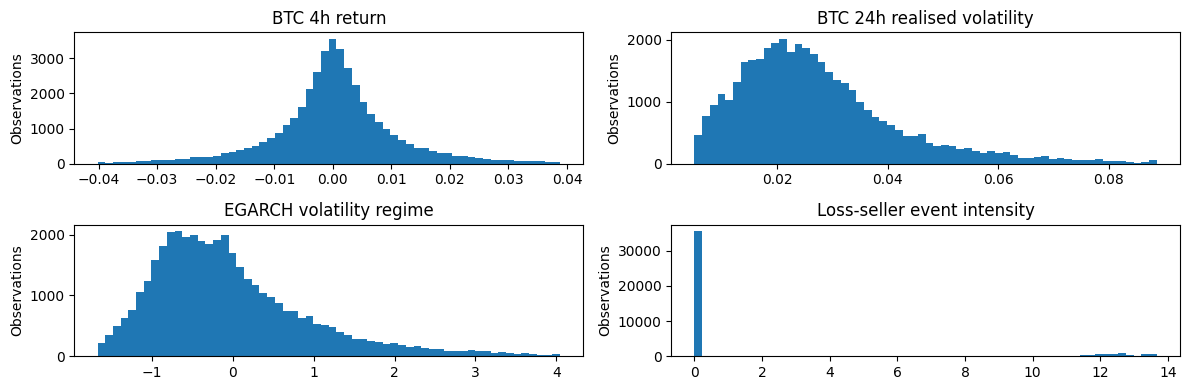

In [9]:
# Representative distributions; tails limited to 1st–99th percentiles for display only
eda_features = [("btc_ret_4h", "BTC 4h return"), ("btc_rv_24h", "BTC 24h realised volatility"), ("btc_egarch_vol_regime", "EGARCH volatility regime"),
                ("loss_seller_event_intensity", "Loss-seller event intensity")]
fig, axes = plt.subplots(2, 2, figsize=(12, 4))

for ax, (feature, title) in zip(axes.flat, eda_features):
    s = X_train[feature].dropna()
    lo, hi = s.quantile([0.01, 0.99])
    ax.hist(s[s.between(lo, hi)], bins=60)
    ax.set_title(title)
    ax.set_ylabel("Observations")

plt.tight_layout()
plt.show()

Figure 1. Representative training-feature distributions. Histograms are displayed between the 1st and 99th percentiles for visualization only.

**b) Target Distribution and Class Balance**

In [10]:
# 4-hour return distribution and provisional zero-threshold class balance
target = targets_train["fwd_logret_4h"]
y_train = target.gt(0).astype("int8")

target_summary = target.describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).to_frame("fwd_logret_4h").T

target_summary["non_positive_count"] = y_train.eq(0).sum()
target_summary["positive_count"] = y_train.eq(1).sum()
target_summary["non_positive_pct"] = y_train.eq(0).mean() * 100
target_summary["positive_pct"] = y_train.eq(1).mean() * 100

target_summary

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,non_positive_count,positive_count,non_positive_pct,positive_pct
fwd_logret_4h,"41,522.0000",0.0002,0.0132,-0.1440,-0.0402,-0.0199,-0.0047,0.0002,0.0052,0.0202,0.0388,0.1374,20275,21247,48.8295,51.1705


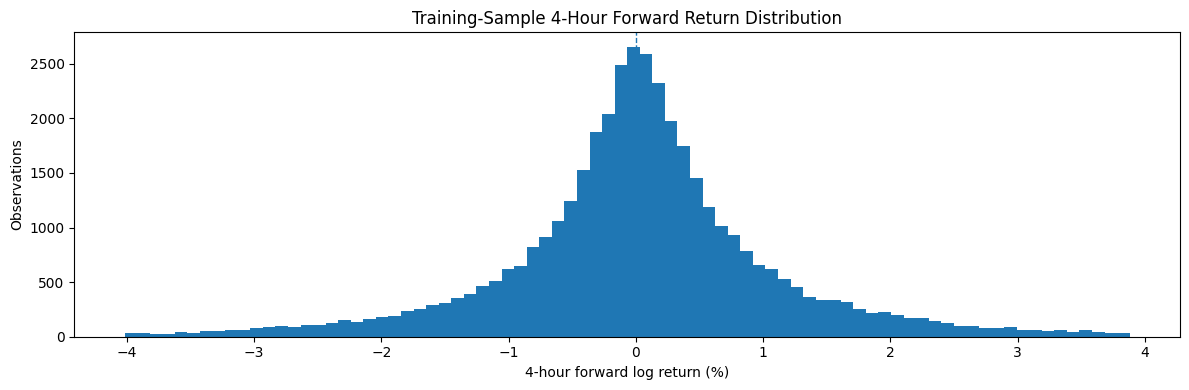

In [11]:
# Distribution of the 4-hour forward return
target_plot = target[target.between(target.quantile(0.01), target.quantile(0.99))]

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(target_plot * 100, bins=80)
ax.axvline(0, linestyle="--", linewidth=1)
ax.set_title("Training-Sample 4-Hour Forward Return Distribution")
ax.set_xlabel("4-hour forward log return (%)")
ax.set_ylabel("Observations")
plt.tight_layout()
plt.show()

The four-hour target is close to balanced, with 51.2% positive and 48.8% non-positive observations in the training sample. Consequently, severe class imbalance is not present and no class rebalancing is required at this stage.

### **c) Feature Distribution and Outlier Analysis**

In [12]:
# Distribution diagnostics for engineered training features
feature_stats = pd.DataFrame({
    "skewness": X_train.skew(),
    "excess_kurtosis": X_train.kurt(),
    "missing_count": X_train.isna().sum(),
    "missing_pct": X_train.isna().mean() * 100,
    "zero_pct": X_train.eq(0).mean() * 100})

feature_stats["abs_skewness"] = feature_stats["skewness"].abs()
feature_stats = feature_stats.sort_values("abs_skewness", ascending=False)

display(feature_stats)

,skewness,excess_kurtosis,missing_count,missing_pct,zero_pct,abs_skewness
btc_slope_4h_x_egarch_regime,136.8816,"24,519.3018",0,0.0000,0.0000,136.8816
deribit_front_roll_flag,46.7175,"2,180.6316",0,0.0000,99.9542,46.7175
btc_egarch_vol_regime,44.7605,"5,316.7006",0,0.0000,0.0000,44.7605
btc_slope_tstat_8h_x_egarch_regime,31.8029,"3,540.4439",0,0.0000,0.0000,31.8029
btc_egarch_conditional_vol,24.5734,"1,737.1765",0,0.0000,0.0000,24.5734
...,...,...,...,...,...,...
leverage_zscore_168h,-0.0040,0.1836,0,0.0000,0.0000,0.0040
btc_downside_variance_share_8h,0.0009,-1.1603,0,0.0000,0.1397,0.0009
hours_since_funding,0.0001,-1.2381,0,0.0000,12.5018,0.0001
cal_hour_cos,-0.0001,-1.5001,0,0.0000,0.0000,0.0001


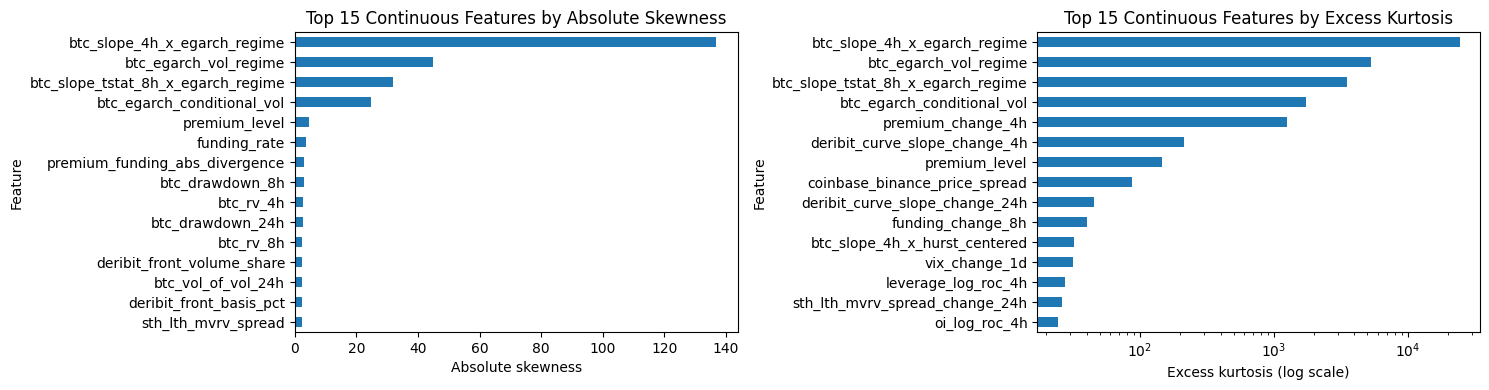

In [15]:
# Predictors with the most extreme skewness and kurtosis
n_show = 15

continuous_cols = [col for col in X_train.columns if X_train[col].nunique(dropna=True) > 2]
continuous_stats = feature_stats.loc[continuous_cols]

skew_plot = continuous_stats["abs_skewness"].nlargest(n_show).sort_values()
kurt_plot = continuous_stats["excess_kurtosis"].nlargest(n_show).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

skew_plot.plot(kind="barh", ax=axes[0])
axes[0].set_title(f"Top {n_show} Continuous Features by Absolute Skewness")
axes[0].set_xlabel("Absolute skewness")
axes[0].set_ylabel("Feature")

kurt_plot.plot(kind="barh", ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_title(f"Top {n_show} Continuous Features by Excess Kurtosis")
axes[1].set_xlabel("Excess kurtosis (log scale)")
axes[1].set_ylabel("Feature")

plt.tight_layout()
plt.show()

In [16]:
# Inspect extreme tails of the most heavy-tailed continuous features
tail_features = ["btc_egarch_conditional_vol", "btc_egarch_vol_regime",
                 "btc_slope_4h_x_egarch_regime", "btc_slope_tstat_8h_x_egarch_regime"]

tail_summary = X_train[tail_features].quantile([0, 0.001, 0.01, 0.50, 0.99, 0.999, 1]).T

tail_summary.columns = ["min", "0.1%", "1%", "median", "99%", "99.9%", "max"]
tail_summary

,min,0.1%,1%,median,99%,99.9%,max
btc_egarch_conditional_vol,0.0011,0.0015,0.0022,0.0061,0.0184,0.0274,0.3498
btc_egarch_vol_regime,-2.6269,-2.3183,-1.6720,-0.2183,4.0476,7.3596,174.2488
btc_slope_4h_x_egarch_regime,-0.3868,-0.1038,-0.0248,-0.0000,0.0208,0.0749,3.6373
btc_slope_tstat_8h_x_egarch_regime,-57.4680,-32.4605,-13.0180,-0.0345,11.2004,26.1181,531.7632


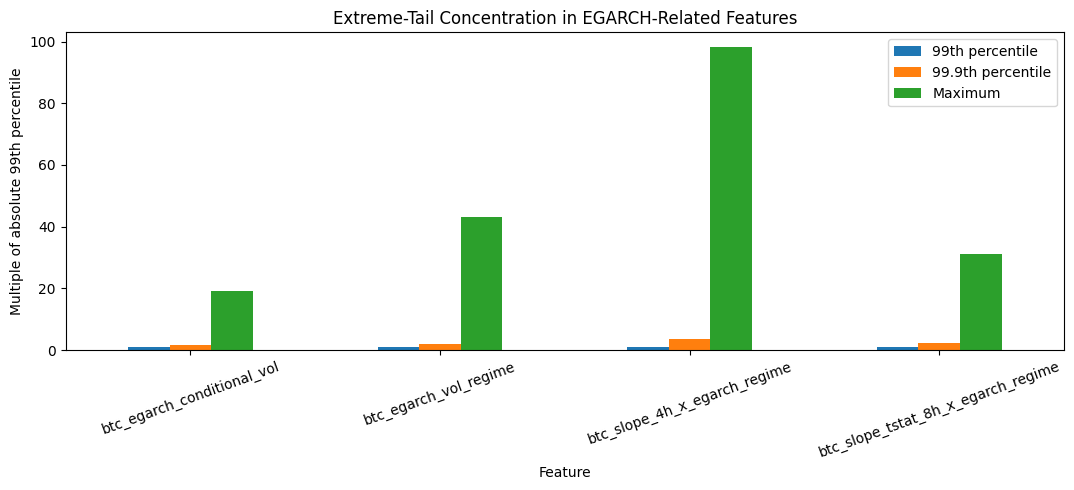

In [17]:
# Extreme-tail concentration of EGARCH-related features
abs_tail = X_train[tail_features].abs()

tail_plot = abs_tail.quantile([0.99, 0.999, 1.00]).T
tail_plot.columns = ["99th percentile", "99.9th percentile", "Maximum"]
tail_plot = tail_plot.div(tail_plot["99th percentile"], axis=0)

ax = tail_plot.plot(kind="bar", figsize=(11, 5))

ax.set_title("Extreme-Tail Concentration in EGARCH-Related Features")
ax.set_ylabel("Multiple of absolute 99th percentile")
ax.set_xlabel("Feature")
ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

Most features displayed moderate dispersion, while a small number of volatility-regime and interaction variables exhibited pronounced skewness and excess kurtosis. These observations were investigated separately before determining whether the extremes represented data errors or genuine market-state observations.

### **d) Feature Relationships and Dependence**

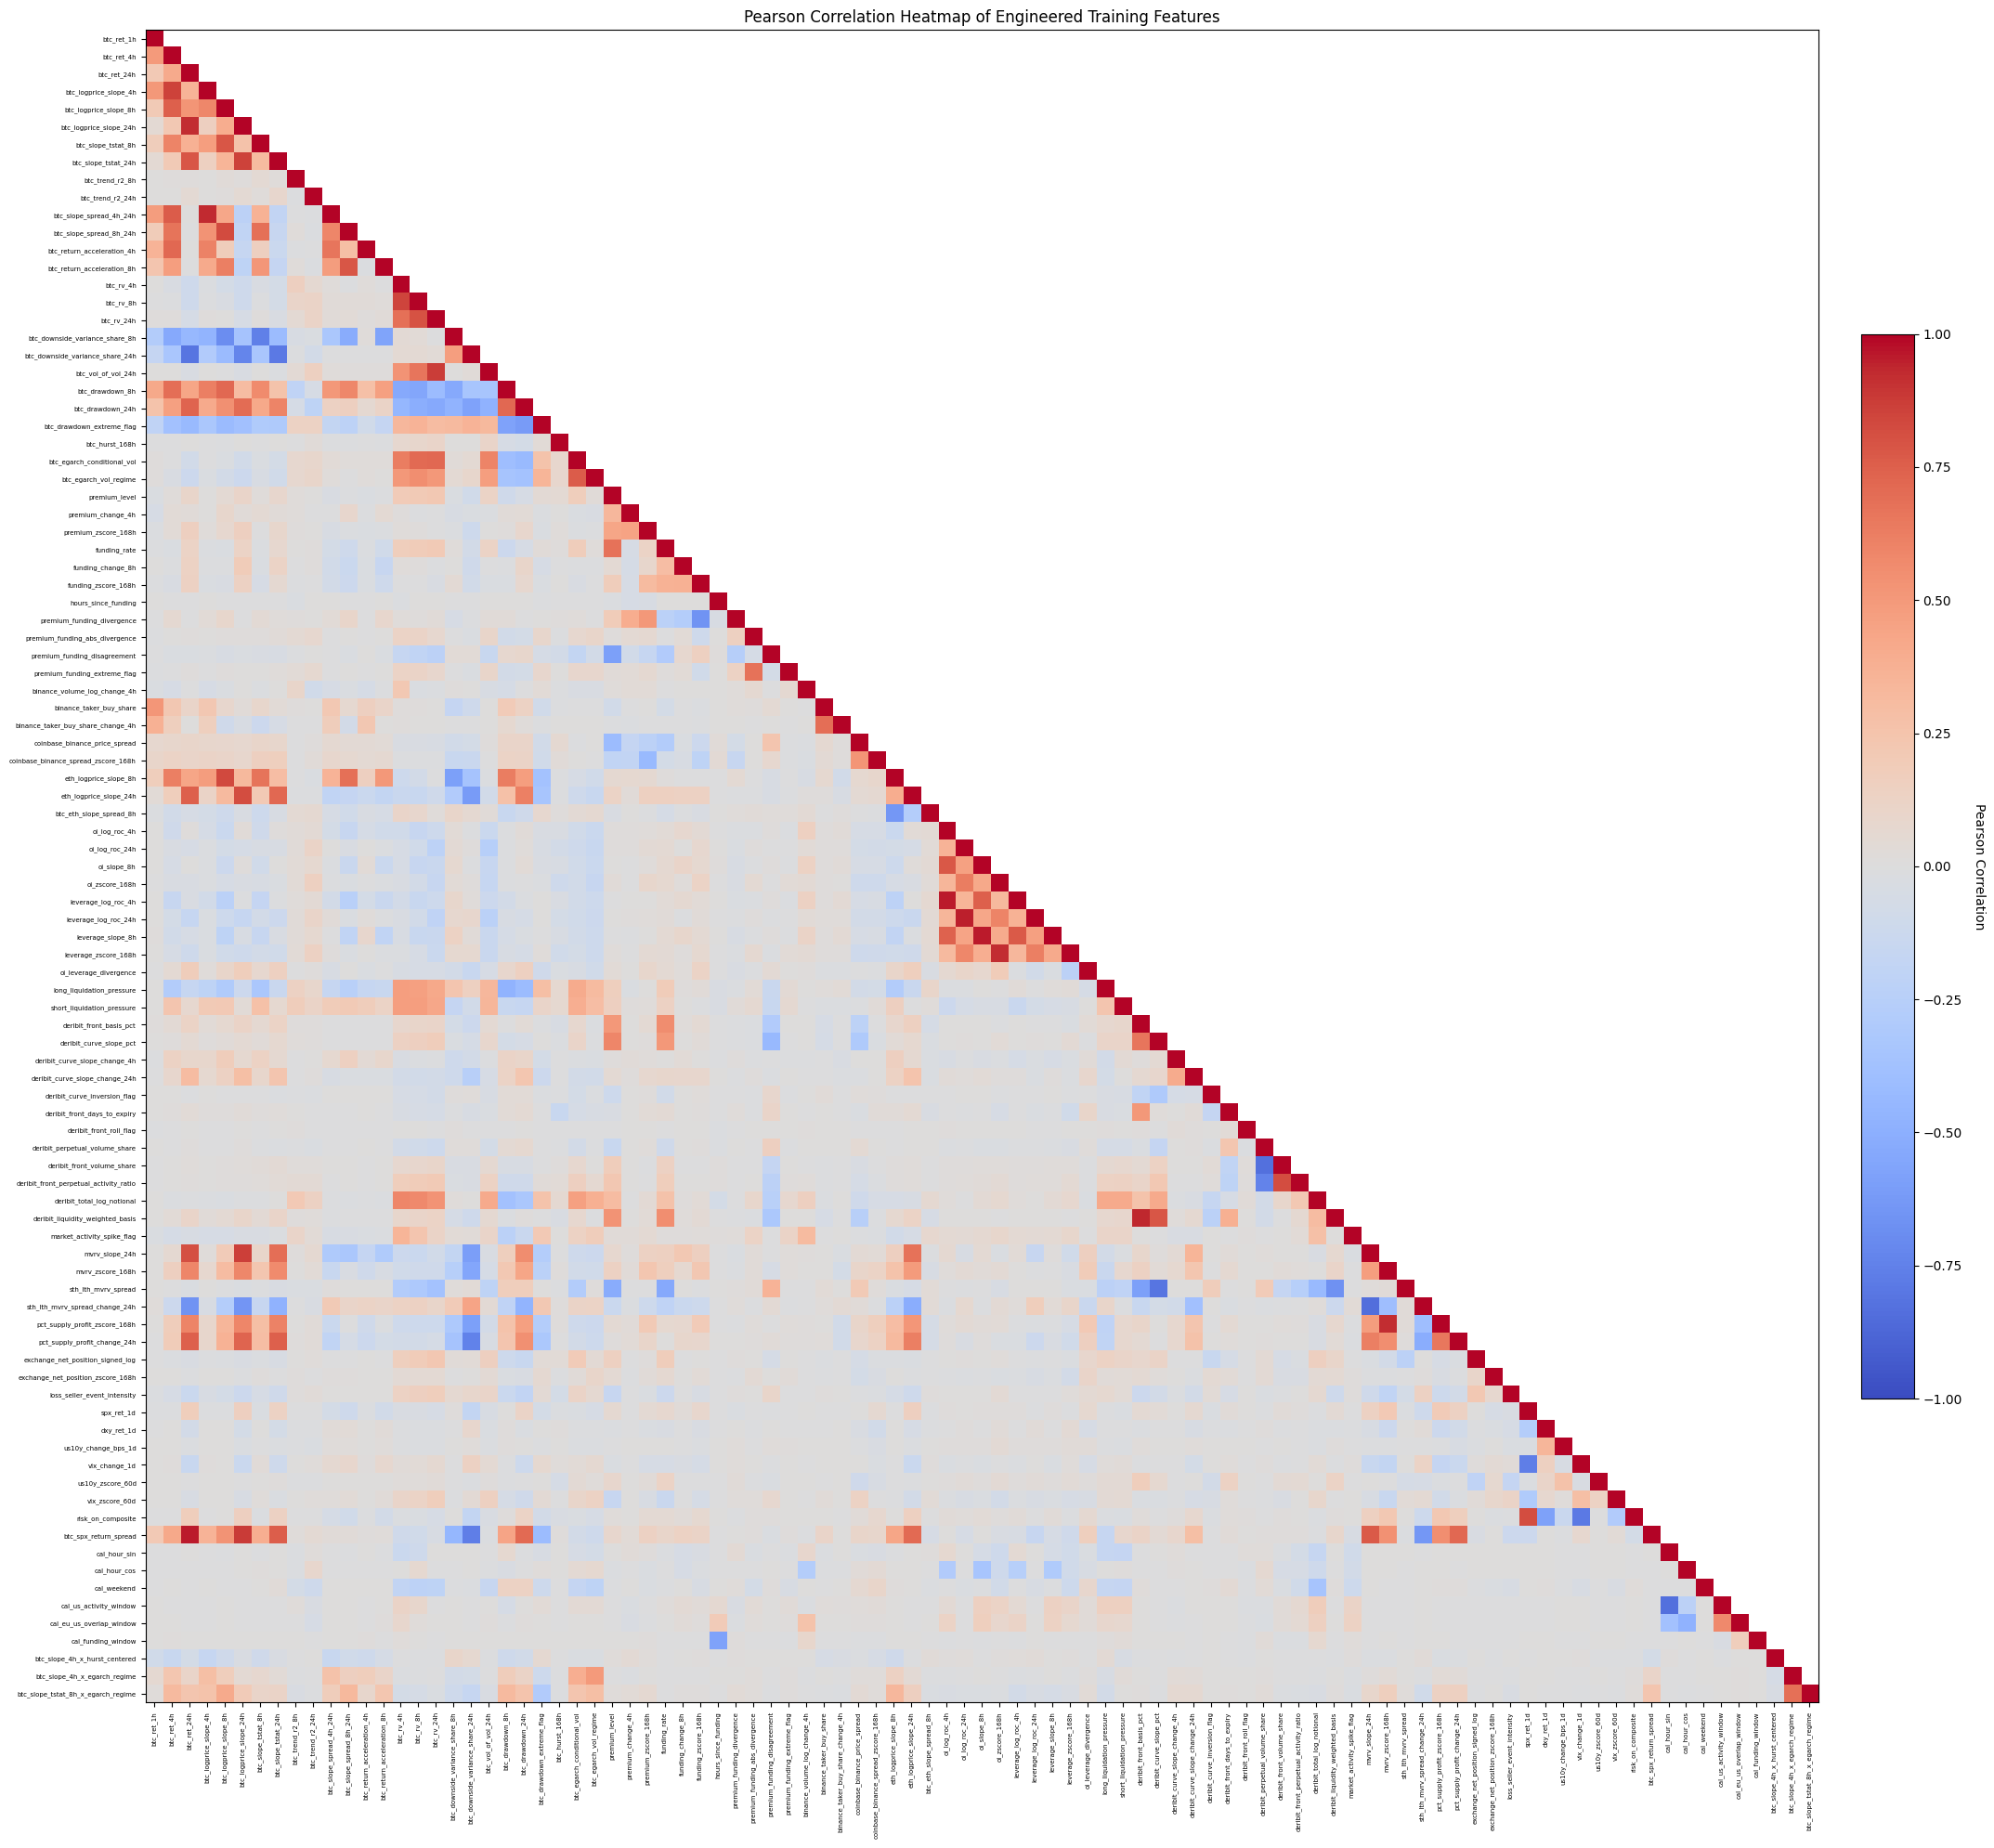

In [18]:
# Feature-to-feature Pearson correlation heatmap
feature_corr = X_train.corr(method="pearson")

upper_mask = np.triu(np.ones(feature_corr.shape, dtype=bool), k=1)
corr_plot = np.ma.masked_where(upper_mask, feature_corr.to_numpy())
fig, ax = plt.subplots(figsize=(24, 20))
heatmap = ax.imshow(corr_plot, vmin=-1, vmax=1, cmap="coolwarm", interpolation="nearest")

ax.set_xticks(range(len(feature_corr.columns)))
ax.set_yticks(range(len(feature_corr.index)))
ax.set_xticklabels(feature_corr.columns, rotation=90, fontsize=5)
ax.set_yticklabels(feature_corr.index, fontsize=5)
ax.set_title("Pearson Correlation Heatmap of Engineered Training Features")

colorbar = fig.colorbar(heatmap, ax=ax, fraction=0.025, pad=0.02)
colorbar.set_label("Pearson Correlation", rotation=270, labelpad=18)

plt.tight_layout()
plt.show()

In [19]:
# Identify highly correlated Pearson feature pairs
corr_threshold = 0.90
upper_mask = np.triu(np.ones(feature_corr.shape, dtype=bool), k=1)

high_corr_pairs = feature_corr.where(upper_mask).stack().reset_index()
high_corr_pairs.columns = ["feature_1", "feature_2", "correlation"]
high_corr_pairs["abs_correlation"] = high_corr_pairs["correlation"].abs()
high_corr_pairs = high_corr_pairs[high_corr_pairs["abs_correlation"] >= corr_threshold].sort_values("abs_correlation", ascending=False).reset_index(drop=True)

print(f"Features reviewed: {X_train.shape[1]}")
print(f"Pairs with |correlation| ≥ {corr_threshold:.2f}: {len(high_corr_pairs)}")

high_corr_pairs.style.format({
    "correlation": "{:.4f}",
    "abs_correlation": "{:.4f}"})

Features reviewed: 95
Pairs with |correlation| ≥ 0.90: 9


,feature_1,feature_2,correlation,abs_correlation
0,oi_slope_8h,leverage_slope_8h,0.9592,0.9592
1,btc_ret_24h,btc_spx_return_spread,0.9591,0.9591
2,oi_log_roc_4h,leverage_log_roc_4h,0.9575,0.9575
3,oi_log_roc_24h,leverage_log_roc_24h,0.9482,0.9482
4,deribit_front_basis_pct,deribit_liquidity_weighted_basis,0.9309,0.9309
5,btc_logprice_slope_4h,btc_slope_spread_4h_24h,0.9286,0.9286
6,mvrv_zscore_168h,pct_supply_profit_zscore_168h,0.9158,0.9158
7,oi_zscore_168h,leverage_zscore_168h,0.9156,0.9156
8,btc_ret_24h,btc_logprice_slope_24h,0.9151,0.9151


In [20]:
# Identify highly correlated Spearman feature pairs
feature_spearman = X_train.corr(method="spearman")
spearman_threshold = 0.90

upper_mask = np.triu(np.ones(feature_spearman.shape, dtype=bool), k=1)

high_spearman_pairs = feature_spearman.where(upper_mask).stack().reset_index()
high_spearman_pairs.columns = ["feature_1", "feature_2", "correlation"]
high_spearman_pairs["abs_correlation"] = high_spearman_pairs["correlation"].abs()

high_spearman_pairs = high_spearman_pairs[
    high_spearman_pairs["abs_correlation"] >= spearman_threshold
].sort_values("abs_correlation", ascending=False).reset_index(drop=True)

print(f"Features reviewed: {X_train.shape[1]}")
print(f"Pairs with |correlation| ≥ {spearman_threshold:.2f}: {len(high_spearman_pairs)}")

high_spearman_pairs.style.format({
    "correlation": "{:.4f}",
    "abs_correlation": "{:.4f}"})

Features reviewed: 95
Pairs with |correlation| ≥ 0.90: 11


,feature_1,feature_2,correlation,abs_correlation
0,deribit_front_volume_share,deribit_front_perpetual_activity_ratio,0.9973,0.9973
1,btc_logprice_slope_24h,btc_slope_tstat_24h,0.9569,0.9569
2,oi_slope_8h,leverage_slope_8h,0.9492,0.9492
3,oi_log_roc_4h,leverage_log_roc_4h,0.9467,0.9467
4,btc_logprice_slope_8h,btc_slope_tstat_8h,0.9454,0.9454
5,oi_log_roc_24h,leverage_log_roc_24h,0.9342,0.9342
6,btc_ret_24h,btc_spx_return_spread,0.9334,0.9334
7,mvrv_zscore_168h,pct_supply_profit_zscore_168h,0.9299,0.9299
8,btc_logprice_slope_24h,mvrv_slope_24h,0.9242,0.9242
9,oi_zscore_168h,leverage_zscore_168h,0.9079,0.9079


EDA note: Spearman identifies 11 feature pairs above 0.90 versus nine under Pearson, indicating additional strong monotonic relationships beyond linear dependence. The strongest is between Deribit front-volume share and the front/perpetual activity ratio (ρ=0.997). These dependencies are retained for formal review during feature selection and multicollinearity control.

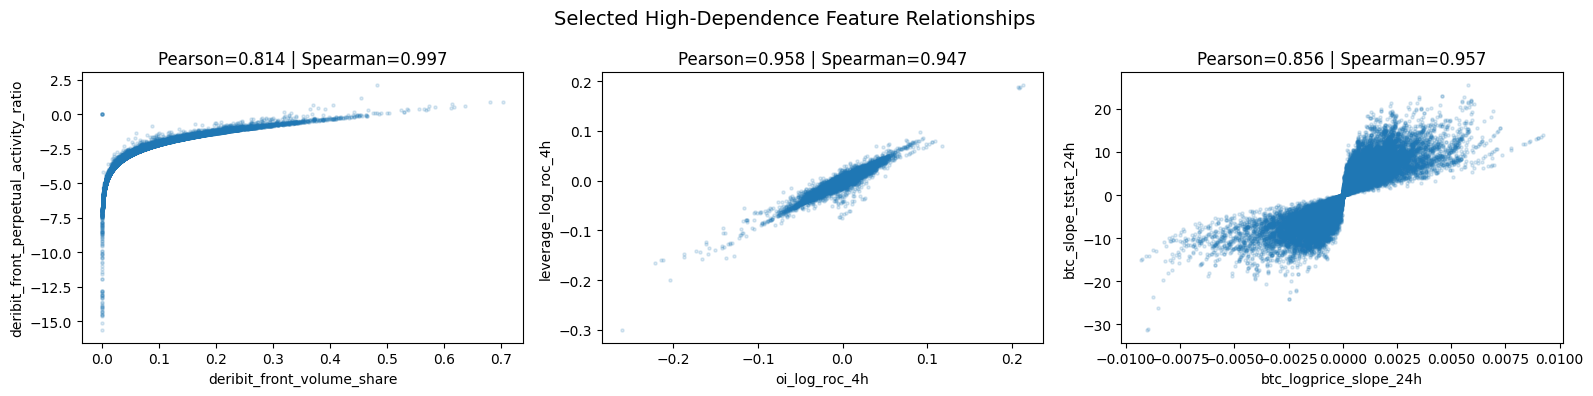

In [21]:
# Selected high-dependence feature relationships
relationship_pairs = [
    ("deribit_front_volume_share", "deribit_front_perpetual_activity_ratio"),
    ("oi_log_roc_4h", "leverage_log_roc_4h"),
    ("btc_logprice_slope_24h", "btc_slope_tstat_24h")]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (x_col, y_col) in zip(axes, relationship_pairs):
    data = X_train[[x_col, y_col]].dropna()

    pearson = data[x_col].corr(data[y_col], method="pearson")
    spearman = data[x_col].corr(data[y_col], method="spearman")

    ax.scatter(data[x_col], data[y_col], s=5, alpha=0.15)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f"Pearson={pearson:.3f} | Spearman={spearman:.3f}")

plt.suptitle("Selected High-Dependence Feature Relationships", fontsize=14)
plt.tight_layout()
plt.show()

EDA note: Selected high-dependence pairs confirm several forms of structural redundancy in the engineered feature set. Open-interest and leverage changes exhibit near-linear dependence, while Deribit front-volume share and the front/perpetual activity ratio show an almost perfectly monotonic but nonlinear relationship. BTC slope and slope t-statistics also show strong monotonic dependence while retaining different scaling and interpretation. These relationships support the use of both Pearson and Spearman diagnostics and are addressed formally during feature selection and multicollinearity control.

### **e) Temporal and Regime Behaviour**

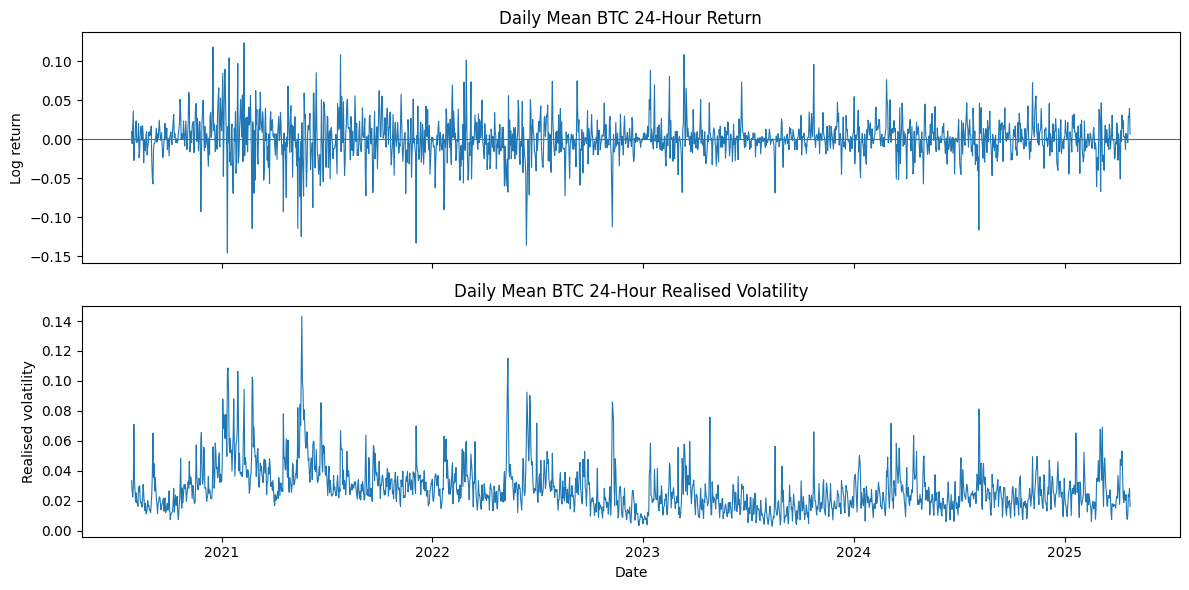

In [24]:
# BTC return and volatility behaviour through time
btc_regime = X_train[["btc_ret_24h", "btc_rv_24h"]].resample("1D").mean()
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(btc_regime.index, btc_regime["btc_ret_24h"], linewidth=0.8)
axes[0].axhline(0, linewidth=0.8)
axes[0].set_title("Daily Mean BTC 24-Hour Return")
axes[0].set_ylabel("Log return")

axes[1].plot(btc_regime.index, btc_regime["btc_rv_24h"], linewidth=0.8)
axes[1].set_title("Daily Mean BTC 24-Hour Realised Volatility")
axes[1].set_ylabel("Realised volatility")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

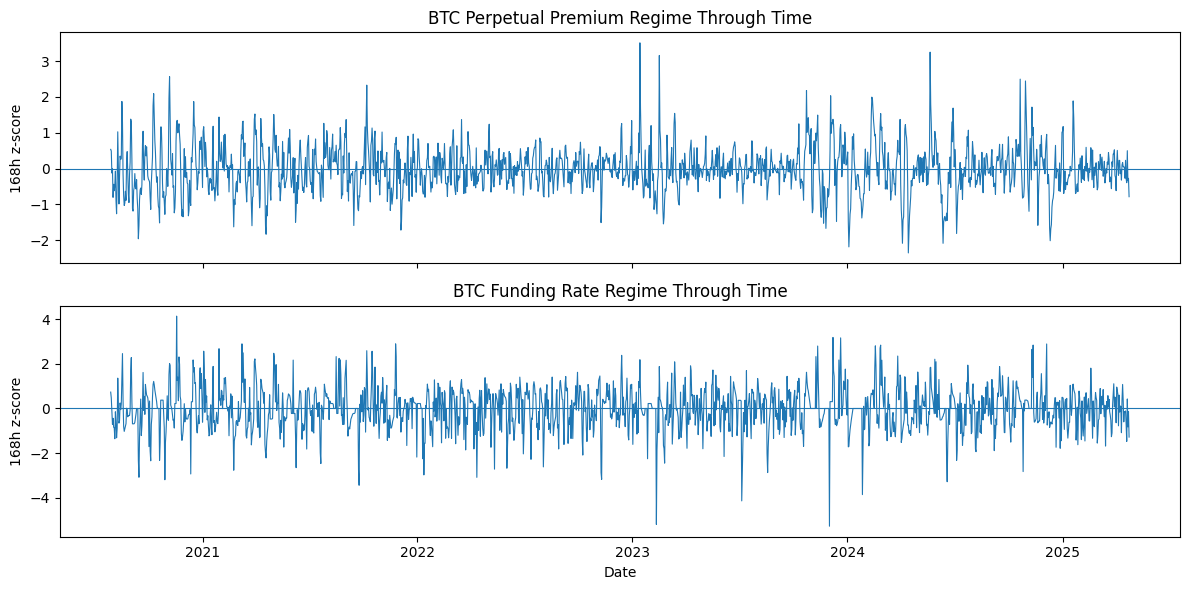

In [25]:
# Premium and funding conditions through time
derivatives_regime = X_train[["premium_zscore_168h", "funding_zscore_168h"]].resample("1D").mean()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(derivatives_regime.index, derivatives_regime["premium_zscore_168h"], linewidth=0.8)
axes[0].axhline(0, linewidth=0.8)
axes[0].set_title("BTC Perpetual Premium Regime Through Time")
axes[0].set_ylabel("168h z-score")

axes[1].plot(derivatives_regime.index, derivatives_regime["funding_zscore_168h"], linewidth=0.8)
axes[1].axhline(0, linewidth=0.8)
axes[1].set_title("BTC Funding Rate Regime Through Time")
axes[1].set_ylabel("168h z-score")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

EDA note: BTC return volatility and perpetual-market conditions vary materially through the training period. Periods of elevated realised volatility are clustered rather than uniform, while premium and funding z-scores repeatedly move through distinct positive and negative regimes. This temporal variation supports chronological model development and the inclusion of regime-dependent features.

### **f) Feature–Target Relationships**

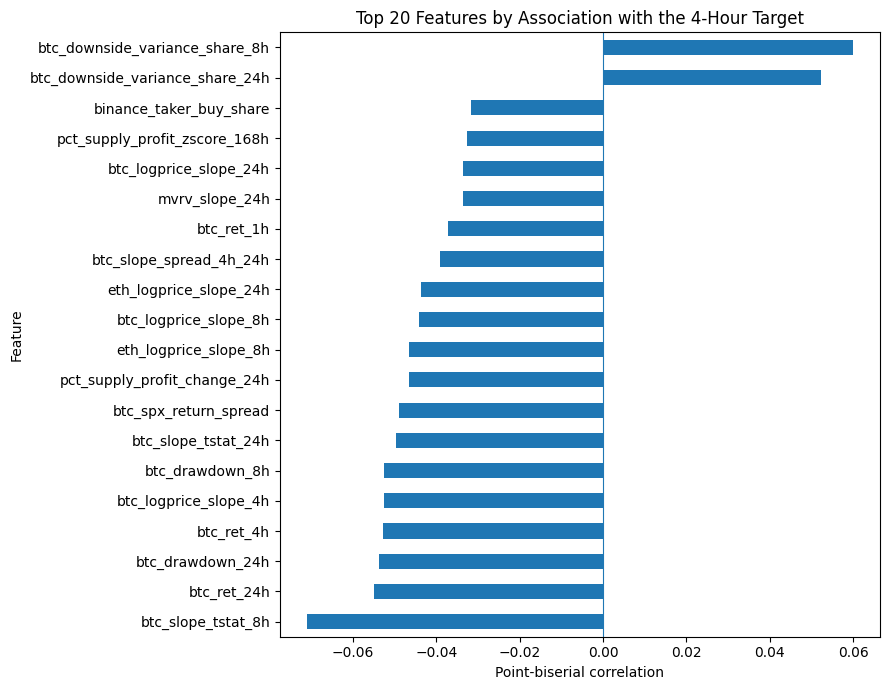

,point_biserial,abs_association
btc_slope_tstat_8h,-0.0710,0.0710
btc_downside_variance_share_8h,0.0599,0.0599
btc_ret_24h,-0.0549,0.0549
btc_drawdown_24h,-0.0537,0.0537
btc_ret_4h,-0.0529,0.0529
btc_logprice_slope_4h,-0.0526,0.0526
btc_drawdown_8h,-0.0525,0.0525
btc_downside_variance_share_24h,0.0523,0.0523
btc_slope_tstat_24h,-0.0498,0.0498
btc_spx_return_spread,-0.0491,0.0491


In [27]:
# Rank engineered features by association with the provisional sign-based 4-hour target
y_train = targets_train["fwd_logret_4h"].gt(0).astype("int8")

target_assoc = X_train.apply(lambda x: x.corr(y_train))
target_assoc = pd.DataFrame({"point_biserial": target_assoc})
target_assoc["abs_association"] = target_assoc["point_biserial"].abs()
target_assoc = target_assoc.sort_values("abs_association", ascending=False)

n_show = 20
assoc_plot = target_assoc["point_biserial"].head(n_show).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))

assoc_plot.plot(kind="barh", ax=ax)
ax.axvline(0, linewidth=0.8)
ax.set_title(f"Top {n_show} Features by Association with the 4-Hour Target")
ax.set_xlabel("Point-biserial correlation")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

target_assoc.head(20)

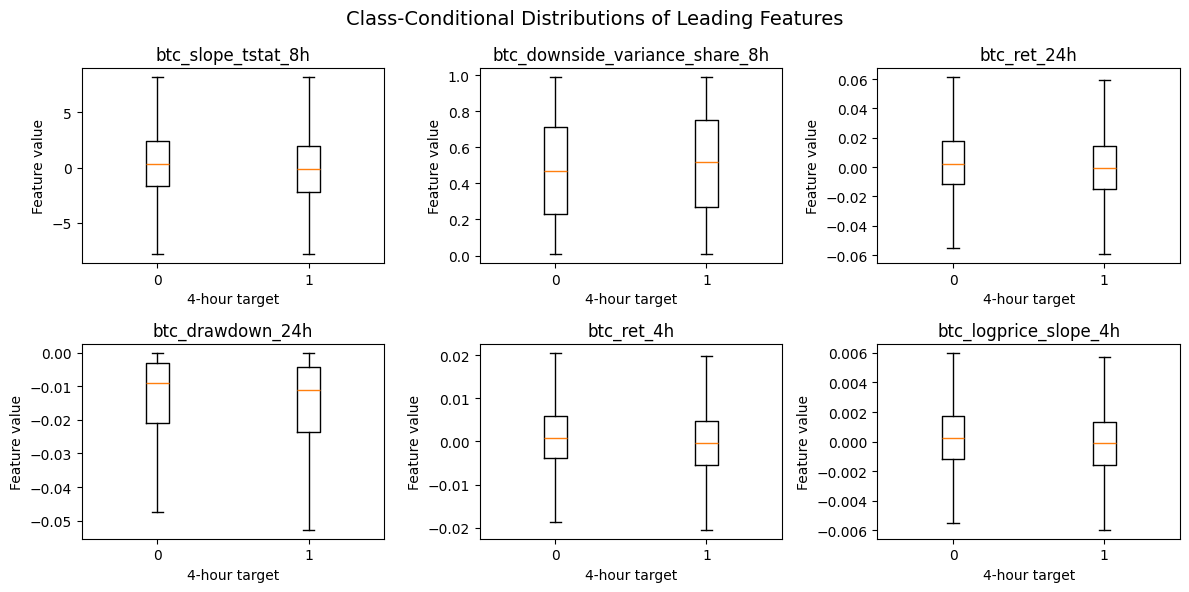

In [28]:
# Compare leading continuous features across target classes
continuous_ranked = [col for col in target_assoc.index if X_train[col].nunique(dropna=True) > 2]
top_features = continuous_ranked[:6]

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.ravel()

for ax, feature in zip(axes, top_features):
    data = pd.DataFrame({"feature": X_train[feature], "target": y_train}).dropna()
    lower, upper = data["feature"].quantile([0.01, 0.99])
    data["feature"] = data["feature"].clip(lower, upper)

    ax.boxplot([
            data.loc[data["target"].eq(0), "feature"],
            data.loc[data["target"].eq(1), "feature"]],
        tick_labels=["0", "1"], showfliers=False    )

    ax.set_title(feature)
    ax.set_xlabel("4-hour target")
    ax.set_ylabel("Feature value")

plt.suptitle("Class-Conditional Distributions of Leading Features", fontsize=14)
plt.tight_layout()
plt.show()

### **g) Near-Zero Return Treatment and Final Target Definition**

The training-sample return distribution shows that a large share of four-hour observations is concentrated close to zero. A small positive threshold is therefore considered so that marginal positive returns are not automatically labelled as meaningful up-moves.

Candidate thresholds of 0.025%, 0.05% and 0.075% are reviewed using the training sample. The final threshold is selected before feature selection and model fitting, with near-zero positive returns assigned to Class 0 rather than removed from the chronological sample.

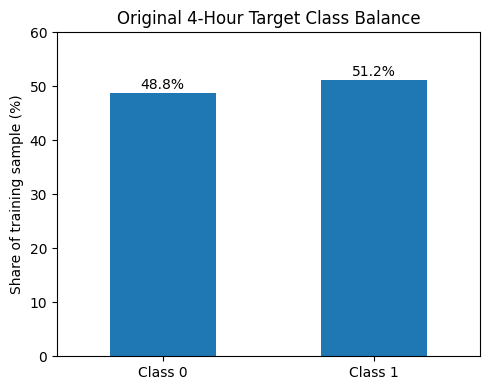

In [29]:
# Original 4-hour target class balance
target = targets_train["fwd_logret_4h"].dropna()
y_sign = target.gt(0).astype("int8")

class_balance = pd.Series({
    "Class 0": y_sign.eq(0).mean() * 100,
    "Class 1": y_sign.eq(1).mean() * 100})

fig, ax = plt.subplots(figsize=(5, 4))
class_balance.plot(kind="bar", ax=ax)

ax.set_title("Original 4-Hour Target Class Balance")
ax.set_ylabel("Share of training sample (%)")
ax.set_xlabel("")
ax.set_ylim(0, 60)
ax.tick_params(axis="x", rotation=0)

for i, value in enumerate(class_balance):
    ax.text(i, value + 0.7, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.show()

In [31]:
# Review how symmetric near-zero exclusion would affect class balance
threshold_pcts = [0.025, 0.05, 0.075]
rows = []

for pct in threshold_pcts:
    threshold = pct / 100
    retained = target.abs() > threshold
    y = target[retained].gt(0).astype("int8")
    rows.append([pct, retained.sum(), (~retained).sum(), retained.mean() * 100, y.eq(0).mean() * 100, y.eq(1).mean() * 100])

deadzone_removed = pd.DataFrame(rows, columns=[
    "threshold_pct", "retained", "removed",
    "retained_pct", "class_0_pct", "class_1_pct"])

deadzone_removed.style.format({
    "threshold_pct": "{:.3f}%",
    "retained_pct": "{:.1f}%",
    "class_0_pct": "{:.1f}%",
    "class_1_pct": "{:.1f}%"})

,threshold_pct,retained,removed,retained_pct,class_0_pct,class_1_pct
0,0.025%,40183,1339,96.8%,48.8%,51.2%
1,0.050%,38883,2639,93.6%,48.7%,51.3%
2,0.075%,37476,4046,90.3%,48.6%,51.4%


In [33]:
# Compare class balance when near-zero positive returns are assigned to Class 0
rows = []

for pct in threshold_pcts:
    threshold = pct / 100
    y = target.gt(threshold).astype("int8")
    rows.append([pct, len(y), y.eq(0).sum(), y.eq(1).sum(), y.eq(0).mean() * 100, y.eq(1).mean() * 100])

deadzone_reassigned = pd.DataFrame(rows, columns=["threshold_pct", "observations", "class_0_count", "class_1_count", "class_0_pct", "class_1_pct"])

deadzone_reassigned.style.format({
    "threshold_pct": "{:.3f}%",
    "class_0_pct": "{:.1f}%",
    "class_1_pct": "{:.1f}%"})

,threshold_pct,observations,class_0_count,class_1_count,class_0_pct,class_1_pct
0,0.025%,41522,20929,20593,50.4%,49.6%
1,0.050%,41522,21564,19958,51.9%,48.1%
2,0.075%,41522,22262,19260,53.6%,46.4%


In [34]:
# Lock final 4-hour classification target
return_threshold = 0.00025
y_train = targets_train["fwd_logret_4h"].gt(return_threshold).astype("int8")
y_train.to_frame("target_4h").to_parquet(DATA_PATH / "y_train_4h.parquet", compression="zstd", index=True)

print(f"Observations: {len(y_train):,}")
print(f"Class 0: {y_train.eq(0).mean():.1%}")
print(f"Class 1: {y_train.eq(1).mean():.1%}")

Observations: 41,522
Class 0: 50.4%
Class 1: 49.6%


Near-zero return conclusion: A 0.025% threshold is adopted for the final classification target. Returns of 0.025% or less are assigned to Class 0 rather than removed, preserving the complete chronological training sample and producing an almost balanced target of 50.4% Class 0 and 49.6% Class 1.

**Revised Problem Definition**

**Final target:**

τ=0.00025 (0.025%). Class 1 is assigned when the four-hour forward log return exceeds the threshold; all other observations are assigned to Class 0. The complete 41,522-observation training sample is retained.

## **(IV) Cleaning & Imputation**

The training feature matrix is reviewed for residual missing values and extreme observations before feature selection. Most source-level data-integrity issues were addressed during data preparation and point-in-time alignment; this stage therefore focuses on distribution-dependent treatment using the training sample only.

### **a) Residual Missing-Value Imputation**

The engineered training matrix contains only a small number of residual missing values. These are replaced with training-sample medians, which are saved for consistent application to the test sample.

In [6]:
# Impute residual missing values using training-sample medians
missing_before = X_train.isna().sum()
missing_before = missing_before[missing_before > 0]

imputation_values = X_train.median()
X_train_clean = X_train.fillna(imputation_values)

imputation_values.to_frame("median").to_parquet(DATA_PATH / "training_imputation_values_4h.parquet", compression="zstd")

print("Missing features before imputation:")
display(missing_before.to_frame("missing_count"))
print(f"Remaining missing values: {X_train_clean.isna().sum().sum():,}")

Missing features before imputation:


,missing_count
binance_taker_buy_share,1
binance_taker_buy_share_change_4h,2


Remaining missing values: 0


### **b) Extreme-Value Check**

In [7]:
# Review extreme EGARCH-related observations
tail_features = [
    "btc_egarch_conditional_vol",
    "btc_egarch_vol_regime",
    "btc_slope_4h_x_egarch_regime",
    "btc_slope_tstat_8h_x_egarch_regime"]

extreme_summary = []

for feature in tail_features:
    lower = X_train_clean[feature].quantile(0.001)
    upper = X_train_clean[feature].quantile(0.999)
    flagged = (X_train_clean[feature] < lower) | (X_train_clean[feature] > upper)

    extreme_summary.append({"feature": feature, "lower_0.1%": lower, "upper_99.9%": upper, "flagged": flagged.sum()})

extreme_summary = pd.DataFrame(extreme_summary)
display(extreme_summary.round(4))

,feature,lower_0.1%,upper_99.9%,flagged
0,btc_egarch_conditional_vol,0.0015,0.0274,84
1,btc_egarch_vol_regime,-2.3183,7.3596,84
2,btc_slope_4h_x_egarch_regime,-0.1038,0.0749,84
3,btc_slope_tstat_8h_x_egarch_regime,-32.4605,26.1181,84


Extreme-value review note: The flagged values are finite and concentrated in EGARCH-related features designed to capture unusual volatility and regime conditions. The cleaned 95-feature training matrix is reduced, first using a feature-selection funnel combining then by filter, wrapper and embedded methods.

### **c) Cleaned Training Matrix**

The cleaned training matrix is saved as the input to the subsequent feature-selection stage.

In [8]:
# Save cleaned training matrix
X_train_clean.to_parquet(DATA_PATH / "X_train_clean_4h.parquet", compression="zstd")

print(f"Cleaned training matrix: {X_train_clean.shape}")
print(f"Training period: {X_train_clean.index.min()} to {X_train_clean.index.max()}")
print(f"Remaining missing values: {X_train_clean.isna().sum().sum():,}")
print(f"Features retained: {X_train_clean.shape[1]}")

Cleaned training matrix: (41522, 95)
Training period: 2020-07-29 00:00:00+00:00 to 2025-04-24 01:00:00+00:00
Remaining missing values: 0
Features retained: 95


## **(V) Feature Selection & Scaling**

The cleaned 95-feature training matrix is reduced using a feature-selection funnel combining filter, wrapper and embedded methods. Boruta is first used as an all-relevant wrapper method to screen potentially relevant predictors, followed by correlation, exact-dependency and VIF analysis to reduce redundant and multicollinear information. SHAP provides an additional model-based importance review, while Elastic Net forms the embedded selection stage. All feature-selection decisions are based on the training sample only, with model-specific scaling applied after the final feature set is determined.

### **a) Boruta All-Relevant Feature Screening**

Boruta is used as the first supervised screening stage, comparing the importance of the observed predictors with randomized shadow features. Confirmed and tentative features are carried forward for subsequent redundancy analysis rather than treated as the final feature set.

In [11]:
# Boruta all-relevant feature screening
X_boruta = X_train_clean.copy()
y_boruta = y_train.loc[X_boruta.index]

rf = RandomForestClassifier(max_depth=5, min_samples_leaf=5, n_jobs=-1, random_state=42)
boruta = BorutaPy(rf, n_estimators="auto", perc=100, max_iter=100, random_state=42, verbose=0)
boruta.fit(X_boruta.to_numpy(), y_boruta.to_numpy())

boruta_results = pd.DataFrame({
    "feature": X_boruta.columns,
    "confirmed": boruta.support_,
    "tentative": boruta.support_weak_,
    "ranking": boruta.ranking_}).sort_values(["ranking", "feature"]).reset_index(drop=True)

boruta_keep = boruta_results.loc[boruta_results["confirmed"] | boruta_results["tentative"], "feature"].tolist()

X_train_boruta = X_boruta[boruta_keep].copy()

boruta_results.to_parquet(DATA_PATH / "boruta_results_4h.parquet", compression="zstd", index=False)
X_train_boruta.to_parquet(DATA_PATH / "X_train_boruta_4h.parquet", compression="zstd")

print(f"Candidate features: {X_boruta.shape[1]}")
print(f"Confirmed features: {boruta.support_.sum()}")
print(f"Tentative features: {boruta.support_weak_.sum()}")
print(f"Rejected features: {(~boruta.support_ & ~boruta.support_weak_).sum()}")
print(f"Features carried forward: {X_train_boruta.shape[1]}")

boruta_results

Candidate features: 95
Confirmed features: 69
Tentative features: 4
Rejected features: 22
Features carried forward: 73


,feature,confirmed,tentative,ranking
0,binance_volume_log_change_4h,True,False,1
1,btc_downside_variance_share_24h,True,False,1
2,btc_downside_variance_share_8h,True,False,1
3,btc_drawdown_24h,True,False,1
4,btc_drawdown_8h,True,False,1
...,...,...,...,...
90,premium_funding_disagreement,False,False,19
91,premium_funding_extreme_flag,False,False,21
92,cal_funding_window,False,False,22
93,deribit_curve_inversion_flag,False,False,23


### **b) High Correlation Pruning**

Pairwise Pearson correlation is reviewed after Boruta to identify strongly redundant predictors. For feature pairs with an absolute correlation of at least 0.90, the feature with the stronger absolute association with the training target is retained.

In [12]:
# Review pairwise correlation after Boruta
corr = X_train_boruta.corr()

mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)
corr_pairs = corr.where(mask).stack().reset_index()
corr_pairs.columns = ["feature_1", "feature_2", "correlation"]
corr_pairs["abs_correlation"] = corr_pairs["correlation"].abs()

high_corr_pairs = (corr_pairs[corr_pairs["abs_correlation"] >= 0.90].sort_values("abs_correlation", ascending=False).reset_index(drop=True))

print(f"Boruta features reviewed: {X_train_boruta.shape[1]}")
print(f"Pairs with |correlation| ≥ 0.90: {len(high_corr_pairs)}")

high_corr_pairs.style.format({
    "correlation": "{:.4f}",
    "abs_correlation": "{:.4f}"})

Boruta features reviewed: 73
Pairs with |correlation| ≥ 0.90: 9


,feature_1,feature_2,correlation,abs_correlation
0,leverage_slope_8h,oi_slope_8h,0.9592,0.9592
1,btc_ret_24h,btc_spx_return_spread,0.9591,0.9591
2,leverage_log_roc_4h,oi_log_roc_4h,0.9575,0.9575
3,leverage_log_roc_24h,oi_log_roc_24h,0.9482,0.9482
4,deribit_front_basis_pct,deribit_liquidity_weighted_basis,0.9309,0.9309
5,btc_logprice_slope_4h,btc_slope_spread_4h_24h,0.9286,0.9286
6,mvrv_zscore_168h,pct_supply_profit_zscore_168h,0.9158,0.9158
7,leverage_zscore_168h,oi_zscore_168h,0.9156,0.9156
8,btc_logprice_slope_24h,btc_ret_24h,0.9151,0.9151


In [13]:
# Compare target association within highly correlated pairs
target_assoc = X_train_boruta.corrwith(y_train).abs()

pair_review = high_corr_pairs.copy()
pair_review["assoc_1"] = pair_review["feature_1"].map(target_assoc)
pair_review["assoc_2"] = pair_review["feature_2"].map(target_assoc)

pair_review["keep"] = np.where(pair_review["assoc_1"] >= pair_review["assoc_2"],
                               pair_review["feature_1"], pair_review["feature_2"])

pair_review["drop"] = np.where(pair_review["assoc_1"] >= pair_review["assoc_2"],
                               pair_review["feature_2"], pair_review["feature_1"])

pair_review.style.format({
    "correlation": "{:.4f}",
    "abs_correlation": "{:.4f}",
    "assoc_1": "{:.4f}",
    "assoc_2": "{:.4f}"})

,feature_1,feature_2,correlation,abs_correlation,assoc_1,assoc_2,keep,drop
0,leverage_slope_8h,oi_slope_8h,0.9592,0.9592,0.0027,0.0042,oi_slope_8h,leverage_slope_8h
1,btc_ret_24h,btc_spx_return_spread,0.9591,0.9591,0.0533,0.0480,btc_ret_24h,btc_spx_return_spread
2,leverage_log_roc_4h,oi_log_roc_4h,0.9575,0.9575,0.0032,0.0026,leverage_log_roc_4h,oi_log_roc_4h
3,leverage_log_roc_24h,oi_log_roc_24h,0.9482,0.9482,0.0122,0.0092,leverage_log_roc_24h,oi_log_roc_24h
4,deribit_front_basis_pct,deribit_liquidity_weighted_basis,0.9309,0.9309,0.0118,0.0086,deribit_front_basis_pct,deribit_liquidity_weighted_basis
5,btc_logprice_slope_4h,btc_slope_spread_4h_24h,0.9286,0.9286,0.0544,0.0416,btc_logprice_slope_4h,btc_slope_spread_4h_24h
6,mvrv_zscore_168h,pct_supply_profit_zscore_168h,0.9158,0.9158,0.0180,0.0307,pct_supply_profit_zscore_168h,mvrv_zscore_168h
7,leverage_zscore_168h,oi_zscore_168h,0.9156,0.9156,0.0064,0.0004,leverage_zscore_168h,oi_zscore_168h
8,btc_logprice_slope_24h,btc_ret_24h,0.9151,0.9151,0.0321,0.0533,btc_ret_24h,btc_logprice_slope_24h


In [14]:
# Remove highly correlated features
correlation_drop_features = pair_review["drop"].drop_duplicates().tolist()
X_train_corr = X_train_boruta.drop(columns=correlation_drop_features).copy()

remaining_corr = X_train_corr.corr()
mask = np.triu(np.ones(remaining_corr.shape, dtype=bool), k=1)
remaining_pairs = remaining_corr.where(mask).stack().abs()
remaining_high_corr = (remaining_pairs >= 0.90).sum()

pd.DataFrame({"feature": correlation_drop_features}).to_parquet(DATA_PATH / "correlation_drops_4h.parquet", compression="zstd", index=False)
X_train_corr.to_parquet(DATA_PATH / "X_train_corr_4h.parquet", compression="zstd")

print(f"Features before pruning: {X_train_boruta.shape[1]}")
print(f"Features removed: {len(correlation_drop_features)}")
print(f"Features retained: {X_train_corr.shape[1]}")
print(f"Remaining pairs with |correlation| ≥ 0.90: {remaining_high_corr}")
print(correlation_drop_features)

Features before pruning: 73
Features removed: 9
Features retained: 64
Remaining pairs with |correlation| ≥ 0.90: 0
['leverage_slope_8h', 'btc_spx_return_spread', 'oi_log_roc_4h', 'oi_log_roc_24h', 'deribit_liquidity_weighted_basis', 'btc_slope_spread_4h_24h', 'mvrv_zscore_168h', 'oi_zscore_168h', 'btc_logprice_slope_24h']


### **c) Multicollinearity and VIF Pruning**

Following Boruta and high-correlation pruning, the remaining predictors are reviewed for exact linear dependencies and multivariate collinearity. Exact dependencies are removed first, after which variance inflation factors (VIF) are recalculated iteratively, removing the feature with the highest VIF until all retained predictors satisfy a threshold of VIF ≤ 6. This stage reduces residual redundancy before the subsequent SHAP and Elastic Net assessments.

In [16]:
# Calculate VIF after high-correlation pruning
vif_threshold = 6
X_vif = add_constant(X_train_corr)

vif = [variance_inflation_factor(X_vif.values, i) for i in range(1, X_vif.shape[1])]

vif_results = pd.DataFrame({"feature": X_train_corr.columns, "vif": vif}).sort_values("vif", ascending=False).reset_index(drop=True)
high_vif = vif_results[vif_results["vif"] > vif_threshold].copy()

vif_results.to_parquet(DATA_PATH / "vif_results_4h.parquet", compression="zstd", index=False)

print(f"Features reviewed: {len(vif_results)}")
print(f"Features with VIF > {vif_threshold}: {len(high_vif)}")

high_vif.style.format({"vif": "{:.2f}"})

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Features reviewed: 64
Features with VIF > 6: 18


,feature,vif
0,btc_eth_slope_spread_8h,inf
1,btc_logprice_slope_8h,inf
2,funding_zscore_168h,inf
3,eth_logprice_slope_8h,inf
4,premium_zscore_168h,inf
5,premium_funding_divergence,inf
6,btc_slope_spread_8h_24h,97.69
7,btc_ret_4h,64.11
8,btc_return_acceleration_4h,28.54
9,btc_ret_24h,17.29


In [17]:
# Review exact multicollinearity groups
vif_groups = [
    ["btc_logprice_slope_8h", "eth_logprice_slope_8h", "btc_eth_slope_spread_8h"],
    ["premium_zscore_168h", "funding_zscore_168h", "premium_funding_divergence"]]

features = [feature for group in vif_groups for feature in group]
vif_group_review = (X_train_corr[features].corrwith(y_train).abs().to_frame("abs_target_assoc"))

vif_group_review

,abs_target_assoc
btc_logprice_slope_8h,0.044947
eth_logprice_slope_8h,0.047630
btc_eth_slope_spread_8h,0.023018
premium_zscore_168h,0.023281
funding_zscore_168h,0.009214
premium_funding_divergence,0.009984


VIF review note: Two exact engineered dependencies are removed before VIF pruning. The remaining predictors are then reviewed iteratively, removing the feature with the highest VIF and recalculating until all retained features satisfy the threshold of VIF ≤ 6.

In [18]:
# Remove exact linear dependencies
vif_drop_features = ["btc_eth_slope_spread_8h", "premium_funding_divergence"]
X_train_vif = X_train_corr.drop(columns=vif_drop_features).copy()

print(f"Features before VIF pruning: {X_train_corr.shape[1]}")
print(f"Exact dependencies removed: {len(vif_drop_features)}")
print(f"Features retained: {X_train_vif.shape[1]}")
print(vif_drop_features)

Features before VIF pruning: 64
Exact dependencies removed: 2
Features retained: 62
['btc_eth_slope_spread_8h', 'premium_funding_divergence']


In [19]:
# Iteratively prune features with VIF above 6
vif_threshold = 6
X_train_vif_final = X_train_vif.copy()
vif_drops = []

while True:
    X_check = add_constant(X_train_vif_final)

    vif = pd.Series([
            variance_inflation_factor(X_check.values, i)
            for i in range(1, X_check.shape[1])],
        index=X_train_vif_final.columns).sort_values(ascending=False)

    if vif.iloc[0] <= vif_threshold:
        break

    feature = vif.index[0]
    vif_drops.append([feature, vif.iloc[0]])
    X_train_vif_final = X_train_vif_final.drop(columns=feature)

vif_drops = pd.DataFrame(vif_drops, columns=["feature", "vif_at_removal"])
vif_final = vif.rename("vif").reset_index().rename(columns={"index": "feature"})

vif_drops.to_parquet(DATA_PATH / "vif_drops_4h.parquet", compression="zstd", index=False)
vif_final.to_parquet(DATA_PATH / "vif_final_4h.parquet", compression="zstd", index=False)

X_train_vif_final.to_parquet(DATA_PATH / "X_train_vif_4h.parquet", compression="zstd")

print(f"Features entering iterative VIF: {X_train_vif.shape[1]}")
print(f"Features removed: {len(vif_drops)}")
print(f"Features retained: {X_train_vif_final.shape[1]}")
print(f"Maximum final VIF: {vif_final['vif'].max():.2f}")

vif_drops

Features entering iterative VIF: 62
Features removed: 10
Features retained: 52
Maximum final VIF: 5.16


,feature,vif_at_removal
0,btc_logprice_slope_8h,129.209642
1,btc_ret_4h,39.757013
2,btc_drawdown_8h,13.925670
3,btc_ret_24h,12.388634
4,btc_rv_24h,10.798687
5,btc_slope_spread_8h_24h,10.111099
6,risk_on_composite,9.390299
7,mvrv_slope_24h,8.054631
8,btc_drawdown_24h,7.100517
9,btc_rv_8h,6.336498


### **d) SHAP Analysis**

The SHAP ranking is used here as a model-based assessment to illustrate feature importance, not a feature-removal rule. An XGBoost model is fitted on an earlier portion of the training sample and evaluated on a later validation period, separated by a four-hour purge. SHAP values are calculated on the validation sample to assess nonlinear feature importance and the direction of feature effects.

In [21]:
# XGBoost SHAP feature importance
X_shap = X_train_vif_final.copy()
y_shap = y_train.loc[X_shap.index]

split = int(len(X_shap) * 0.80)
purge = 4

X_shap_train = X_shap.iloc[:split - purge]
X_shap_val = X_shap.iloc[split:]
y_shap_train = y_shap.loc[X_shap_train.index]
y_shap_val = y_shap.loc[X_shap_val.index]

shap_model = XGBClassifier(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1)

shap_model.fit(X_shap_train, y_shap_train, eval_set=[(X_shap_val, y_shap_val)], verbose=False)
shap_values = shap_model.get_booster().predict(xgb.DMatrix(X_shap_val), pred_contribs=True, iteration_range=(0, shap_model.best_iteration + 1))
shap_importance = np.abs(shap_values[:, :-1]).mean(axis=0)

shap_results = pd.DataFrame({"feature": X_shap.columns, "mean_abs_shap": shap_importance}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
shap_results["rank"] = np.arange(1, len(shap_results) + 1)

shap_results.to_parquet(DATA_PATH / "shap_results_4h.parquet", compression="zstd", index=False)
shap_model.save_model(str(DATA_PATH / "shap_selector_xgb_4h.json"))

print(f"Training rows: {len(X_shap_train):,}")
print(f"Validation rows: {len(X_shap_val):,}")
print(f"Best iteration: {shap_model.best_iteration}")
print(f"Best validation AUC: {shap_model.best_score:.4f}")
print(f"Features ranked: {len(shap_results)}")

shap_results

Training rows: 33,213
Validation rows: 8,305
Best iteration: 226
Best validation AUC: 0.5467
Features ranked: 52


,feature,mean_abs_shap,rank
0,btc_logprice_slope_4h,0.097850,1
1,btc_slope_tstat_8h,0.082867,2
2,btc_ret_1h,0.060962,3
3,btc_downside_variance_share_24h,0.037117,4
4,eth_logprice_slope_8h,0.036011,5
5,coinbase_binance_spread_zscore_168h,0.034528,6
6,cal_hour_cos,0.024329,7
7,leverage_log_roc_24h,0.024125,8
8,deribit_front_basis_pct,0.023753,9
9,us10y_zscore_60d,0.022720,10


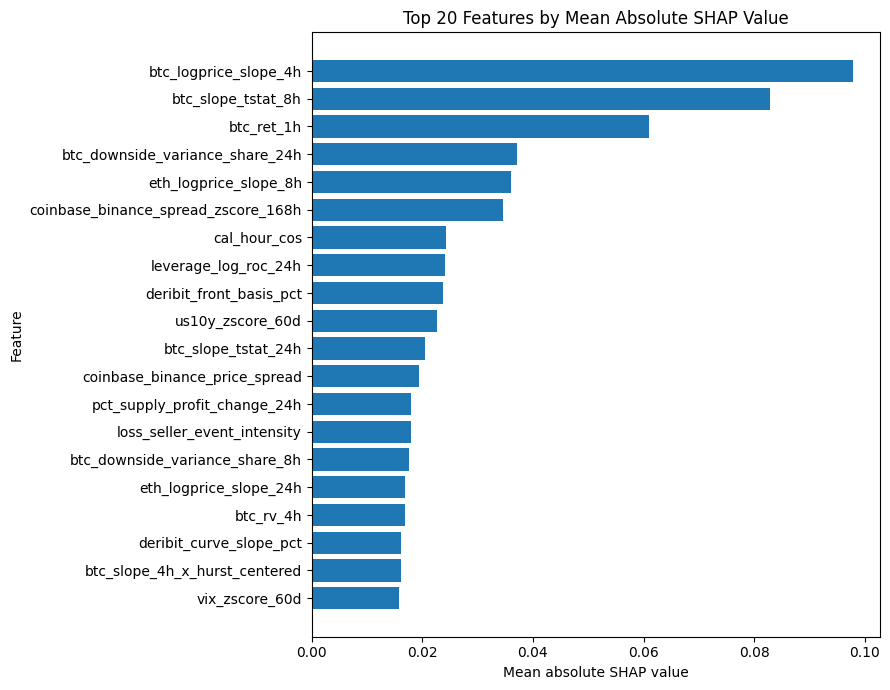

In [22]:
# Plot top SHAP feature rankings
n_show = 20
shap_plot = shap_results.head(n_show).sort_values("mean_abs_shap")

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(shap_plot["feature"], shap_plot["mean_abs_shap"])

ax.set_title(f"Top {n_show} Features by Mean Absolute SHAP Value")
ax.set_xlabel("Mean absolute SHAP value")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

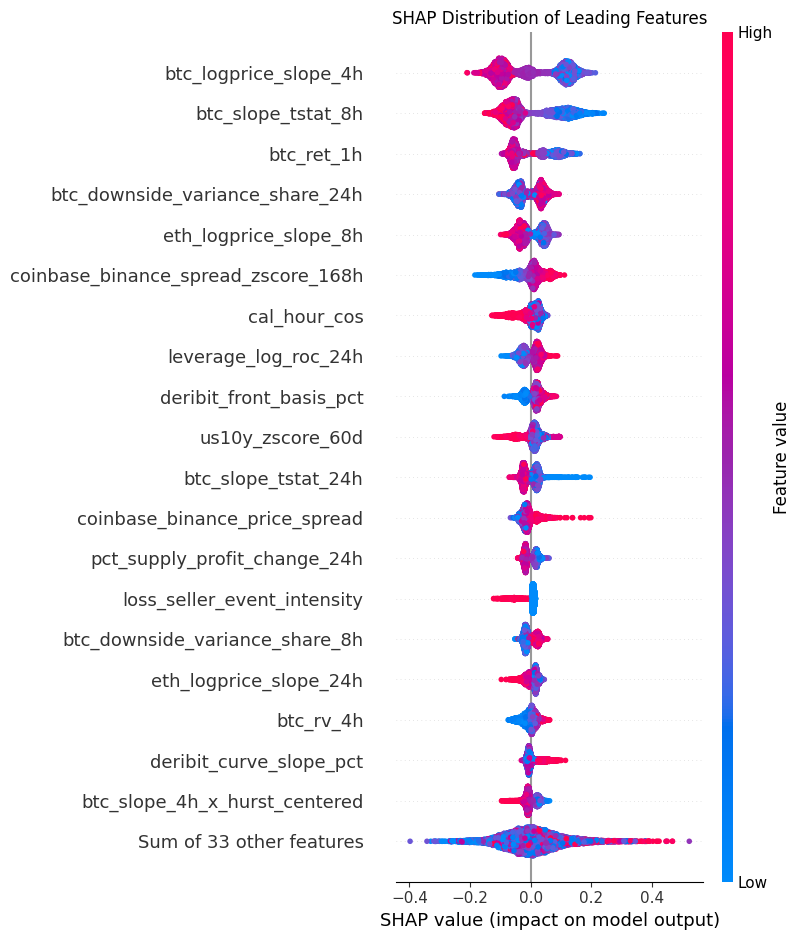

In [23]:
# SHAP distribution for the validation sample
shap_explanation = shap.Explanation(
    values=shap_values[:, :-1],
    base_values=shap_values[:, -1],
    data=X_shap_val.to_numpy(),
    feature_names=X_shap_val.columns)

shap.plots.beeswarm(shap_explanation, max_display=20, show=False)

plt.title("SHAP Distribution of Leading Features")
plt.tight_layout()
plt.show()

SHAP review note: After VIF pruning reduced the feature set to 52 predictors, the XGBoost model achieved a validation AUC of 0.5467 and stopped at iteration 226. The leading features remain concentrated in short-horizon BTC trend, slope significance and return measures, while cross-exchange, derivatives, volatility, ETH, macro and on-chain variables also appear among the higher-ranked predictors.

This supports the presence of potentially complementary information across several economic feature groups rather than reliance on a single dominant predictor. SHAP is retained as the nonlinear model-based ranking before comparison with Elastic Net embedded selection.

### **e) Elastic Net Embedded Feature Selection**

Elastic Net logistic regression is used as the embedded feature-selection stage. Hyperparameters are tuned using chronological cross-validation with a four-hour gap, while feature stability is reviewed across folds using selection frequency, sign consistency and standardized coefficient magnitude. Rather than imposing an arbitrary feature-count cutoff, the final retained set is determined by the non-zero coefficients of the best Elastic Net specification fitted to the full training sample.

In [24]:
# Elastic Net embedded feature selection
X_elastic = X_train_vif_final.copy()
y_elastic = y_train.loc[X_elastic.index]

cv = TimeSeriesSplit(n_splits=5, gap=4)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        max_iter=5000,
        random_state=42))])

param_grid = {
    "model__C": [0.01, 0.05, 0.10, 0.50, 1.00],
    "model__l1_ratio": [0.25, 0.50, 0.75, 0.90]}

search = GridSearchCV(
    pipe,
    param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True)

search.fit(X_elastic, y_elastic)

best_c = search.best_params_["model__C"]
best_l1 = search.best_params_["model__l1_ratio"]

coef_rows = []
fold_aucs = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_elastic), 1):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            C=best_c,
            l1_ratio=best_l1,
            max_iter=5000,
            random_state=42))])

    model.fit(X_elastic.iloc[train_idx], y_elastic.iloc[train_idx])
    prob = model.predict_proba(X_elastic.iloc[val_idx])[:, 1]

    fold_aucs.append(roc_auc_score(y_elastic.iloc[val_idx], prob))
    coef_rows.append(
        pd.Series(
            model.named_steps["model"].coef_[0],
            index=X_elastic.columns,
            name=f"fold_{fold}"))

coef_matrix = pd.DataFrame(coef_rows)

selected = coef_matrix.abs().gt(1e-8)
nonzero = selected.sum()
positive = coef_matrix.gt(1e-8).sum()
negative = coef_matrix.lt(-1e-8).sum()

sign_consistency = pd.concat([positive, negative], axis=1).max(axis=1)
sign_consistency = sign_consistency.div(nonzero.replace(0, np.nan)).fillna(0)

full_coef = pd.Series(search.best_estimator_.named_steps["model"].coef_[0], index=X_elastic.columns)

elastic_net_results = pd.DataFrame({
    "feature": X_elastic.columns,
    "selection_frequency": nonzero.div(len(coef_matrix)).values,
    "sign_consistency": sign_consistency.values,
    "median_abs_coef": coef_matrix.abs().median().values,
    "median_coef": coef_matrix.median().values,
    "full_coef": full_coef.values})

elastic_net_results["selected_full"] = (elastic_net_results["full_coef"].abs().gt(1e-8))

elastic_net_results = elastic_net_results.sort_values(
    ["selection_frequency", "sign_consistency", "median_abs_coef"],
    ascending=False).reset_index(drop=True)

elastic_net_results["rank"] = np.arange(1, len(elastic_net_results) + 1)

cv_results = pd.DataFrame(search.cv_results_)[[
    "param_model__C",
    "param_model__l1_ratio",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].rename(columns={
    "param_model__C": "C",
    "param_model__l1_ratio": "l1_ratio",
    "mean_test_score": "mean_auc",
    "std_test_score": "std_auc",
    "rank_test_score": "rank"})

cv_results.to_parquet(DATA_PATH / "elastic_net_cv_4h.parquet", compression="zstd", index=False)
elastic_net_results.to_parquet(DATA_PATH / "elastic_net_stability_4h.parquet", compression="zstd", index=False)

joblib.dump(search.best_estimator_, DATA_PATH / "elastic_net_selector_4h.joblib")

print(f"Features reviewed: {X_elastic.shape[1]}")
print(f"Best C: {best_c}")
print(f"Best l1 ratio: {best_l1}")
print(f"Best CV AUC: {search.best_score_:.4f}")
print(f"Mean fold AUC: {np.mean(fold_aucs):.4f}")
print(f"Selected in full fit: {elastic_net_results['selected_full'].sum()}")

elastic_net_results

Features reviewed: 52
Best C: 0.01
Best l1 ratio: 0.9
Best CV AUC: 0.5463
Mean fold AUC: 0.5463
Selected in full fit: 32


,feature,selection_frequency,sign_consistency,median_abs_coef,median_coef,full_coef,selected_full,rank
0,btc_slope_tstat_8h,1.0,1.00,0.079153,-0.079153,-0.112511,True,1
1,btc_return_acceleration_4h,1.0,1.00,0.039924,-0.039924,-0.039223,True,2
2,coinbase_binance_price_spread,1.0,1.00,0.026320,0.026320,0.014982,True,3
3,loss_seller_event_intensity,1.0,1.00,0.017294,-0.017294,-0.043540,True,4
4,cal_hour_cos,1.0,1.00,0.016403,-0.016403,-0.012910,True,5
5,coinbase_binance_spread_zscore_168h,0.8,1.00,0.038165,0.038165,0.038874,True,6
6,btc_slope_tstat_24h,0.8,1.00,0.019935,-0.019935,-0.037319,True,7
7,btc_logprice_slope_4h,0.8,1.00,0.016622,-0.016622,-0.022697,True,8
8,btc_slope_4h_x_hurst_centered,0.8,1.00,0.014555,-0.014555,-0.028825,True,9
9,leverage_log_roc_24h,0.8,1.00,0.013290,0.013290,0.007343,True,10


In [25]:
# Freeze final Elastic Net feature set
final_selection = elastic_net_results.loc[elastic_net_results["selected_full"], ["feature", "rank"]].rename(columns={"rank": "elastic_net_rank"})
final_features = final_selection["feature"].tolist()
X_train_final = X_train_vif_final[final_features].copy()

final_selection.to_parquet(DATA_PATH / "final_selected_features_4h.parquet", compression="zstd", index=False)
X_train_final.to_parquet(DATA_PATH / "X_train_final_4h.parquet", compression="zstd")

print(f"Final selected features: {len(final_features)}")
print(f"Final training matrix: {X_train_final.shape}")

final_features

Final selected features: 32
Final training matrix: (41522, 32)


['btc_slope_tstat_8h',
 'btc_return_acceleration_4h',
 'coinbase_binance_price_spread',
 'loss_seller_event_intensity',
 'cal_hour_cos',
 'coinbase_binance_spread_zscore_168h',
 'btc_slope_tstat_24h',
 'btc_logprice_slope_4h',
 'btc_slope_4h_x_hurst_centered',
 'leverage_log_roc_24h',
 'btc_ret_1h',
 'premium_zscore_168h',
 'pct_supply_profit_change_24h',
 'eth_logprice_slope_24h',
 'exchange_net_position_signed_log',
 'deribit_front_basis_pct',
 'btc_slope_tstat_8h_x_egarch_regime',
 'btc_downside_variance_share_24h',
 'btc_trend_r2_8h',
 'binance_taker_buy_share',
 'vix_change_1d',
 'leverage_log_roc_4h',
 'binance_volume_log_change_4h',
 'btc_rv_4h',
 'deribit_curve_slope_pct',
 'funding_rate',
 'us10y_zscore_60d',
 'spx_ret_1d',
 'sth_lth_mvrv_spread_change_24h',
 'us10y_change_bps_1d',
 'exchange_net_position_zscore_168h',
 'btc_hurst_168h']

Elastic Net review note: After VIF pruning reduced the feature set to 52 predictors, the tuned Elastic Net achieved a mean chronological CV AUC of 0.5463 with C=0.01 and an L1 ratio of 0.9. The fitted model retained 32 non-zero features, while the leading predictors also showed high selection frequency and stable coefficient signs across chronological folds. The retained set spans BTC price and trend, cross-exchange and CEX activity, derivatives and leverage, on-chain, macro, ETH and calendar information. These 32 predictors are therefore frozen as the final supervised feature set for subsequent scaling, unsupervised analysis and model development.

### **f) Unsupervised Structure with Self-Organizing Maps**

A Self-Organizing Map (SOM) is applied to the final 32-feature set to examine nonlinear structure beyond pairwise correlation. The SOM is trained on standardized predictors without using the target variable, mapping similar observations to nearby nodes. The U-matrix highlights local separation across the map, while component planes show how selected predictors vary across the same structure. Target labels are overlaid only after training for interpretation and do not influence the SOM.

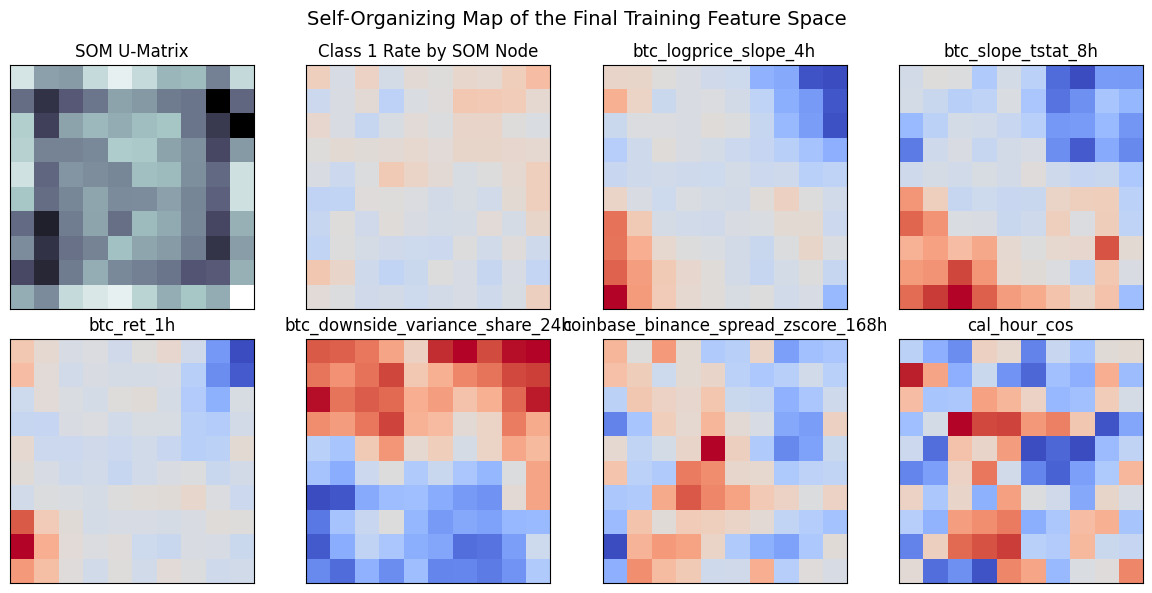

SOM training observations: 41,522
Features mapped: 32


In [31]:
# Self-Organizing Map of the final selected feature space
X_som = X_train_final.copy()
y_som = y_train.loc[X_som.index]

som_scaler = StandardScaler()
X_som_scaled = som_scaler.fit_transform(X_som)

som_size = 10
som = MiniSom(som_size, som_size, X_som.shape[1], sigma=1.5, learning_rate=0.5, random_seed=42)
som.pca_weights_init(X_som_scaled)
som.train_random(X_som_scaled, 20000)

bmu = np.array([som.winner(row) for row in X_som_scaled])

som_labels = pd.DataFrame({"x": bmu[:, 0], "y": bmu[:, 1], "target": y_som.to_numpy()})
target_map = som_labels.groupby(["x", "y"])["target"].mean().unstack()
target_map = target_map.reindex(index=range(som_size), columns=range(som_size)).T

top_features = shap_results.loc[shap_results["feature"].isin(final_features), "feature"].head(6).tolist()
weights = som.get_weights()

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.ravel()

axes[0].imshow(som.distance_map().T, origin="lower", cmap="bone_r")
axes[0].set_title("SOM U-Matrix")

axes[1].imshow(target_map, origin="lower", vmin=0, vmax=1, cmap="coolwarm")
axes[1].set_title("Class 1 Rate by SOM Node")

for ax, feature in zip(axes[2:], top_features):
    idx = X_som.columns.get_loc(feature)
    ax.imshow(weights[:, :, idx].T, origin="lower", cmap="coolwarm")
    ax.set_title(feature)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Self-Organizing Map of the Final Training Feature Space", fontsize=14)
plt.tight_layout()
plt.show()

joblib.dump(som_scaler, DATA_PATH / "som_scaler_4h.joblib")
joblib.dump(som, DATA_PATH / "som_model_4h.joblib")

print(f"SOM training observations: {len(X_som):,}")
print(f"Features mapped: {X_som.shape[1]}")

In [32]:
# Quantify SOM quality and node occupancy
som_node_stats = pd.DataFrame({
    "x": bmu[:, 0],
    "y": bmu[:, 1],
    "target": y_som.to_numpy()
}).groupby(["x", "y"], as_index=False).agg(observations=("target", "size"), class1_rate=("target", "mean"))

qe = som.quantization_error(X_som_scaled)
te = som.topographic_error(X_som_scaled)

print(f"Quantization error: {qe:.4f}")
print(f"Topographic error: {te:.4f}")
print(f"Occupied nodes: {len(som_node_stats)} / {som_size ** 2}")
print(f"Mean observations per occupied node: {som_node_stats['observations'].mean():.1f}")
print(f"Median observations per occupied node: {som_node_stats['observations'].median():.0f}")
print(f"Minimum node observations: {som_node_stats['observations'].min()}")
print(f"Maximum node observations: {som_node_stats['observations'].max()}")

Quantization error: 4.2043
Topographic error: 0.3793
Occupied nodes: 100 / 100
Mean observations per occupied node: 415.2
Median observations per occupied node: 414
Minimum node observations: 85
Maximum node observations: 912


SOM review note: The 10×10 SOM provides broad coverage of the training sample, with all 100 nodes occupied and a median of 414 observations per node. The topographic error of 0.3793 indicates that the 32-dimensional feature structure cannot be projected onto the two-dimensional map without meaningful neighbourhood distortion. The SOM is therefore retained as an exploratory visualization of nonlinear structure and market-state variation rather than as a precise low-dimensional representation.

In [33]:
# Quantify target differentiation across SOM nodes
node_id = bmu[:, 0] * som_size + bmu[:, 1]
overall_rate = y_som.mean()

weighted_sd = np.sqrt(np.average((som_node_stats["class1_rate"] - overall_rate) ** 2, weights=som_node_stats["observations"]))

well_populated = som_node_stats[som_node_stats["observations"] >= 100]

contingency = pd.crosstab(node_id, y_som.to_numpy())
chi2, _, _, _ = chi2_contingency(contingency)
n = contingency.to_numpy().sum()
cramers_v = np.sqrt(chi2 / (n * min(contingency.shape[0] - 1, contingency.shape[1] - 1)))

som_node_stats.to_parquet(DATA_PATH / "som_node_stats_4h.parquet", compression="zstd", index=False)

print(f"Overall Class 1 rate: {overall_rate:.4f}")
print(f"Weighted SD of node Class 1 rates: {weighted_sd:.4f}")
print(f"Class 1 range, all nodes: {som_node_stats['class1_rate'].min():.4f} to {som_node_stats['class1_rate'].max():.4f}")
print(f"Nodes with >=100 observations: {len(well_populated)}")
print(f"Class 1 range, >=100 obs: {well_populated['class1_rate'].min():.4f} to {well_populated['class1_rate'].max():.4f}")
print(f"Cramer's V, SOM node vs target: {cramers_v:.4f}")

som_node_stats.sort_values("class1_rate", ascending=False).head(10)

Overall Class 1 rate: 0.4960
Weighted SD of node Class 1 rates: 0.0476
Class 1 range, all nodes: 0.3908 to 0.6484
Nodes with >=100 observations: 96
Class 1 range, >=100 obs: 0.3908 to 0.6089
Cramer's V, SOM node vs target: 0.0951


,x,y,observations,class1_rate
99,9,9,91,0.648352
1,0,1,98,0.612245
68,6,8,721,0.608877
78,7,8,273,0.604396
35,3,5,441,0.600907
88,8,8,286,0.590909
89,8,9,164,0.585366
9,0,9,196,0.581633
95,9,5,284,0.580986
94,9,4,226,0.579646


SOM target-differentiation note: The SOM shows modest variation in the target distribution across the nonlinear feature space. The overall Class 1 rate is 49.6%, while well-populated nodes range from 39.1% to 60.9%, with a weighted node-level standard deviation of 4.8 percentage points. However, Cramér's V of 0.095 indicates only a weak overall association between SOM-node membership and the target. The SOM is therefore retained as an exploratory market-state diagnostic rather than as an additional feature-selection or classification mechanism.

### **g) Final Feature Distribution Review**

The final 32 predictors are reviewed for scale dispersion, skewness and remaining tail behaviour before model development. This post-selection review documents the distributional differences that may affect scale-sensitive algorithms. No further features are removed at this stage; scaling requirements are assessed using descriptive statistics, with the selected transformations fitted within the relevant model pipelines using training data only.

In [34]:
# Review distributions of the final selected features
final_feature_stats = pd.DataFrame({
    "missing": X_train_final.isna().sum(),
    "mean": X_train_final.mean(),
    "std": X_train_final.std(),
    "median": X_train_final.median(),
    "min": X_train_final.min(),
    "q01": X_train_final.quantile(0.01),
    "q99": X_train_final.quantile(0.99),
    "max": X_train_final.max(),
    "skew": X_train_final.skew(),
    "kurtosis": X_train_final.kurtosis()}).reset_index(names="feature")

final_feature_stats["abs_skew"] = final_feature_stats["skew"].abs()
final_feature_stats = final_feature_stats.sort_values("abs_skew", ascending=False).reset_index(drop=True)
final_feature_stats.to_parquet(DATA_PATH / "final_feature_distribution_4h.parquet", compression="zstd", index=False)

print(f"Final observations: {X_train_final.shape[0]:,}")
print(f"Final features: {X_train_final.shape[1]}")
print(f"Missing values: {X_train_final.isna().sum().sum():,}")

final_feature_stats

Final observations: 41,522
Final features: 32
Missing values: 0


,feature,missing,mean,std,median,min,q01,q99,max,skew,kurtosis,abs_skew
0,btc_slope_tstat_8h_x_egarch_regime,0,-1.903675e-01,4.836635,-3.454562e-02,-5.746796e+01,-13.018017,11.200365,531.763172,31.802900,3540.443868,31.802900
1,funding_rate,0,1.240729e-04,0.000217,1.000000e-04,-1.191720e-03,-0.000137,0.001155,0.002490,3.761580,21.535032,3.761580
2,btc_rv_4h,0,1.011854e-02,0.008670,7.610996e-03,1.232214e-04,0.001153,0.042872,0.121671,2.766798,14.223888,2.766798
3,deribit_front_basis_pct,0,1.101538e+00,1.244556,8.007066e-01,-9.034098e+00,-0.493873,6.033654,10.659039,2.205227,7.956110,2.205227
4,loss_seller_event_intensity,0,1.808878e+00,4.424614,0.000000e+00,0.000000e+00,0.000000,13.671201,14.001381,2.047852,2.224085,2.047852
5,leverage_log_roc_24h,0,5.668995e-05,0.028555,1.445674e-03,-3.907988e-01,-0.087918,0.066867,0.210305,-1.342581,14.451954,1.342581
6,leverage_log_roc_4h,0,6.859767e-06,0.012850,5.762549e-04,-3.010065e-01,-0.039366,0.032448,0.193074,-1.316446,27.334108,1.316446
7,coinbase_binance_price_spread,0,2.366539e-04,0.000935,3.350204e-04,-2.932383e-02,-0.001934,0.002450,0.028203,1.219183,87.976041,1.219183
8,vix_change_1d,0,3.267665e-03,1.572411,0.000000e+00,-1.871000e+01,-3.490000,4.910000,15.290001,1.105699,31.464677,1.105699
9,deribit_curve_slope_pct,0,2.018427e+00,1.411158,1.881237e+00,-5.076210e+00,-0.245070,6.433739,8.283461,0.955180,1.344225,0.955180


Distribution review note: The final feature set remains heterogeneous in scale and distribution. Several predictors retain substantial skewness and tail behaviour, while others are bounded or comparatively regular. This supports model-specific preprocessing rather than applying a single common transformation across all predictors.

In [35]:
# Group final features by tail behaviour
final_feature_stats["tail_group"] = "Regular"

severe = final_feature_stats["abs_skew"].gt(2) | final_feature_stats["kurtosis"].gt(20)
moderate = (final_feature_stats["abs_skew"].gt(1) | final_feature_stats["kurtosis"].gt(8)) & ~severe

final_feature_stats.loc[moderate, "tail_group"] = "Moderate tail"
final_feature_stats.loc[severe, "tail_group"] = "Severe tail"

tail_review = final_feature_stats[["feature", "skew", "kurtosis", "tail_group"]].copy()
tail_review["group_order"] = tail_review["tail_group"].map({"Severe tail": 0, "Moderate tail": 1, "Regular": 2})
tail_review = tail_review.sort_values(["group_order", "kurtosis"], ascending=[True, False]).drop(columns="group_order").reset_index(drop=True)

print(tail_review["tail_group"].value_counts())
tail_review

tail_group
Regular          17
Severe tail      10
Moderate tail     5
Name: count, dtype: int64


,feature,skew,kurtosis,tail_group
0,btc_slope_tstat_8h_x_egarch_regime,31.802900,3540.443868,Severe tail
1,coinbase_binance_price_spread,1.219183,87.976041,Severe tail
2,btc_slope_4h_x_hurst_centered,0.475052,32.340337,Severe tail
3,vix_change_1d,1.105699,31.464677,Severe tail
4,leverage_log_roc_4h,-1.316446,27.334108,Severe tail
5,sth_lth_mvrv_spread_change_24h,0.680874,26.002211,Severe tail
6,funding_rate,3.761580,21.535032,Severe tail
7,btc_rv_4h,2.766798,14.223888,Severe tail
8,deribit_front_basis_pct,2.205227,7.956110,Severe tail
9,loss_seller_event_intensity,2.047852,2.224085,Severe tail


### **h) Scaling Specification for Scale-Sensitive Models**

Bounded predictors are assigned MinMax scaling, while features with moderate or severe tail behaviour use robust scaling and the remaining predictors use standard scaling. The preprocessor is left unfitted here and is fitted within each scale-sensitive model pipeline; tree-based models use the unscaled feature matrix.


| Data behaviour                     | Treatment before model                |
| ---------------------------------- | ------------------------------------- |
| Heavy-tailed / outlier-sensitive   | **RobustScaler**                      |
| Approximately symmetric, unbounded | **StandardScaler**                    |
| Naturally bounded / range-type     | **MinMaxScaler**                      |
| Tree-based models                  | raw/pass-through; scaling unnecessary |


In [36]:
# Define scaling for scale-sensitive models
minmax_features = [
    "cal_hour_cos",
    "btc_trend_r2_8h",
    "btc_downside_variance_share_24h",
    "binance_taker_buy_share",
    "btc_hurst_168h"]

robust_features = tail_review.loc[tail_review["tail_group"].ne("Regular"), "feature"].tolist()
robust_features = [feature for feature in robust_features if feature not in minmax_features]

standard_features = [feature for feature in final_features if feature not in robust_features + minmax_features]

model_preprocessor = ColumnTransformer([
    ("robust", RobustScaler(), robust_features),
    ("minmax", MinMaxScaler(), minmax_features),
    ("standard", StandardScaler(), standard_features)], verbose_feature_names_out=False)

scaling_spec = pd.DataFrame({"feature": final_features})
scaling_spec["scaler"] = scaling_spec["feature"].map(
    lambda f: "RobustScaler" if f in robust_features else "MinMaxScaler" if f in minmax_features else "StandardScaler")

scaling_spec.to_parquet(DATA_PATH / "final_scaling_specification_4h.parquet", compression="zstd", index=False)

print(f"RobustScaler: {len(robust_features)}")
print(f"MinMaxScaler: {len(minmax_features)}")
print(f"StandardScaler: {len(standard_features)}")
print(f"Total features: {len(final_features)}")

scaling_spec

RobustScaler: 15
MinMaxScaler: 5
StandardScaler: 12
Total features: 32


,feature,scaler
0,btc_slope_tstat_8h,StandardScaler
1,btc_return_acceleration_4h,RobustScaler
2,coinbase_binance_price_spread,RobustScaler
3,loss_seller_event_intensity,RobustScaler
4,cal_hour_cos,MinMaxScaler
5,coinbase_binance_spread_zscore_168h,StandardScaler
6,btc_slope_tstat_24h,StandardScaler
7,btc_logprice_slope_4h,RobustScaler
8,btc_slope_4h_x_hurst_centered,RobustScaler
9,leverage_log_roc_24h,RobustScaler


Scaling review note: The final 32-feature set requires heterogeneous preprocessing. Fifteen heavy-tailed predictors are assigned robust scaling, five naturally bounded predictors use MinMax scaling, and the remaining twelve use standard scaling. These transformations are fitted within the relevant scale-sensitive model pipelines, while tree-based models use the unscaled features.

## **VI. Model Building and Optimization**

### **a) Chronological Base-Training and Blend-Validation Split**

The training sample is divided chronologically into a base-training set and a blend-validation set. The first 75% is used to fit and tune the base learners, while the final 25% is reserved for generating the predictions used to train the blending meta-model. Four observations are purged from the end of the base-training period so that its four-hour forward-return labels do not overlap the blend-validation period. The separate final test sample remains untouched.

In [6]:
# a) Chronological base-training and blend-validation split
blend_start = int(len(X_train_final) * 0.75)
purge = 4

X_base = X_train_final.iloc[:blend_start - purge]
y_base = y_train.loc[X_base.index]

X_blend = X_train_final.iloc[blend_start:]
y_blend = y_train.loc[X_blend.index]

X_base.to_parquet(DATA_PATH / "X_base_train_4h.parquet", compression="zstd")
X_blend.to_parquet(DATA_PATH / "X_blend_validation_4h.parquet", compression="zstd")
y_base.to_frame("target").to_parquet(DATA_PATH / "y_base_train_4h.parquet", compression="zstd")
y_blend.to_frame("target").to_parquet(DATA_PATH / "y_blend_validation_4h.parquet", compression="zstd")

print(f"Base training: {len(X_base):,} rows")
print(f"Blend validation: {len(X_blend):,} rows")
print(f"Purged observations: {purge}")
print(f"Base period: {X_base.index.min()} to {X_base.index.max()}")
print(f"Blend period: {X_blend.index.min()} to {X_blend.index.max()}")
print(f"Base Class 1 rate: {y_base.mean():.4f}")
print(f"Blend Class 1 rate: {y_blend.mean():.4f}")

Base training: 31,137 rows
Blend validation: 10,381 rows
Purged observations: 4
Base period: 2020-07-29 00:00:00+00:00 to 2024-02-16 08:00:00+00:00
Blend period: 2024-02-16 13:00:00+00:00 to 2025-04-24 01:00:00+00:00
Base Class 1 rate: 0.4945
Blend Class 1 rate: 0.5004


### **b) Base-Learner Candidate Screening**

Eight conventional machine-learning classifiers are screened across distinct learning families. Each model is evaluated using five-fold chronological cross-validation on the base-training sample, with a four-hour purge gap between training and validation folds.

Scale-sensitive models use the feature-specific preprocessing pipeline fitted within each training fold, while tree-based models are evaluated on the original unscaled features. ROC-AUC is used as the common screening metric. The results are used to identify candidates for subsequent tuning and blending analysis.

| Model                | ML family                  | Role                           |
| -------------------- | -------------------------- | ------------------------------ |
| Logistic Regression  | Linear / parametric        | Linear benchmark               |
| Gaussian Naive Bayes | Probabilistic / generative | Distribution-based             |
| KNN                  | Instance / distance-based  | Local neighbourhood            |
| RBF SVM              | Kernel                     | Nonlinear decision boundary    |
| Decision Tree        | Single tree                | Rule / threshold-based         |
| Random Forest        | Bagging ensemble           | Randomized tree ensemble       |
| CatBoost             | Boosting ensemble          | Sequential boosted trees       |
| XGBoost              | Boosting ensemble          | Alternative boosted-tree model |


In [7]:
# b) Screen base-learner candidates
cv_base = TimeSeriesSplit(n_splits=5, gap=4)

scaled_models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, random_state=42),
    "Gaussian NB": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "RBF SVM": SVC(kernel="rbf")}

tree_models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=1),
    "CatBoost": CatBoostClassifier(iterations=300, verbose=False, random_seed=42, thread_count=1),
    "XGBoost": XGBClassifier(n_estimators=300, eval_metric="auc", tree_method="hist", random_state=42, n_jobs=1)}

screen_rows = []

for name, model in scaled_models.items():
    pipe = Pipeline([
        ("preprocessor", clone(model_preprocessor)),
        ("model", model)])
    scores = cross_val_score(pipe, X_base, y_base, cv=cv_base, scoring="roc_auc", n_jobs=-1)
    screen_rows.append([name, scores.mean(), scores.std()])

for name, model in tree_models.items():
    scores = cross_val_score(model, X_base, y_base, cv=cv_base, scoring="roc_auc", n_jobs=-1)
    screen_rows.append([name, scores.mean(), scores.std()])

base_screen = pd.DataFrame(screen_rows, columns=["model", "mean_auc", "std_auc"]).sort_values("mean_auc", ascending=False).reset_index(drop=True)
base_screen["rank"] = np.arange(1, len(base_screen) + 1)
base_screen.to_parquet(DATA_PATH / "base_model_screen_4h.parquet", compression="zstd", index=False)

base_screen

,model,mean_auc,std_auc,rank
0,Random Forest,0.557891,0.013721,1
1,RBF SVM,0.556820,0.015476,2
2,Gaussian NB,0.549900,0.020418,3
3,CatBoost,0.549412,0.021446,4
4,Logistic Regression,0.548406,0.022060,5
5,XGBoost,0.540353,0.013547,6
6,KNN,0.521128,0.006891,7
7,Decision Tree,0.507071,0.007332,8


Baseline model review: Random Forest achieved the highest mean chronological CV ROC-AUC of 0.5579, closely followed by RBF SVM at 0.5568. Gaussian Naive Bayes, CatBoost and Logistic Regression formed a second group with mean ROC-AUCs around 0.548–0.550, while XGBoost was weaker at 0.5404. KNN and the single Decision Tree showed substantially weaker predictive performance and were not retained for further tuning.

The remaining six models were carried forward to hyperparameter optimisation, preserving a range of linear, probabilistic, kernel, bagging and boosting approaches.



| Model               |   Mean AUC |    Std | Interpretation                            |
| ------------------- | ---------: | -----: | ----------------------------------------- |
| Random Forest       | **0.5579** | 0.0137 | strongest baseline candidate              |
| RBF SVM             | **0.5568** | 0.0155 | closely matched RF; distinct kernel model |
| Gaussian NB         |     0.5499 | 0.0204 | competitive probabilistic candidate       |
| CatBoost            |     0.5494 | 0.0214 | competitive boosted-tree candidate        |
| Logistic Regression |     0.5484 | 0.0221 | linear benchmark                          |
| XGBoost             |     0.5404 | 0.0135 | weaker baseline boosted-tree candidate    |
| KNN                 |     0.5211 | 0.0069 | weak predictive signal                    |
| Decision Tree       |     0.5071 | 0.0073 | near-chance performance                   |


### **c) Hyperparameter Optimization of Retained Base Learners**

Following the baseline screen, KNN and the single Decision Tree are excluded because their chronological cross-validation performance is close to random classification. The remaining six base learners are optimized using five-fold chronological cross-validation on the base-training sample only, with a four-hour purge gap between training and validation folds. Model-specific preprocessing remains fitted within each training fold where required. The blend-validation sample is not used during hyperparameter selection and remains reserved for subsequent ensemble construction.

In [8]:
# c) Tune retained base learners using chronological cross-validation
cv_tune = TimeSeriesSplit(n_splits=5, gap=4)

tune_models = {
    "Logistic Regression": (Pipeline([
            ("preprocessor", clone(model_preprocessor)),
            ("model", LogisticRegression(max_iter=3000, random_state=42))]),
            {"model__C": [0.01, 0.10, 1.00, 10.00, 100.00]}),

    "Gaussian NB": (Pipeline([
            ("preprocessor", clone(model_preprocessor)),
            ("model", GaussianNB())]),
            {"model__var_smoothing": [1e-11, 1e-10, 1e-9, 1e-8, 1e-7]}),

    "RBF SVM": (Pipeline([
            ("preprocessor", clone(model_preprocessor)),
            ("model", SVC(kernel="rbf", probability=True, cache_size=2000, random_state=42))]),
            {"model__C": [0.10, 1.00, 10.00],
            "model__gamma": ["scale", 0.01, 0.10]}),

    "Random Forest": (RandomForestClassifier(random_state=42, n_jobs=1),
            {"n_estimators": [300, 600],
            "max_depth": [6, 10, None],
            "min_samples_leaf": [1, 5, 20],
            "max_features": ["sqrt", 0.5]}),

    "CatBoost": (CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            verbose=False,
            random_seed=42,
            thread_count=1,
            allow_writing_files=False),
            {"iterations": [300, 600],
            "depth": [4, 6],
            "learning_rate": [0.03, 0.06],
            "l2_leaf_reg": [3, 7]}),

    "XGBoost": (XGBClassifier(
            objective="binary:logistic",
            eval_metric="auc",
            tree_method="hist",
            random_state=42,
            n_jobs=1),
            {"n_estimators": [300, 600],
            "max_depth": [3, 5],
            "learning_rate": [0.03, 0.06],
            "min_child_weight": [1, 5],
            "subsample": [0.8],
            "colsample_bytree": [0.8]})}

tuned_models = {}
tuning_rows = []

for name, (model, grid) in tune_models.items():
    search = GridSearchCV(model, grid, scoring="roc_auc", cv=cv_tune, n_jobs=-1, refit=True)
    search.fit(X_base, y_base)
    tuned_models[name] = search.best_estimator_
    tuning_rows.append([name, search.best_score_, str(search.best_params_)])

    joblib.dump(search.best_estimator_, DATA_PATH / f"tuned_{name.lower().replace(' ', '_')}_4h.joblib")

    print(f"{name}: AUC {search.best_score_:.4f}")
    print(search.best_params_)

tuning_results = pd.DataFrame(tuning_rows, columns=["model", "best_cv_auc", "best_parameters"]).sort_values("best_cv_auc", ascending=False).reset_index(drop=True)
tuning_results["rank"] = np.arange(1, len(tuning_results) + 1)
tuning_results.to_parquet(DATA_PATH / "base_model_tuning_4h.parquet", compression="zstd", index=False)

tuning_results

Logistic Regression: AUC 0.5513
{'model__C': 0.01}
Gaussian NB: AUC 0.5499
{'model__var_smoothing': 1e-09}


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RBF SVM: AUC 0.5584
{'model__C': 0.1, 'model__gamma': 'scale'}
Random Forest: AUC 0.5633
{'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 300}


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


CatBoost: AUC 0.5641
{'depth': 6, 'iterations': 300, 'l2_leaf_reg': 7, 'learning_rate': 0.03}
XGBoost: AUC 0.5578
{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 300, 'subsample': 0.8}


,model,best_cv_auc,best_parameters,rank
0,CatBoost,0.564085,"{'depth': 6, 'iterations': 300, 'l2_leaf_reg':...",1
1,Random Forest,0.563300,"{'max_depth': 6, 'max_features': 'sqrt', 'min_...",2
2,RBF SVM,0.558437,"{'model__C': 0.1, 'model__gamma': 'scale'}",3
3,XGBoost,0.557806,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",4
4,Logistic Regression,0.551253,{'model__C': 0.01},5
5,Gaussian NB,0.549900,{'model__var_smoothing': 1e-09},6


**Hyperparameter tuning review:** All six candidates surviving the baseline screen were optimized using chronological cross-validation. CatBoost achieved the highest mean CV ROC-AUC of **0.5641**, closely followed by Random Forest at **0.5633**. RBF SVM reached **0.5584**, while XGBoost improved substantially from its baseline ROC-AUC of 0.5404 to **0.5578**, representing the largest gain from tuning. Logistic Regression improved modestly to **0.5513**, while Gaussian Naive Bayes remained unchanged at **0.5499**. The six optimized candidates are retained for the subsequent blend-validation analysis, where model performance is considered together with the diversity of their probability forecasts rather than on tuning rank alone.


### **d) Base-Learner Blend-Validation Predictions and Diversity Review**

Each tuned base learner is applied to the blend-validation sample to generate Class 1 probability forecasts. These predictions form the candidate meta-features used in subsequent blending experiments.

Individual ROC-AUC is first examined to assess each model's ranking performance over the later validation period. Pairwise Pearson correlations between probability forecasts are then used to assess prediction similarity across learners. Lower correlation may indicate complementary information, while high correlation suggests that models are recovering similar signals.

No predictions are combined at this stage; the analysis provides the performance and diversity evidence used to construct the candidate blends.

In [9]:
# d) Generate blend-validation predictions and review model diversity

model_files = {
    "Logistic Regression": "tuned_logistic_regression_4h.joblib",
    "Gaussian NB": "tuned_gaussian_nb_4h.joblib",
    "RBF SVM": "tuned_rbf_svm_4h.joblib",
    "Random Forest": "tuned_random_forest_4h.joblib",
    "CatBoost": "tuned_catboost_4h.joblib",
    "XGBoost": "tuned_xgboost_4h.joblib"}

tuned_models = {name: joblib.load(DATA_PATH / file) for name, file in model_files.items()}

meta_feature_pool = pd.DataFrame(index=X_blend.index)
validation_auc = {}

for name, model in tuned_models.items():
    meta_feature_pool[name] = model.predict_proba(X_blend)[:, 1]
    validation_auc[name] = roc_auc_score(y_blend, meta_feature_pool[name])

blend_performance = pd.Series(validation_auc, name="validation_auc").sort_values(ascending=False).reset_index()
blend_performance = blend_performance.rename(columns={"index": "model"})
blend_performance["rank"] = np.arange(1, len(blend_performance) + 1)

blend_correlation = meta_feature_pool.corr()

meta_feature_pool.to_parquet(DATA_PATH / "blend_base_predictions_4h.parquet", compression="zstd")
blend_performance.to_parquet(DATA_PATH / "blend_base_performance_4h.parquet", compression="zstd", index=False)
blend_correlation.to_parquet(DATA_PATH / "blend_prediction_correlation_4h.parquet", compression="zstd")

print(f"Blend-validation observations: {len(meta_feature_pool):,}")
print(f"Candidate base learners: {meta_feature_pool.shape[1]}")
print("\nIndividual validation AUC:")
display(blend_performance)

print("\nCorrelation between model probability predictions:")
display(blend_correlation.round(3))

Blend-validation observations: 10,381
Candidate base learners: 6

Individual validation AUC:


,model,validation_auc,rank
0,CatBoost,0.550279,1
1,XGBoost,0.548567,2
2,RBF SVM,0.548283,3
3,Random Forest,0.547208,4
4,Gaussian NB,0.538416,5
5,Logistic Regression,0.535275,6



Correlation between model probability predictions:


,Logistic Regression,Gaussian NB,RBF SVM,Random Forest,CatBoost,XGBoost
Logistic Regression,1.000,0.509,0.854,0.775,0.783,0.781
Gaussian NB,0.509,1.000,0.594,0.546,0.502,0.486
RBF SVM,0.854,0.594,1.000,0.790,0.806,0.794
Random Forest,0.775,0.546,0.790,1.000,0.917,0.904
CatBoost,0.783,0.502,0.806,0.917,1.000,0.941
XGBoost,0.781,0.486,0.794,0.904,0.941,1.000


### **e) Candidate Blend Configurations and Equal-Weight Benchmark**

Candidate blends are specified following the base-learner performance and diversity review. The configurations compare compact heterogeneous combinations with a highly correlated tree-based consensus and broader multi-model alternatives. Each blend is first evaluated using a simple equal-weight average of its Class 1 probability forecasts, providing a benchmark before any learned meta-model is introduced.

The same candidate structures are subsequently used in the base–meta model comparison where an eligible alternative model family is available. The full six-model pool is retained as an equal-weight benchmark only because it already contains all candidate model families.

In [10]:
# e) Compare candidate blends using equal weights
candidate_blends = {
    "A - RF + SVM + GNB": ["Random Forest", "RBF SVM", "Gaussian NB"],
    "B - XGB + SVM + GNB": ["XGBoost", "RBF SVM", "Gaussian NB"],
    "C - Cat + SVM + GNB": ["CatBoost", "RBF SVM", "Gaussian NB"],
    "D - Tree Consensus": ["Random Forest", "XGBoost", "CatBoost"],
    "E - Broad Heterogeneous": ["Random Forest", "XGBoost", "RBF SVM", "Gaussian NB", "Logistic Regression"],
    "F - Full Pool": ["Random Forest", "XGBoost", "CatBoost", "RBF SVM", "Gaussian NB", "Logistic Regression"]}

blend_rows = []

for name, models in candidate_blends.items():
    probability = meta_feature_pool[models].mean(axis=1)
    blend_rows.append([name, len(models), roc_auc_score(y_blend, probability)])

equal_weight_results = pd.DataFrame(blend_rows, columns=["blend", "n_models", "equal_weight_auc"]).sort_values("equal_weight_auc", ascending=False).reset_index(drop=True)
equal_weight_results["rank"] = np.arange(1, len(equal_weight_results) + 1)
equal_weight_results.to_parquet(DATA_PATH / "equal_weight_blend_screen_4h.parquet", compression="zstd", index=False)

equal_weight_results

,blend,n_models,equal_weight_auc,rank
0,D - Tree Consensus,3,0.550060,1
1,F - Full Pool,6,0.546764,2
2,C - Cat + SVM + GNB,3,0.546470,3
3,B - XGB + SVM + GNB,3,0.545831,4
4,E - Broad Heterogeneous,5,0.545366,5
5,A - RF + SVM + GNB,3,0.544748,6


Equal-weight benchmarking favours the three-tree consensus, although its ROC-AUC is essentially identical to the strongest individual base learner. Broader and heterogeneous combinations remain competitive but do not improve ranking performance at this stage.

### **f) Base–Meta Model Rotation**

The candidate base configurations are carried forward into a controlled base–meta model rotation. For each blend, alternative meta-models are selected from algorithms not already included in its base layer. The meta-model is trained only on the corresponding base-model probability forecasts and is tuned using five-fold chronological cross-validation with a four-hour gap. This allows base-model composition and meta-model choice to be compared using the same blend-validation period. The full six-model pool is excluded from the rotation because no unused candidate algorithm remains for the meta layer.

In [11]:
# f) Compare base-meta model rotations
meta_cv = TimeSeriesSplit(n_splits=5, gap=4)

meta_options = {
    "A - RF + SVM + GNB": ["Logistic Regression", "CatBoost", "XGBoost"],
    "B - XGB + SVM + GNB": ["Logistic Regression", "Random Forest", "CatBoost"],
    "C - Cat + SVM + GNB": ["Logistic Regression", "Random Forest", "XGBoost"],
    "D - Tree Consensus": ["Logistic Regression", "RBF SVM", "Gaussian NB"],
    "E - Broad Heterogeneous": ["CatBoost"]}

meta_models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, random_state=42),
    "Gaussian NB": GaussianNB(),
    "RBF SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=1),
    "CatBoost": CatBoostClassifier(
        verbose=False,
        random_seed=42,
        thread_count=1,
        allow_writing_files=False),
    "XGBoost": XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        random_state=42,
        n_jobs=1)}

meta_grids = {
    "Logistic Regression": {"C": [0.01, 0.1, 1, 10]},
    "Gaussian NB": {"var_smoothing": [1e-9, 1e-8, 1e-7]},
    "RBF SVM": {"C": [0.1, 1, 10], "gamma": ["scale", 0.1, 1]},
    "Random Forest": {
        "n_estimators": [100, 300],
        "max_depth": [2, 4, 6],
        "min_samples_leaf": [20, 50]},
    "CatBoost": {
        "iterations": [100, 300],
        "depth": [2, 4],
        "learning_rate": [0.03, 0.05],
        "l2_leaf_reg": [3, 7]},
    "XGBoost": {
        "n_estimators": [100, 300],
        "max_depth": [2, 4],
        "learning_rate": [0.03, 0.05],
        "min_child_weight": [1, 5]}
}

meta_rows = []

for blend, meta_names in meta_options.items():
    base_models = candidate_blends[blend]
    X_meta = meta_feature_pool[base_models]

    for meta_name in meta_names:
        search = GridSearchCV(
            meta_models[meta_name],
            meta_grids[meta_name],
            scoring="roc_auc",
            cv=meta_cv,
            n_jobs=-1,
            refit=True)
        search.fit(X_meta, y_blend)

        meta_rows.append([blend,
            " + ".join(base_models),
            meta_name,
            len(base_models),
            search.best_score_,
            search.cv_results_["std_test_score"][search.best_index_],
            str(search.best_params_)])

meta_rotation_results = pd.DataFrame(meta_rows, columns=[
        "blend", "base_models", "meta_model", "n_base_models",
        "cv_auc", "cv_std", "best_parameters"]).sort_values("cv_auc", ascending=False).reset_index(drop=True)
meta_rotation_results["rank"] = np.arange(1, len(meta_rotation_results) + 1)
meta_rotation_results.to_parquet(DATA_PATH / "meta_model_rotation_4h.parquet", compression="zstd", index=False)

print(f"Base-meta scenarios tested: {len(meta_rotation_results)}")
meta_rotation_results

Base-meta scenarios tested: 13


,blend,base_models,meta_model,n_base_models,cv_auc,cv_std,best_parameters,rank
0,D - Tree Consensus,Random Forest + XGBoost + CatBoost,Gaussian NB,3,0.550850,0.009912,{'var_smoothing': 1e-09},1
1,D - Tree Consensus,Random Forest + XGBoost + CatBoost,Logistic Regression,3,0.550696,0.010285,{'C': 0.01},2
2,D - Tree Consensus,Random Forest + XGBoost + CatBoost,RBF SVM,3,0.550689,0.010261,"{'C': 0.1, 'gamma': 1}",3
3,B - XGB + SVM + GNB,XGBoost + RBF SVM + Gaussian NB,Logistic Regression,3,0.548147,0.009679,{'C': 10},4
4,C - Cat + SVM + GNB,CatBoost + RBF SVM + Gaussian NB,Logistic Regression,3,0.547957,0.009144,{'C': 10},5
5,A - RF + SVM + GNB,Random Forest + RBF SVM + Gaussian NB,Logistic Regression,3,0.546419,0.008463,{'C': 10},6
6,E - Broad Heterogeneous,Random Forest + XGBoost + RBF SVM + Gaussian N...,CatBoost,5,0.545963,0.004513,"{'depth': 4, 'iterations': 100, 'l2_leaf_reg':...",7
7,C - Cat + SVM + GNB,CatBoost + RBF SVM + Gaussian NB,Random Forest,3,0.545444,0.008326,"{'max_depth': 2, 'min_samples_leaf': 20, 'n_es...",8
8,B - XGB + SVM + GNB,XGBoost + RBF SVM + Gaussian NB,Random Forest,3,0.544857,0.006011,"{'max_depth': 2, 'min_samples_leaf': 20, 'n_es...",9
9,B - XGB + SVM + GNB,XGBoost + RBF SVM + Gaussian NB,CatBoost,3,0.542255,0.006541,"{'depth': 2, 'iterations': 100, 'l2_leaf_reg':...",10


The base–meta rotation strongly favoured the three-tree consensus configuration, with all three alternative meta-models producing mean chronological CV ROC-AUCs around 0.551. Differences among Gaussian Naive Bayes, Logistic Regression and RBF SVM meta-models were negligible relative to fold-to-fold variation, indicating that base-model composition was more influential than the specific second-level learner. Among the heterogeneous configurations, Logistic Regression consistently provided the strongest meta-model results.

### **g) Finalist Architecture Comparison on Common Validation Folds**

In [12]:
# g) Compare finalist architectures on common validation folds
B_models = ["XGBoost", "RBF SVM", "Gaussian NB"]
C_models = ["CatBoost", "RBF SVM", "Gaussian NB"]
D_models = ["Random Forest", "XGBoost", "CatBoost"]

benchmarks = {
    "Random Forest": [],
    "RBF SVM": [],
    "CatBoost": [],
    "XGBoost": [],
    "B - Logistic Meta": [],
    "C - Logistic Meta": [],
    "D - Equal Weight": [],
    "D - Gaussian NB Meta": [],
    "D - Logistic Meta": []}

B_meta = LogisticRegression(C=10, max_iter=3000, random_state=42)
C_meta = LogisticRegression(C=10, max_iter=3000, random_state=42)
D_gnb_meta = GaussianNB(var_smoothing=1e-9)
D_log_meta = LogisticRegression(C=0.01, max_iter=3000, random_state=42)

for train_idx, val_idx in meta_cv.split(meta_feature_pool):
    y_train_meta = y_blend.iloc[train_idx]
    y_val_meta = y_blend.iloc[val_idx]

    for name in ["Random Forest", "RBF SVM", "CatBoost", "XGBoost"]:
        probability = meta_feature_pool[name].iloc[val_idx]
        benchmarks[name].append(roc_auc_score(y_val_meta, probability))

    B_train = meta_feature_pool[B_models].iloc[train_idx]
    B_val = meta_feature_pool[B_models].iloc[val_idx]

    C_train = meta_feature_pool[C_models].iloc[train_idx]
    C_val = meta_feature_pool[C_models].iloc[val_idx]

    D_train = meta_feature_pool[D_models].iloc[train_idx]
    D_val = meta_feature_pool[D_models].iloc[val_idx]

    benchmarks["D - Equal Weight"].append(roc_auc_score(y_val_meta, D_val.mean(axis=1)))
    model = clone(B_meta).fit(B_train, y_train_meta)

    benchmarks["B - Logistic Meta"].append(roc_auc_score(y_val_meta, model.predict_proba(B_val)[:, 1]))
    model = clone(C_meta).fit(C_train, y_train_meta)

    benchmarks["C - Logistic Meta"].append(roc_auc_score(y_val_meta, model.predict_proba(C_val)[:, 1]))
    model = clone(D_gnb_meta).fit(D_train, y_train_meta)

    benchmarks["D - Gaussian NB Meta"].append(roc_auc_score(y_val_meta, model.predict_proba(D_val)[:, 1]))
    model = clone(D_log_meta).fit(D_train, y_train_meta)

    benchmarks["D - Logistic Meta"].append(roc_auc_score(y_val_meta, model.predict_proba(D_val)[:, 1]))

comparison_rows = []

for name, scores in benchmarks.items():
    comparison_rows.append([name, np.mean(scores), np.std(scores), *scores])

blend_cv_comparison = pd.DataFrame(comparison_rows, columns=["model", "cv_auc", "cv_std", "fold_1", "fold_2",
                                                             "fold_3", "fold_4", "fold_5"]).sort_values("cv_auc", ascending=False).reset_index(drop=True)
blend_cv_comparison["rank"] = np.arange(1, len(blend_cv_comparison) + 1)
blend_cv_comparison.to_parquet(DATA_PATH / "blend_finalist_cv_comparison_4h.parquet", compression="zstd", index=False)

blend_cv_comparison

,model,cv_auc,cv_std,fold_1,fold_2,fold_3,fold_4,fold_5,rank
0,D - Gaussian NB Meta,0.550850,0.009912,0.556139,0.559612,0.560787,0.539043,0.538669,1
1,XGBoost,0.550750,0.010533,0.553150,0.561910,0.561557,0.536240,0.540894,2
2,D - Logistic Meta,0.550696,0.010285,0.556570,0.559984,0.560474,0.537336,0.539118,3
3,D - Equal Weight,0.550666,0.009952,0.555557,0.559683,0.560758,0.538406,0.538927,4
4,RBF SVM,0.549842,0.011891,0.556829,0.564361,0.553008,0.529352,0.545658,5
5,CatBoost,0.549195,0.011363,0.559840,0.557820,0.557693,0.535123,0.535498,6
6,Random Forest,0.548172,0.008212,0.548223,0.553060,0.559379,0.545452,0.534745,7
7,B - Logistic Meta,0.548147,0.009679,0.542975,0.558495,0.559248,0.533729,0.546287,8
8,C - Logistic Meta,0.547957,0.009144,0.548721,0.557360,0.557496,0.533420,0.542786,9


The three-tree D configuration is consistently competitive with the strongest individual learner, but neither learned meta-model nor equal weighting produces a material average uplift.

### **h) Final Meta-Model Inspection**

The selected D tree-consensus architecture is inspected before final model fitting. Logistic Regression coefficients are estimated across the same chronological meta-validation folds to assess the direction and stability of the contribution from Random Forest, XGBoost and CatBoost probability forecasts. Because all three meta-features are Class 1 probabilities on the same scale, the coefficient patterns provide a simple diagnostic of how the learned second layer combines the three tree-based signals.

In [15]:
# h) Inspect final Logistic meta-model behaviour
D_models = ["Random Forest", "XGBoost", "CatBoost"]
D_coef = []

for train_idx, val_idx in meta_cv.split(meta_feature_pool):
    X_meta_train = meta_feature_pool[D_models].iloc[train_idx]
    y_meta_train = y_blend.iloc[train_idx]

    model = LogisticRegression(C=0.01, max_iter=3000, random_state=42)
    model.fit(X_meta_train, y_meta_train)

    D_coef.append(model.coef_[0])

D_coef = pd.DataFrame(D_coef, columns=D_models)

D_inspection = pd.DataFrame({"base_model": D_models, "mean_coefficient": D_coef.mean().values, "median_coefficient": D_coef.median().values,
                             "sign_consistency": np.maximum((D_coef > 0).mean(), (D_coef < 0).mean()).values})
D_inspection.to_parquet(DATA_PATH / "meta_D_logistic_inspection_4h.parquet", compression="zstd", index=False)

D_inspection.round(4)

,base_model,mean_coefficient,median_coefficient,sign_consistency
0,Random Forest,0.0873,0.0901,1.0
1,XGBoost,0.1392,0.1474,1.0
2,CatBoost,0.1603,0.1691,1.0


Meta-model inspection: All three tree-based probability forecasts receive positive Logistic Regression coefficients across every chronological fold. CatBoost receives the largest average coefficient, followed by XGBoost and Random Forest, while coefficient signs remain fully consistent. The result suggests that the learned meta-model retains contributions from all three base learners, although the small performance difference relative to equal weighting indicates that the second layer primarily reweights an already similar consensus signal.

### **i) Final Blending Architecture Freeze**

Training-stage model selection is now closed. The D tree-consensus configuration is frozen as the primary blending architecture, using Random Forest, XGBoost and CatBoost probability forecasts with Logistic Regression as the meta-model. The corresponding equal-weight tree consensus is retained as a simple ensemble benchmark, while CatBoost is retained as the single-model benchmark. The selected Logistic meta-model is fitted once on the complete blend-validation probability matrix using the hyperparameter selected during chronological cross-validation. The fitted base learners remain those estimated on the earlier base-training sample, preserving the hold-out blending structure. All model choices are frozen before the final test sample is accessed.

In [17]:
# i) Freeze final blending architecture
D_models = ["Random Forest", "XGBoost", "CatBoost"]

final_meta = LogisticRegression(
    C=0.01,
    max_iter=3000,
    random_state=42)

final_meta.fit(meta_feature_pool[D_models], y_blend)
joblib.dump(final_meta, DATA_PATH / "final_meta_D_logistic_4h.joblib")

cv_auc = blend_cv_comparison.set_index("model")["cv_auc"]

final_architectures = pd.DataFrame({
    "role": [
        "Primary blend",
        "Equal-weight benchmark",
        "Single-model benchmark"],
    "base_models": [
        "Random Forest + XGBoost + CatBoost",
        "Random Forest + XGBoost + CatBoost",
        "CatBoost"],
    "combiner": [
        "Logistic Regression",
        "Equal Weight",
        "None"],
    "common_fold_cv_auc": [
        cv_auc["D - Logistic Meta"],
        cv_auc["D - Equal Weight"],
        cv_auc["CatBoost"]]})

final_architectures.to_parquet(DATA_PATH / "final_model_architectures_4h.parquet", compression="zstd", index=False)

final_architectures

,role,base_models,combiner,common_fold_cv_auc
0,Primary blend,Random Forest + XGBoost + CatBoost,Logistic Regression,0.550696
1,Equal-weight benchmark,Random Forest + XGBoost + CatBoost,Equal Weight,0.550666
2,Single-model benchmark,CatBoost,None,0.549195


## **VII. Model Evaluation and Backtesting**

### **a) Frozen Final-Test Predictions**

The untouched chronological test sample is now opened for final evaluation. Training-sample imputation values, the frozen 32-feature specification, fitted tree base learners and the selected Logistic Regression meta-model are applied without further estimation or model selection. Random Forest, XGBoost and CatBoost first generate Class 1 probability forecasts for the test period. These predictions are then combined using the frozen Logistic meta-model, while an equal-weight tree consensus and CatBoost are retained as ensemble and single-model benchmarks.

In [18]:
# a) Generate frozen final-test predictions
X_test = pd.read_parquet(DATA_PATH / "X_test_4h.parquet")
targets_test = pd.read_parquet(DATA_PATH / "targets_test_4h.parquet")
imputation_values = pd.read_parquet(DATA_PATH / "training_imputation_values_4h.parquet").iloc[:, 0]

X_test_final = X_test[final_features].fillna(imputation_values)
y_test = targets_test["fwd_logret_4h"].gt(0.00025).astype("int8").loc[X_test_final.index]

model_files = {
    "Random Forest": "tuned_random_forest_4h.joblib",
    "XGBoost": "tuned_xgboost_4h.joblib",
    "CatBoost": "tuned_catboost_4h.joblib"}

test_base = pd.DataFrame(index=X_test_final.index)

for name, file in model_files.items():
    model = joblib.load(DATA_PATH / file)
    test_base[name] = model.predict_proba(X_test_final)[:, 1]

D_models = ["Random Forest", "XGBoost", "CatBoost"]
final_meta = joblib.load(DATA_PATH / "final_meta_D_logistic_4h.joblib")

test_predictions = pd.DataFrame(index=X_test_final.index)
test_predictions["D - Logistic Blend"] = final_meta.predict_proba(test_base[D_models])[:, 1]
test_predictions["D - Equal Weight"] = test_base[D_models].mean(axis=1)
test_predictions["CatBoost"] = test_base["CatBoost"]
test_predictions["target"] = y_test

test_base.to_parquet(DATA_PATH / "test_base_predictions_4h.parquet", compression="zstd")
test_predictions.to_parquet(DATA_PATH / "final_test_predictions_4h.parquet", compression="zstd")

print(f"Final test observations: {len(test_predictions):,}")
print(f"Test period: {test_predictions.index.min()} to {test_predictions.index.max()}")
print(f"Final features: {X_test_final.shape[1]}")
print(f"Missing values: {X_test_final.isna().sum().sum():,}")
print(f"Class 1 rate: {y_test.mean():.4f}")

Final test observations: 10,382
Test period: 2025-04-24 06:00:00+00:00 to 2026-06-30 19:00:00+00:00
Final features: 32
Missing values: 0
Class 1 rate: 0.4814


### **b) Final Test Classification Performance**

The frozen primary blend, equal-weight ensemble benchmark and CatBoost single-model benchmark are evaluated on the final test sample. ROC-AUC measures probability-ranking performance, while threshold-based classification metrics are calculated using the fixed 0.50 probability threshold. No model parameters, architecture choices or classification rules are changed using the test results.

In [19]:
# b) Compare final test classification performance
test_rows = []

for name in ["D - Logistic Blend", "D - Equal Weight", "CatBoost"]:
    prob = test_predictions[name]
    pred = (prob >= 0.50).astype("int8")

    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    specificity = tn / (tn + fp)

    test_rows.append([
        name,
        roc_auc_score(y_test, prob),
        balanced_accuracy_score(y_test, pred),
        accuracy_score(y_test, pred),
        precision_score(y_test, pred, zero_division=0),
        recall_score(y_test, pred, zero_division=0),
        specificity,
        f1_score(y_test, pred, zero_division=0)])

test_results = pd.DataFrame(test_rows, columns=["model", "roc_auc", "balanced_accuracy", "accuracy",
                                                "precision", "recall", "specificity", "f1"]).sort_values("roc_auc", ascending=False).reset_index(drop=True)
test_results["rank"] = np.arange(1, len(test_results) + 1)
test_results.to_parquet(DATA_PATH / "final_test_classification_metrics_4h.parquet", compression="zstd", index=False)

test_results.round(4)

,model,roc_auc,balanced_accuracy,accuracy,precision,recall,specificity,f1,rank
0,D - Equal Weight,0.5392,0.5274,0.5300,0.5132,0.4580,0.5968,0.4840,1
1,D - Logistic Blend,0.5391,0.5289,0.5307,0.5135,0.4808,0.5771,0.4966,2
2,CatBoost,0.5388,0.5288,0.5310,0.5141,0.4694,0.5882,0.4907,3


The frozen Logistic blend did not materially improve ROC-AUC over either the equal-weight consensus or CatBoost. All three models achieved very similar discrimination on the final test sample. The Logistic blend nevertheless produced the highest balanced accuracy and F1 score, reflecting a somewhat better balance between positive-class recall and specificity.

### **c) Final Test Classification Diagnostics**

Confusion matrices, ROC curves and precision–recall curves are used to compare the three frozen models on the final test sample. The diagnostics show classification errors at the fixed 0.50 threshold together with ranking and positive-class performance across alternative thresholds.

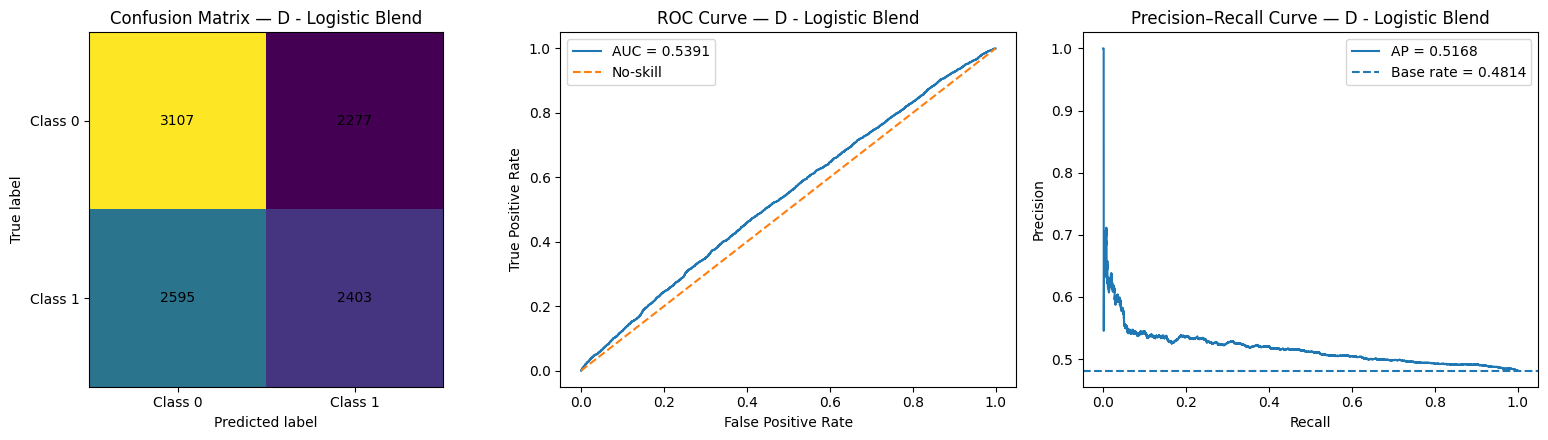

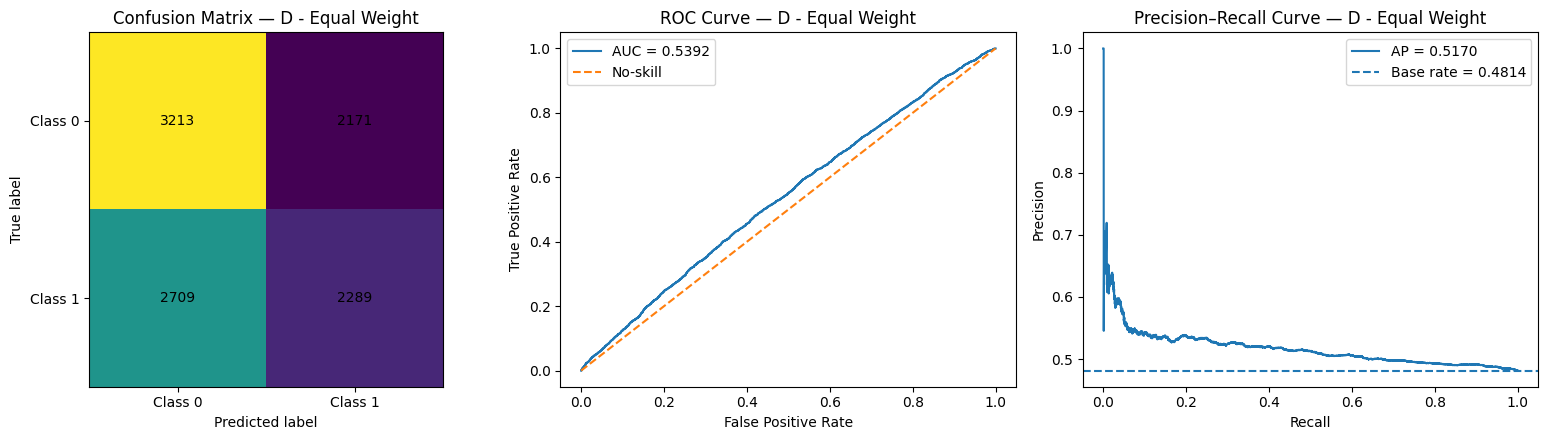

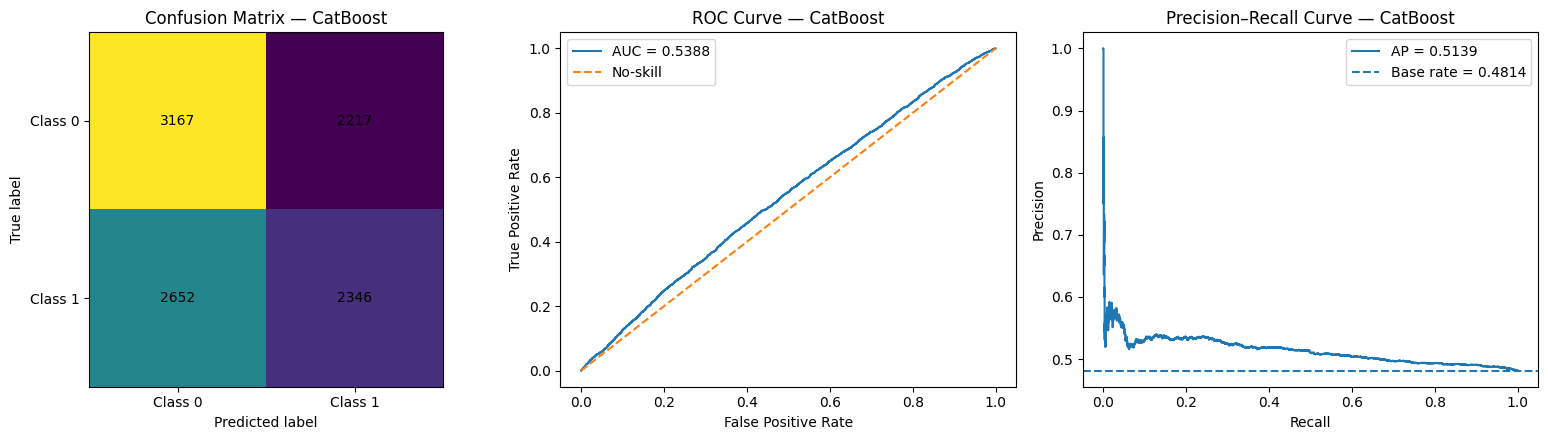

In [20]:
# c) Plot final test classification diagnostics
models = ["D - Logistic Blend", "D - Equal Weight", "CatBoost"]
base_rate = y_test.mean()

for name in models:
    score = test_predictions[name]
    pred = (score >= 0.50).astype("int8")

    cm = confusion_matrix(y_test, pred)
    fpr, tpr, _ = roc_curve(y_test, score)
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, score)

    auc = roc_auc_score(y_test, score)
    ap = average_precision_score(y_test, score)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    axes[0].imshow(cm, cmap="viridis")
    for i in range(2):
        for j in range(2):
            axes[0].text(j, i, cm[i, j], ha="center", va="center")

    axes[0].set_xticks([0, 1], ["Class 0", "Class 1"])
    axes[0].set_yticks([0, 1], ["Class 0", "Class 1"])
    axes[0].set_xlabel("Predicted label")
    axes[0].set_ylabel("True label")
    axes[0].set_title(f"Confusion Matrix — {name}")

    axes[1].plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    axes[1].plot([0, 1], [0, 1], linestyle="--", label="No-skill")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title(f"ROC Curve — {name}")
    axes[1].legend()

    axes[2].plot(recall_curve, precision_curve, label=f"AP = {ap:.4f}")
    axes[2].axhline(base_rate, linestyle="--", label=f"Base rate = {base_rate:.4f}")
    axes[2].set_xlabel("Recall")
    axes[2].set_ylabel("Precision")
    axes[2].set_title(f"Precision–Recall Curve — {name}")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

### **d) Temporal Stability of Final Test Performance**

The final test sample is divided into calendar quarters to assess whether predictive performance is stable through time or concentrated in particular periods. ROC-AUC and balanced accuracy are calculated for the frozen primary blend and two benchmarks using the same 0.50 classification threshold. No model or decision rule is re-estimated by quarter.

In [21]:
# d) Summarise quarterly final test performance
models = ["D - Logistic Blend", "D - Equal Weight", "CatBoost"]
quarter = (test_predictions.index.year.astype(str) + "Q" + test_predictions.index.quarter.astype(str))

quarter_rows = []

for period in pd.unique(quarter):
    mask = quarter == period
    y_q = y_test.loc[mask]

    for name in models:
        prob = test_predictions.loc[mask, name]
        pred = (prob >= 0.50).astype("int8")

        quarter_rows.append([period, name, len(y_q), y_q.mean(), roc_auc_score(y_q, prob),
                             balanced_accuracy_score(y_q, pred)])

quarterly_results = pd.DataFrame(quarter_rows, columns=["quarter", "model", "observations",
                                                        "class1_rate", "roc_auc", "balanced_accuracy"])

auc_table = quarterly_results.pivot(index="quarter", columns="model", values="roc_auc")
ba_table = quarterly_results.pivot(index="quarter", columns="model", values="balanced_accuracy")
quarterly_summary = (quarterly_results.groupby("quarter")[["observations", "class1_rate"]].first())

quarterly_summary["Logistic_AUC"] = auc_table["D - Logistic Blend"]
quarterly_summary["EqualWeight_AUC"] = auc_table["D - Equal Weight"]
quarterly_summary["CatBoost_AUC"] = auc_table["CatBoost"]

quarterly_summary["Logistic_BA"] = ba_table["D - Logistic Blend"]
quarterly_summary["EqualWeight_BA"] = ba_table["D - Equal Weight"]
quarterly_summary["CatBoost_BA"] = ba_table["CatBoost"]

ba_cols = ["Logistic_BA", "EqualWeight_BA", "CatBoost_BA"]
quarterly_summary["best_BA_model"] = quarterly_summary[ba_cols].idxmax(axis=1).str.replace("_BA", "")
quarterly_summary["best_BA"] = quarterly_summary[ba_cols].max(axis=1)

quarterly_summary = quarterly_summary.reset_index()

quarterly_results.to_parquet(DATA_PATH / "quarterly_test_performance_4h.parquet", compression="zstd", index=False)
quarterly_summary.to_parquet(DATA_PATH / "quarterly_test_summary_4h.parquet", compression="zstd", index=False)

display(quarterly_summary.round(4))

,quarter,observations,class1_rate,Logistic_AUC,EqualWeight_AUC,CatBoost_AUC,Logistic_BA,EqualWeight_BA,CatBoost_BA,best_BA_model,best_BA
0,2025Q2,1626,0.4994,0.5835,0.5838,0.5861,0.5683,0.5688,0.5689,CatBoost,0.5689
1,2025Q3,2208,0.4783,0.5326,0.5330,0.5290,0.5255,0.5282,0.5228,EqualWeight,0.5282
2,2025Q4,2208,0.4905,0.5331,0.5334,0.5348,0.5229,0.5198,0.5209,Logistic,0.5229
3,2026Q1,2160,0.4736,0.5356,0.5352,0.5361,0.5286,0.5195,0.5269,Logistic,0.5286
4,2026Q2,2180,0.4697,0.5183,0.5186,0.5157,0.5078,0.5095,0.5123,CatBoost,0.5123


Temporal stability review: Classification performance varies materially through the final test period, while differences among the three frozen architectures remain comparatively small. Performance is strongest during the partial 2025Q2 period, with ROC-AUCs around 0.58, before moderating to approximately 0.53 through 2025Q3–2026Q1 and approaching chance levels in 2026Q2. The results therefore suggest that predictive strength is more sensitive to changing market conditions than to the choice among the frozen tree-consensus architectures.

### **e) Final Test Performance by SOM Market State**

The SOM fitted on the training sample is applied unchanged to the final test features. To obtain broader market-state groups than the 100 individual SOM nodes, the training SOM codebook vectors are grouped into four clusters using K-Means. Final test ROC-AUC and balanced accuracy are then compared across these market states for the three frozen models. This analysis is diagnostic only and does not alter the forecasting models or classification threshold.

In [23]:
# e) Review final test performance across SOM market states
som_scaler = joblib.load(DATA_PATH / "som_scaler_4h.joblib")
som = joblib.load(DATA_PATH / "som_model_4h.joblib")

X_test_som = som_scaler.transform(X_test_final)
test_bmu = np.array([som.winner(row) for row in X_test_som])

som_size = som.get_weights().shape[0]
test_node = test_bmu[:, 0] * som_size + test_bmu[:, 1]

som_weights = som.get_weights().reshape(-1, len(final_features))
regime_model = KMeans(n_clusters=4, n_init=20, random_state=42).fit(som_weights)
node_regime = regime_model.labels_

test_regime = pd.Series(node_regime[test_node], index=X_test_final.index, name="market_state")

models = ["D - Logistic Blend", "D - Equal Weight", "CatBoost"]
regime_rows = []

for regime in sorted(test_regime.unique()):
    mask = test_regime.eq(regime)
    y_r = y_test.loc[mask]
    valid = len(y_r) >= 100 and y_r.nunique() == 2

    for name in models:
        prob = test_predictions.loc[mask, name]
        pred = (prob >= 0.50).astype("int8")

        regime_rows.append([regime, name, len(y_r), y_r.mean(),
                            roc_auc_score(y_r, prob) if valid else np.nan,
                            balanced_accuracy_score(y_r, pred) if valid else np.nan])

regime_results = pd.DataFrame(regime_rows, columns=["market_state", "model", "observations",
                                                    "class1_rate", "roc_auc", "balanced_accuracy"])

regime_valid = regime_results[regime_results["observations"] >= 100].copy()

auc_regime = regime_valid.pivot(index="market_state", columns="model", values="roc_auc")
ba_regime = regime_valid.pivot(index="market_state", columns="model", values="balanced_accuracy")

regime_summary = (regime_valid.groupby("market_state")[["observations", "class1_rate"]].first())

regime_summary["Logistic_AUC"] = auc_regime["D - Logistic Blend"]
regime_summary["EqualWeight_AUC"] = auc_regime["D - Equal Weight"]
regime_summary["CatBoost_AUC"] = auc_regime["CatBoost"]

regime_summary["Logistic_BA"] = ba_regime["D - Logistic Blend"]
regime_summary["EqualWeight_BA"] = ba_regime["D - Equal Weight"]
regime_summary["CatBoost_BA"] = ba_regime["CatBoost"]

regime_summary = regime_summary.reset_index()

regime_results.to_parquet(DATA_PATH / "som_test_regime_performance_4h.parquet", compression="zstd", index=False)
regime_summary.to_parquet(DATA_PATH / "som_test_regime_summary_4h.parquet", compression="zstd", index=False)

display(regime_summary.round(4))

,market_state,observations,class1_rate,Logistic_AUC,EqualWeight_AUC,CatBoost_AUC,Logistic_BA,EqualWeight_BA,CatBoost_BA
0,1,176,0.4261,0.5736,0.5721,0.5527,0.5387,0.5236,0.5587
1,2,2774,0.5043,0.5296,0.5294,0.5312,0.5124,0.5139,0.5191
2,3,7431,0.4741,0.5386,0.5387,0.5379,0.5287,0.5261,0.5260


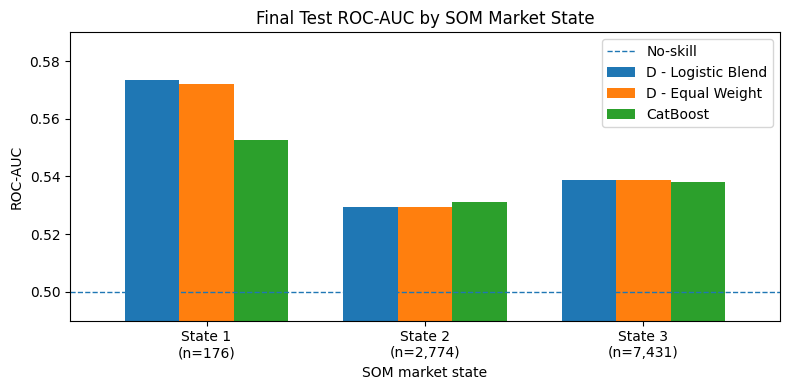

In [25]:
# Plot final test ROC-AUC across SOM market states

auc_plot = regime_summary.set_index("market_state")[["Logistic_AUC", "EqualWeight_AUC", "CatBoost_AUC"]].copy()
auc_plot.columns = [
    "D - Logistic Blend",
    "D - Equal Weight",
    "CatBoost"]

state_labels = [
    f"State {int(state)}\n(n={int(obs):,})"
    for state, obs in zip(
        regime_summary["market_state"],
        regime_summary["observations"])]

ax = auc_plot.plot(kind="bar", figsize=(8, 4), width=0.75)

ax.axhline(0.50, linestyle="--", linewidth=1, label="No-skill")
ax.set_xticklabels(state_labels, rotation=0)
ax.set_xlabel("SOM market state")
ax.set_ylabel("ROC-AUC")
ax.set_title("Final Test ROC-AUC by SOM Market State")
ax.set_ylim(0.49, max(0.59, auc_plot.max().max() + 0.01))
ax.legend()

plt.tight_layout()
plt.show()

### **f) Formal Non-Overlapping 4-Hour Backtest and Economic Performance**

The frozen model forecasts are converted into long–flat positions using the fixed 0.50 probability threshold. Trading decisions are restricted to six four-hour intervals per day so that realised returns do not overlap. A long position is held when the predicted probability is at least 0.50; otherwise the strategy remains in cash. Transaction costs are fixed at 5 bps per traded side, including entry, exit and final liquidation.

Economic performance is evaluated before and after transaction costs and compared with BTC buy-and-hold over the same execution period. The analysis reports compounded and annualised returns, volatility, Sharpe ratio, maximum drawdown, exposure and turnover.

In [28]:
# f) Construct formal non-overlapping 4-hour long-flat backtests
threshold = 0.50
cost_per_side = 0.0005
models = ["D - Logistic Blend", "D - Equal Weight", "CatBoost"]

execution_mask = test_predictions.index.hour % 4 == 0
execution_index = test_predictions.index[execution_mask]

backtest = pd.DataFrame(index=execution_index)
backtest["btc_return_4h"] = np.expm1(targets_test.loc[execution_index, "fwd_logret_4h"])

for name in models:
    prob = test_predictions.loc[execution_index, name]
    position = (prob >= threshold).astype("int8")

    turnover = position.diff().abs()
    turnover.iloc[0] = position.iloc[0]
    turnover.iloc[-1] += position.iloc[-1]

    backtest[f"{name}_prob"] = prob
    backtest[f"{name}_position"] = position
    backtest[f"{name}_turnover"] = turnover
    backtest[f"{name}_gross"] = position * backtest["btc_return_4h"]
    backtest[f"{name}_net"] = backtest[f"{name}_gross"] - turnover * cost_per_side

backtest.to_parquet(DATA_PATH / "final_4h_backtest_returns.parquet", compression="zstd")

print(f"Backtest observations: {len(backtest):,}")
print(f"Period: {backtest.index.min()} to {backtest.index.max()}")
print(f"Execution hours: {sorted(backtest.index.hour.unique())}")
print(f"Transaction cost: {cost_per_side * 10000:.0f} bps per side")

Backtest observations: 2,595
Period: 2025-04-24 08:00:00+00:00 to 2026-06-30 16:00:00+00:00
Execution hours: [0, 4, 8, 12, 16, 20]
Transaction cost: 5 bps per side


In [48]:
# Summarise formal 4-hour backtest performance
periods_per_year = 6 * 365

def compute_return_metrics(period_return):
    period_return = pd.Series(period_return).dropna()

    wealth = (1 + period_return).cumprod()
    years = len(period_return) / periods_per_year

    annual_return = wealth.iloc[-1] ** (1 / years) - 1
    annual_volatility = period_return.std() * np.sqrt(periods_per_year)
    sharpe = (period_return.mean() / period_return.std() * np.sqrt(periods_per_year)
              if period_return.std() > 0 else np.nan)

    drawdown = wealth / wealth.cummax() - 1
    maximum_drawdown = drawdown.min()
    calmar = annual_return / abs(maximum_drawdown) if maximum_drawdown < 0 else np.nan

    return {
        "final_wealth": wealth.iloc[-1],
        "total_return": wealth.iloc[-1] - 1,
        "annualised_return": annual_return,
        "annualised_volatility": annual_volatility,
        "sharpe_ratio": sharpe,
        "calmar_ratio": calmar,
        "maximum_drawdown": maximum_drawdown}

# BTC buy-and-hold with the same 5 bps entry and exit costs
benchmark_return = backtest["btc_return_4h"].copy()
benchmark_return.iloc[0] -= cost_per_side
benchmark_return.iloc[-1] -= cost_per_side
backtest["btc_buy_hold_net"] = benchmark_return

benchmark_metrics = compute_return_metrics(backtest["btc_buy_hold_net"])

benchmark_table = pd.DataFrame([{"Benchmark": "BTC Buy-and-Hold, Net 5 bps", **benchmark_metrics}])

strategy_rows = []
years = len(backtest) / periods_per_year

for name in models:
    gross_metrics = compute_return_metrics(backtest[f"{name}_gross"])
    net_metrics = compute_return_metrics(backtest[f"{name}_net"])

    turnover_sides = backtest[f"{name}_turnover"].sum()

    strategy_rows.append({
        "Model": name,
        "Exposure": backtest[f"{name}_position"].mean(),
        "Gross Return": gross_metrics["total_return"],
        "Net Return": net_metrics["total_return"],
        "Net Ann. Return": net_metrics["annualised_return"],
        "Net Ann. Vol": net_metrics["annualised_volatility"],
        "Gross Sharpe": gross_metrics["sharpe_ratio"],
        "Net Sharpe": net_metrics["sharpe_ratio"],
        "Net Calmar": net_metrics["calmar_ratio"],
        "Net Max DD": net_metrics["maximum_drawdown"],
        "Turnover Sides": turnover_sides,
        "Sides/Yr": turnover_sides / years})

strategy_table = pd.DataFrame(strategy_rows)

backtest.to_parquet(DATA_PATH / "final_4h_backtest_returns.parquet", compression="zstd")
benchmark_table.to_parquet(DATA_PATH / "final_backtest_btc_buy_hold_4h.parquet", compression="zstd", index=False)
strategy_table.to_parquet(DATA_PATH / "final_backtest_model_comparison_4h.parquet", compression="zstd", index=False)

display(
    benchmark_table[[
        "Benchmark", "final_wealth", "total_return",
        "annualised_return", "annualised_volatility",
        "sharpe_ratio", "calmar_ratio", "maximum_drawdown"]].round(4))

display(strategy_table.round(4))

,Benchmark,final_wealth,total_return,annualised_return,annualised_volatility,sharpe_ratio,calmar_ratio,maximum_drawdown
0,"BTC Buy-and-Hold, Net 5 bps",0.6376,-0.3624,-0.316,0.4114,-0.7171,-0.5912,-0.5346


,Model,Exposure,Gross Return,Net Return,Net Ann. Return,Net Ann. Vol,Gross Sharpe,Net Sharpe,Net Calmar,Net Max DD,Turnover Sides,Sides/Yr
0,D - Logistic Blend,0.4412,0.1795,-0.2926,-0.2533,0.2881,0.6288,-0.8694,-0.5296,-0.4783,1022.0,862.497070
1,D - Equal Weight,0.4243,0.0985,-0.3392,-0.2950,0.2851,0.4214,-1.0831,-0.5759,-0.5123,1016.0,857.433472
2,CatBoost,0.4262,0.2913,-0.2193,-0.1885,0.2795,0.9130,-0.6072,-0.4146,-0.4548,1006.0,848.994202


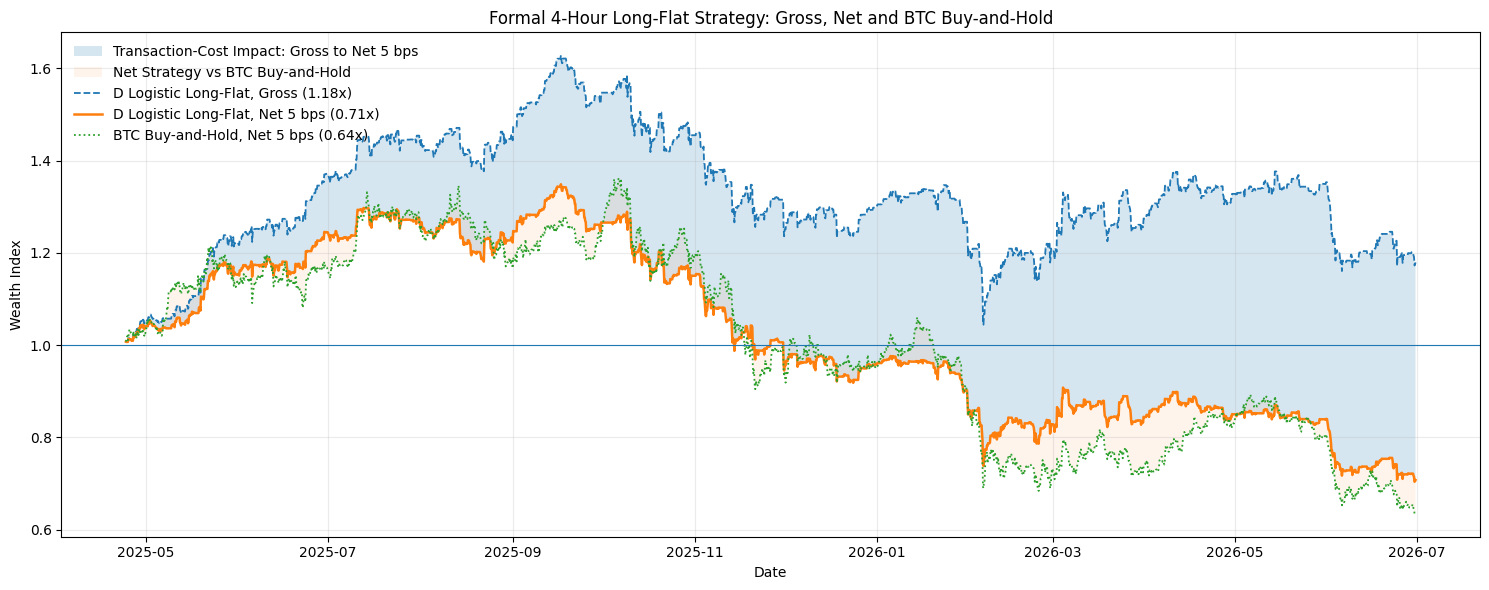

In [49]:
# Plot formal long-flat strategy against BTC buy-and-hold
primary_model = "D - Logistic Blend"

gross_wealth = (1 + backtest[f"{primary_model}_gross"]).cumprod()
net_wealth = (1 + backtest[f"{primary_model}_net"]).cumprod()
benchmark_wealth = (1 + backtest["btc_buy_hold_net"]).cumprod()

fig, ax = plt.subplots(figsize=(15, 6))

ax.fill_between(gross_wealth.index, net_wealth.to_numpy(), gross_wealth.to_numpy(), alpha=0.18, label="Transaction-Cost Impact: Gross to Net 5 bps")
ax.fill_between(net_wealth.index, benchmark_wealth.to_numpy(), net_wealth.to_numpy(), alpha=0.08, label="Net Strategy vs BTC Buy-and-Hold")

ax.plot(gross_wealth.index, gross_wealth, linewidth=1.3, linestyle="--", label=f"D Logistic Long-Flat, Gross ({gross_wealth.iloc[-1]:.2f}x)")
ax.plot(net_wealth.index, net_wealth, linewidth=1.8, label=f"D Logistic Long-Flat, Net 5 bps ({net_wealth.iloc[-1]:.2f}x)")
ax.plot(benchmark_wealth.index, benchmark_wealth, linewidth=1.3, linestyle=":", label=f"BTC Buy-and-Hold, Net 5 bps ({benchmark_wealth.iloc[-1]:.2f}x)")

ax.axhline(1, linewidth=0.8)
ax.set_title("Formal 4-Hour Long-Flat Strategy: Gross, Net and BTC Buy-and-Hold")
ax.set_ylabel("Wealth Index")
ax.set_xlabel("Date")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper left", frameon=False)

plt.tight_layout()
plt.show()

The formal long-flat strategy generated a positive gross return of 17.95%, indicating that the classifier contained economically relevant timing information. However, frequent position changes caused transaction costs to dominate the gross signal, reducing the strategy to a 29.26% net loss at 5 bps per traded side. The net strategy nevertheless declined less than BTC buy-and-hold, which lost 36.18% over the same period, suggesting that at the tested implementation frequency the model provides greater value as an exposure-management signal than as a directly tradable high-turnover strategy.

# **VIII. Follow-Up Analysis and Trading Implementation Sensitivity**

The formal final-test analysis shows that the frozen long–flat strategy generates positive gross returns, but frequent position changes cause transaction costs to materially reduce economic performance. The following analyses therefore examine the implementation sensitivity of the frozen model signal, with particular attention to transaction costs, trading frequency and holding-period design.

These analyses are conducted after reviewing the formal final-test results and are treated as **post-test exploratory follow-up rather than additional untouched-test evidence**. The forecasting models, classification target and reported final-test classification results are not revised. The objective is instead to assess whether lower-turnover implementation choices may preserve a greater proportion of the gross predictive signal and to identify directions for prospective strategy development.


### **a) Minimum Holding-Period Sensitivity of the Primary Long–Flat Strategy**

The first follow-up examines whether lower turnover can preserve more of the primary model's positive gross return after transaction costs. The frozen D-Logistic probability forecasts and 0.50 long–flat decision rule are retained, but once a long position is entered it must remain active for a minimum of 4, 8 or 12 hours before it can return to cash. Transaction costs remain fixed at 5 bps per traded side. This post-test sensitivity changes only the trading implementation; the forecasting model, probability threshold and test predictions remain unchanged.

In [50]:
# a) Test minimum holding periods for the primary long-flat strategy

primary_model = "D - Logistic Blend"
holds = [4, 8, 12]
hold_rows = []
hold_paths = {"btc_return_4h": backtest["btc_return_4h"]}

def apply_min_hold(signal, hold_steps):
    values = signal.to_numpy()
    position = np.zeros(len(values))
    current, held = 0, 0

    for i, desired in enumerate(values):
        if current == 0:
            current = desired
            held = int(desired != 0)
        elif held < hold_steps:
            held += 1
        else:
            current = desired
            held = held + 1 if desired != 0 else 0

        position[i] = current

    return pd.Series(position, index=signal.index)

raw_signal = backtest[f"{primary_model}_position"]
years = len(backtest) / periods_per_year

for hold_hours in holds:
    position = apply_min_hold(raw_signal, hold_hours // 4)

    turnover = position.diff().abs()
    turnover.iloc[0] = position.iloc[0]
    turnover.iloc[-1] += position.iloc[-1]

    gross = position * backtest["btc_return_4h"]
    net = gross - turnover * cost_per_side

    gross_metrics = compute_return_metrics(gross)
    net_metrics = compute_return_metrics(net)
    turnover_sides = turnover.sum()

    hold_rows.append({
        "Min Hold": hold_hours,
        "Exposure": position.mean(),
        "Gross Return": gross_metrics["total_return"],
        "Net Return": net_metrics["total_return"],
        "Net Ann. Return": net_metrics["annualised_return"],
        "Gross Sharpe": gross_metrics["sharpe_ratio"],
        "Net Sharpe": net_metrics["sharpe_ratio"],
        "Net Max DD": net_metrics["maximum_drawdown"],
        "Turnover Sides": turnover_sides,
        "Sides/Yr": turnover_sides / years})

    hold_paths[f"{hold_hours}h_position"] = position
    hold_paths[f"{hold_hours}h_gross"] = gross
    hold_paths[f"{hold_hours}h_net"] = net

hold_results = pd.DataFrame(hold_rows)
hold_paths = pd.DataFrame(hold_paths, index=backtest.index)

hold_results.to_parquet(DATA_PATH / "primary_long_flat_hold_sensitivity_4h.parquet", compression="zstd", index=False)
hold_paths.to_parquet(DATA_PATH / "primary_long_flat_hold_paths_4h.parquet", compression="zstd")

hold_results.round(4)

,Min Hold,Exposure,Gross Return,Net Return,Net Ann. Return,Gross Sharpe,Net Sharpe,Net Max DD,Turnover Sides,Sides/Yr
0,4,0.4412,0.1795,-0.2926,-0.2533,0.6288,-0.8694,-0.4783,1022.0,862.4971
1,8,0.5171,0.3054,-0.1637,-0.1400,0.8860,-0.3353,-0.3967,890.0,751.0983
2,12,0.5846,0.1940,-0.1877,-0.1609,0.6205,-0.3686,-0.4007,770.0,649.8266


Minimum-holding-period sensitivity: Increasing the minimum holding period reduces turnover and materially improves net economic performance, although the strategy remains unprofitable at the fixed 5-bps transaction cost. The eight-hour specification performs best among the three alternatives, improving gross return to 30.54% and reducing the net loss from 29.26% to 16.37%. Extending the holding period to 12 hours lowers turnover further but also weakens gross performance, suggesting that excessive persistence begins to dilute the short-horizon signal.

### **b) Exploratory Long-Only, Short-Only and Long–Short Tail Strategies**

The frozen D-Logistic score is examined for additional information in its upper and lower probability tails. Tail thresholds are defined from the blend-validation score distribution and then applied unchanged to the final test sample. Long-only, short-only and combined long–short strategies are evaluated using the outer 20% and 40% score tails, while the non-overlapping four-hour execution schedule and 5 bps transaction cost per traded side are retained.

Because the original classifier predicts sufficiently positive returns rather than a separate bearish class, the short-side analysis is treated as post-test exploratory evidence. Low Class 1 probabilities are interpreted here only as a potential bearish-tail signal and do not alter the original classification problem or formal long–flat test result.

In [51]:
# b) Compare exploratory tail-based strategies for the primary model
primary_model = "D - Logistic Blend"
D_models = ["Random Forest", "XGBoost", "CatBoost"]

final_meta = joblib.load(DATA_PATH / "final_meta_D_logistic_4h.joblib")
blend_ref = pd.read_parquet(DATA_PATH / "blend_base_predictions_4h.parquet")

reference_score = final_meta.predict_proba(blend_ref[D_models])[:, 1]

q20, q40, q60, q80 = np.quantile(reference_score, [0.20, 0.40, 0.60, 0.80])
score = backtest[f"{primary_model}_prob"]

strategies = {
    "Long-Only Top 20%": np.where(score >= q80, 1.0, 0.0),
    "Short-Only Bottom 20%": np.where(score <= q20, -1.0, 0.0),
    "Long-Short Top/Bottom 20%": np.select([score <= q20, score >= q80], [-1.0, 1.0], default=0.0),
    "Long-Only Top 40%": np.where(score >= q60, 1.0, 0.0),
    "Short-Only Bottom 40%": np.where(score <= q40, -1.0, 0.0),
    "Long-Short Top/Bottom 40%": np.select([score <= q40, score >= q60], [-1.0, 1.0], default=0.0)}

tail_rows = []
tail_paths = pd.DataFrame(index=backtest.index)
tail_paths["btc_return_4h"] = backtest["btc_return_4h"]
tail_paths["btc_buy_hold_net"] = backtest["btc_buy_hold_net"]

years = len(backtest) / periods_per_year

for strategy, values in strategies.items():
    position = pd.Series(values, index=backtest.index)

    turnover = position.diff().abs()
    turnover.iloc[0] = abs(position.iloc[0])
    turnover.iloc[-1] += abs(position.iloc[-1])

    gross = position * backtest["btc_return_4h"]
    net = gross - turnover * cost_per_side

    gross_metrics = compute_return_metrics(gross)
    net_metrics = compute_return_metrics(net)
    turnover_sides = turnover.sum()

    tail_rows.append({
        "Strategy": strategy,
        "Exposure": position.abs().mean(),
        "Gross Return": gross_metrics["total_return"],
        "Net Return": net_metrics["total_return"],
        "Net Ann. Return": net_metrics["annualised_return"],
        "Gross Sharpe": gross_metrics["sharpe_ratio"],
        "Net Sharpe": net_metrics["sharpe_ratio"],
        "Net Max DD": net_metrics["maximum_drawdown"],
        "Turnover Sides": turnover_sides,
        "Sides/Yr": turnover_sides / years})

    key = strategy.replace(" ", "_").replace("/", "_")
    tail_paths[f"{key}_position"] = position
    tail_paths[f"{key}_gross"] = gross
    tail_paths[f"{key}_net"] = net

tail_results = pd.DataFrame(tail_rows)

tail_paths.to_parquet(DATA_PATH / "primary_tail_strategy_paths_4h.parquet", compression="zstd")
tail_results.to_parquet(DATA_PATH / "primary_tail_strategy_results_4h.parquet", compression="zstd", index=False)

print("Blend-validation score thresholds:")
print(f"20th percentile: {q20:.4f}")
print(f"40th percentile: {q40:.4f}")
print(f"60th percentile: {q60:.4f}")
print(f"80th percentile: {q80:.4f}")

tail_results.round(4)

Blend-validation score thresholds:
20th percentile: 0.4910
40th percentile: 0.4970
60th percentile: 0.5031
80th percentile: 0.5100


,Strategy,Exposure,Gross Return,Net Return,Net Ann. Return,Gross Sharpe,Net Sharpe,Net Max DD,Turnover Sides,Sides/Yr
0,Long-Only Top 20%,0.1719,0.6166,0.2013,0.1674,2.3711,0.9603,-0.1188,594.0,501.2948
1,Short-Only Bottom 20%,0.2751,0.2704,-0.1644,-0.1407,1.1587,-0.7033,-0.2627,838.0,707.2139
2,Long-Short Top/Bottom 20%,0.4470,1.0538,0.0037,0.0032,2.4674,0.1419,-0.2368,1432.0,1208.5087
3,Long-Only Top 40%,0.3464,0.2978,-0.1817,-0.1557,0.9871,-0.5307,-0.3771,922.0,778.1040
4,Short-Only Bottom 40%,0.4674,0.5381,-0.0783,-0.0665,1.4989,-0.1250,-0.2388,1024.0,864.1850
5,Long-Short Top/Bottom 40%,0.8139,0.9961,-0.2460,-0.2120,1.7650,-0.4574,-0.4939,1946.0,1642.2890


The exploratory tail analysis reveals a pronounced asymmetry in the frozen classifier. Low probability scores contain some bearish information, as both short-only strategies generate positive gross returns, but the signal is weaker and more turnover-intensive than the upper-tail long signal. Predictive information is particularly concentrated in the top 20% of scores, where the long-only strategy remains profitable after 5-bps transaction costs.

### **c) Quarterly Stability of the Top-20% Long-Only Strategy**

The strongest exploratory implementation, the top-20% long-only strategy, is reviewed by calendar quarter to assess whether its positive net performance is broadly distributed through the test period or concentrated in a small number of intervals. The tail threshold remains fixed from the blend-validation score distribution and transaction costs remain unchanged at 5 bps per traded side. No further strategy parameters are adjusted.

In [52]:
# c) Review quarterly stability of the top-20% long-only strategy
strategy = "Long-Only_Top_20%"

position = tail_paths[f"{strategy}_position"]
gross_return = tail_paths[f"{strategy}_gross"]
net_return = tail_paths[f"{strategy}_net"]
benchmark_return = tail_paths["btc_buy_hold_net"]

turnover = position.diff().abs()
turnover.iloc[0] = abs(position.iloc[0])
turnover.iloc[-1] += abs(position.iloc[-1])

quarter = position.index.year.astype(str) + "Q" + position.index.quarter.astype(str)
quarter_rows = []

for period in pd.unique(quarter):
    mask = quarter == period

    pos_q = position.loc[mask]
    gross_q = gross_return.loc[mask]
    net_q = net_return.loc[mask]
    btc_q = benchmark_return.loc[mask]

    gross_total = (1 + gross_q).prod() - 1
    net_total = (1 + net_q).prod() - 1
    btc_total = (1 + btc_q).prod() - 1

    net_sharpe = net_q.mean() / net_q.std() * np.sqrt(periods_per_year) if net_q.std() > 0 else np.nan

    net_curve = (1 + net_q).cumprod()
    max_dd = (net_curve / net_curve.cummax() - 1).min()

    quarter_rows.append([period, len(pos_q), pos_q.mean(), gross_total, net_total,
                         btc_total, net_sharpe, max_dd, turnover.loc[mask].sum()])

tail_quarterly = pd.DataFrame(quarter_rows, columns=[
    "Quarter", "Periods", "Exposure", "Gross Return", "Net Return", "BTC Return",
    "Net Sharpe", "Max DD", "Turnover Sides"])

tail_quarterly.to_parquet(DATA_PATH / "primary_top20_long_quarterly_4h.parquet", compression="zstd", index=False)

tail_quarterly.round(4)

,Quarter,Periods,Exposure,Gross Return,Net Return,BTC Return,Net Sharpe,Max DD,Turnover Sides
0,2025Q2,406,0.2192,0.2311,0.1514,0.1662,4.7107,-0.0433,134.0
1,2025Q3,552,0.1866,0.0711,0.0047,0.0639,0.2106,-0.0534,128.0
2,2025Q4,552,0.1884,0.0639,0.0009,-0.2313,0.1282,-0.0705,122.0
3,2026Q1,540,0.1611,0.1012,0.0381,-0.2220,0.8188,-0.0926,118.0
4,2026Q2,545,0.1156,0.0465,-0.0005,-0.1407,0.0523,-0.0663,92.0


Post-test exploratory implementation: restricting execution to scores above the blend-validation-defined 80th percentile reduces exposure to 17.2% and produces +61.66% gross / +20.13% net, with positive gross returns across every calendar period and net performance positive or approximately flat across the five test-period quarters.

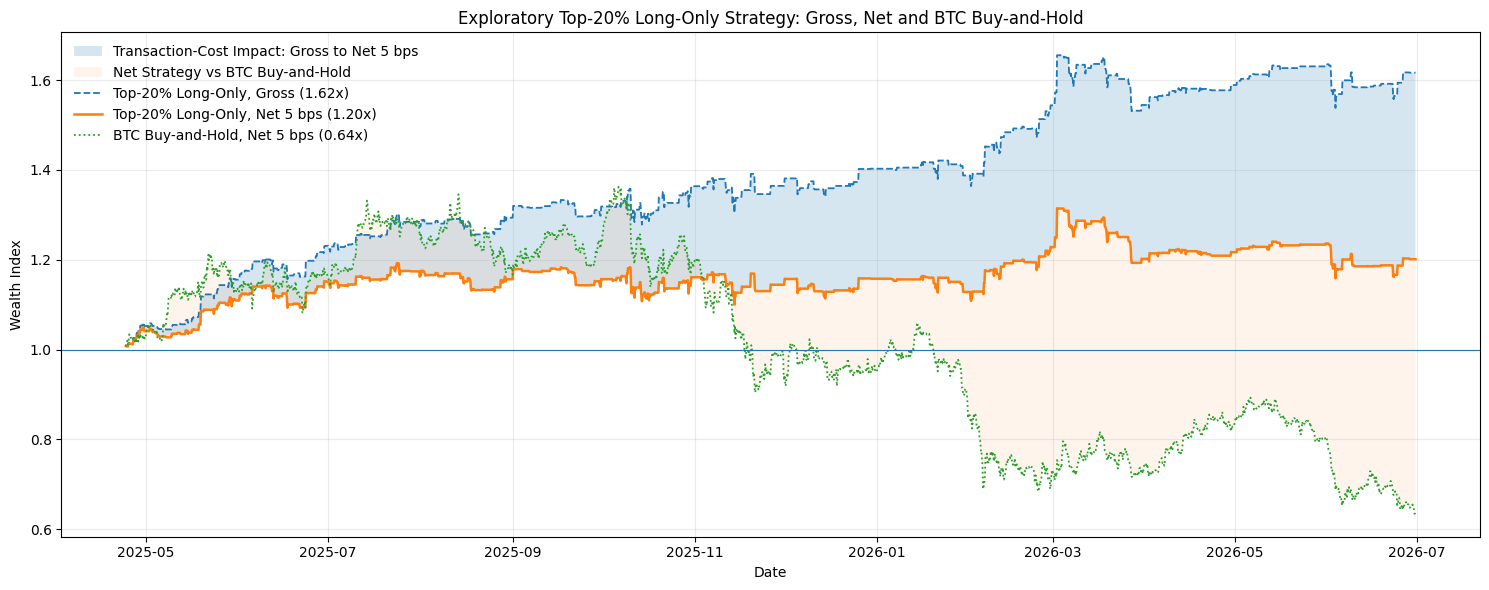

In [53]:
# Plot exploratory top-20% long-only strategy against BTC buy-and-hold
strategy = "Long-Only_Top_20%"

gross_wealth = (1 + tail_paths[f"{strategy}_gross"]).cumprod()
net_wealth = (1 + tail_paths[f"{strategy}_net"]).cumprod()
benchmark_wealth = (1 + tail_paths["btc_buy_hold_net"]).cumprod()

fig, ax = plt.subplots(figsize=(15, 6))

ax.fill_between(gross_wealth.index, net_wealth.to_numpy(), gross_wealth.to_numpy(), alpha=0.18, label="Transaction-Cost Impact: Gross to Net 5 bps")
ax.fill_between(net_wealth.index, benchmark_wealth.to_numpy(), net_wealth.to_numpy(), alpha=0.08, label="Net Strategy vs BTC Buy-and-Hold")

ax.plot(gross_wealth.index, gross_wealth, linewidth=1.3, linestyle="--", label=f"Top-20% Long-Only, Gross ({gross_wealth.iloc[-1]:.2f}x)")
ax.plot(net_wealth.index, net_wealth, linewidth=1.8, label=f"Top-20% Long-Only, Net 5 bps ({net_wealth.iloc[-1]:.2f}x)")
ax.plot(benchmark_wealth.index, benchmark_wealth, linewidth=1.3, linestyle=":", label=f"BTC Buy-and-Hold, Net 5 bps ({benchmark_wealth.iloc[-1]:.2f}x)")

ax.axhline(1, linewidth=0.8)
ax.set_title("Exploratory Top-20% Long-Only Strategy: Gross, Net and BTC Buy-and-Hold")
ax.set_ylabel("Wealth Index")
ax.set_xlabel("Date")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper left", frameon=False)

plt.tight_layout()
plt.show()

The top-20% strategy does not simply reduce market exposure. It concentrates long positions in periods associated with the model's strongest positive forecasts, capturing selected upward moves while remaining in cash through much of the subsequent market weakness.